<div style="border-bottom:2px solid #0077c8;padding:12px 0 24px;margin-bottom:24px;">
<p style="color:#0077c8;letter-spacing:.1em;font-size:12px;margin-top:24px;">DSPRO2 · TEAM 6</p>
<h1 style="font-family:'Arial Narrow',sans-serif;font-weight:800;line-height:1.05;">PREDICTING APARTMENT<br>RENTAL PRICES IN SWITZERLAND</h1>
<p style="font-size:17px;color:#153652;margin-top:8px;">Spatial mixed effects, listing text, calibrated intervals and a quality-of-life index</p>
<p>Elias Martinelli · Timo Schlumpf</p>
</div>

## 0. From the DSPRO1 prototype to a reproducible rent model

DSPRO1 ended with a working prototype: 9,994 listings scraped from rentumo.ch (snapshot of
13 April 2026), enriched with GWR and swisstopo data, and tree models trained on about 4,500
fully enriched rows. The strongest benchmark, **LightGBM with k-nearest-neighbour price
features**, reached **R² = 0.751 and an RMSE of about 393 CHF**. The deployed
**GradientBoosting** model reached about **425 CHF** with a smaller train/eval gap. Four
weaknesses carried over into this project:

- **Leaky location signal.** The kNN price features were computed leave-one-out, not out of
  fold, so a relisted apartment could see its own rent in its neighbourhood median.
- **One global uncertainty value.** Every apartment got the same constant ± band, although the
  errors grow strongly with the rent.
- **Expensive apartments were underestimated**, and only about half of the scraped listings
  were usable.
- **The listing text was never used**, although the description is stored in the database.

DSPRO2 keeps the DSPRO1 idea (a tree model on listing, building and location features) but
changes how the data is prepared and how every claim is tested.

**Storyline**

1. Build a trustworthy table with **one row per rental object** (duplicate audit) and an
   official canton > district > municipality hierarchy (sections 1–6).
2. Prepare the listing text: anonymise it, detect the language, extract attributes and remove
   non-market rents from the target (sections 7–9).
3. Freeze the splits and the **pre-registered evaluation plan** before any model is compared
   (sections 10–11).
4. **RQ2:** compare boosting with spatial mixed effects (GPBoost) against LightGBM with
   coordinates and out-of-fold target encoding, especially in sparse municipalities.
5. **RQ1 and RQ3:** test whether the text improves the winning model, then turn it into
   calibrated per-apartment intervals (Mondrian conformal quantile regression).
6. Explain the model, analyse its errors, build the quality-of-life index (**RQ4**) and the
   fair-rent check, and render the report tables from the tracked runs.

| Notebook sections | Content | Proposal objective | Research question |
|---|---|---|---|
| 0–3 | setup, data sources, data audit | reproducible pipeline, data registry, schema fixes | – |
| 4 | duplicate audit, object ids | duplicate check (supervisor meeting) | all: grouped splits |
| 5–6 | swissBOUNDARIES3D hierarchy, cleaning | spatial model inputs, anomaly filtering | RQ2 |
| 7–8 | anonymisation, language, attributes, rent regime | text as a feature, regime filter | RQ1 |
| 9–11 | features, splits, evaluation plan and MDE | train/calibration/test split with CV, pre-registration | RQ1–RQ3 |
| 12–16 | baselines, LightGBM + target encoding, GPBoost, fused network | new baseline, spatial model | RQ2 (RQ1 optional) |
| 17–19 | text ablation, quantile models, Mondrian CQR | text as a feature, per-apartment intervals | RQ1, RQ3 |
| 20–25 | SHAP, error analysis, QoLI, fair-rent check, reporting | QoLI, value score, app, model card | RQ4 |

**How to run**

- Kernel: *DSPRO2 (uv, Python 3.12)* from the repository's uv project. In the repository root, run
  `uv sync --all-extras`, register the kernel once with
  `uv run python -m ipykernel install --sys-prefix --name dspro2 --display-name "DSPRO2 (uv, Python 3.12)"`
  and start `uv run jupyter lab`. All logic lives in the `rentml` package; the notebook only
  orchestrates, plots and interprets.
- Environment variables (read in section 1):

| Variable | Values | Effect |
|---|---|---|
| `DSPRO2_RUN_MODE` | `full` (default), `fast` | `fast` is a smoke run with small budgets (fewer folds, trials, bootstrap draws) |
| `DSPRO2_DATA_SOURCE` | `auto` (default), `db`, `csv` | `auto` uses the database if `DATABASE_URL` is set and reachable, otherwise the DSPRO1 CSV exports |
| `DSPRO2_RUN_LLM` | `0` (default), `1` | live LLM attribute extraction on a capped sample (costs money, needs `ANTHROPIC_API_KEY`) |
| `DSPRO2_FETCH_OSM` | `0` (default), `1` | download OpenStreetMap amenities via Overpass for the QoLI |

- **Data availability.** Listing descriptions exist only in the DSPRO1 database. The database
  URL is read from `DATABASE_URL` (loaded from `.env` in the repository root, never hard-coded),
  and the first export is frozen, with anonymised descriptions, in
  `data/interim/listings_db.parquet`. The CSV fallback
  (`data/dspro1_snapshot`) has 9,405 pre-filtered rows **without descriptions**: all
  RQ1 text sections then skip with a note instead of failing, and the remaining sections run
  unchanged.

---

## Phase 1 — Build a trustworthy object table

## 1. Setup and Reproducibility

The comparisons in this notebook are only meaningful if every run sees the same data, the same
splits and the same budgets. We therefore import all project logic from `rentml`, read one
central run configuration, fix the seed (`RANDOM_STATE = 42` in `rentml.config`) and give every
tracked run a session id. Every expensive loop reads its size from `BUDGET`, so the fast smoke
run and the full run execute exactly the same code.

In [1]:
import hashlib
import logging
import os
import time
import warnings
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# optuna (imported by rentml.models) loads tqdm.auto, which warns without ipywidgets
warnings.filterwarnings("ignore", message="IProgress not found")

In [2]:
from rentml import geo
from rentml.cleaning import cleaning_log, domain_filter, price_per_sqm_outliers, regime_split
from rentml.config import (
    ALPHA_TEST,
    INTERVAL_COVERAGE,
    MIN_MAP_CELL,
    MIN_MONDRIAN_GROUP,
    N_BOOTSTRAP,
    QUANTILE_LEVELS,
    RANDOM_STATE,
    REFERENCE_YEAR,
    SB3D_VERSION,
    SNAPSHOT_DATE,
    ProjectPaths,
    load_env,
)
from rentml.data import audit_table, fix_schema, load_listings, text_coverage
from rentml.dedup import assign_object_ids, collapse_objects, dedup_report, exact_duplicate_mask
from rentml.evaluation import power_mde, regression_metrics
from rentml.extraction import (
    ATTRIBUTE_FIELDS,
    evaluate_extraction,
    extract_frame,
    rule_based_extract,
)
from rentml.features import BASE, BUILDING, COORDS, LOCATION, ROT_COORDS, add_engineered_features
from rentml.models import fit_predict_cv, make_lgbm
from rentml.plotting import COLORS, PALETTE, apply_plot_style, chf_formatter, save_fig, to_markdown
from rentml.splits import (
    assert_no_group_leakage,
    grouped_cv_folds,
    make_strata,
    spatial_cv_folds,
    split_summary,
    train_calib_test_split,
)
from rentml.text import (
    anonymize_series,
    detect_language,
    keyword_flags,
    price_leak_mask,
    price_leak_rate,
)
from rentml.tracking import Tracker

In [3]:
RUN_MODE = os.environ.get("DSPRO2_RUN_MODE", "full")        # "fast" = smoke run (small budgets)
DATA_SOURCE = os.environ.get("DSPRO2_DATA_SOURCE", "auto")  # "auto" | "db" | "csv"
FAST = RUN_MODE == "fast"
BUDGET = {                     # every expensive loop reads its budget from here
    "optuna_trials": 6 if FAST else 60,
    "cv_folds": 3 if FAST else 5,          # grouped CV folds on train
    "gpb_rounds": 60 if FAST else 400,
    "n_boot": 300 if FAST else N_BOOTSTRAP,
    "permutations": 199 if FAST else 999,
    "power_sims": 100 if FAST else 500,
    "nn_epochs": 25 if FAST else 300,
    "shap_rows": 300 if FAST else 2000,
    "sensitivity_draws": 100 if FAST else 500,
}
RUN_LLM = os.environ.get("DSPRO2_RUN_LLM", "0") == "1"      # live LLM extraction (costs money)
FETCH_OSM = os.environ.get("DSPRO2_FETCH_OSM", "0") == "1"  # download OSM amenities via Overpass
SESSION_ID = pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")    # tag of every tracked run

paths = ProjectPaths.discover()
paths.ensure()
ENV_FILES = load_env(paths) if DATA_SOURCE != "csv" else []  # DATABASE_URL, ANTHROPIC_API_KEY

try:  # torch is an optional extra (dl); only the fused network needs it
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
for noisy in ("mlflow", "alembic", "urllib3", "matplotlib", "fontTools"):
    logging.getLogger(noisy).setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", module="mlflow")

apply_plot_style()
tracker = Tracker(paths.mlruns, experiment="dspro2-rent-fast" if FAST else "dspro2-rent")
print(f"RUN_MODE={RUN_MODE}  DATA_SOURCE={DATA_SOURCE}  RUN_LLM={RUN_LLM}  FETCH_OSM={FETCH_OSM}")
print(f"SESSION_ID={SESSION_ID}  DEVICE={DEVICE}  tracker backend={tracker.backend}")
print(f"env files loaded: {[p.name for p in ENV_FILES] or 'none'}  |  project: {paths.project_root}")

RUN_MODE=full  DATA_SOURCE=csv  RUN_LLM=False  FETCH_OSM=False
SESSION_ID=20261002-221320  DEVICE=cuda  tracker backend=mlflow
env files loaded: none  |  project: /home/sa_linux/code/Elias-Martinelli/dspro1


In [4]:
def _version(pkg: str) -> str:
    try:
        return version(pkg)
    except PackageNotFoundError:
        return "not installed"


LIBS = ["rentml", "numpy", "pandas", "scikit-learn", "lightgbm", "gpboost", "optuna", "shap",
        "mlflow", "geopandas", "torch", "sentence-transformers", "anthropic"]
pd.DataFrame({"version": [_version(p) for p in LIBS]}, index=pd.Index(LIBS, name="library")).T

library,rentml,numpy,pandas,scikit-learn,lightgbm,gpboost,optuna,shap,mlflow,geopandas,torch,sentence-transformers,anthropic
version,0.1.0,2.3.5,2.3.3,1.7.2,4.7.0,1.7.4,5.0.0,0.52.0,3.16.1,1.1.4,2.14.0,6.1.0,1.8.0


## 2. Load the Listings and Register the Data Sources

The DSPRO1 database holds every scraped listing including the free-text description; the CSV
exports are the pre-filtered DSPRO1 modelling tables without text. `load_listings` returns both
in the same canonical schema, and `fix_schema` coerces the types, re-parses the room counts as
decimals and flags implausible values. The first database export is frozen as a parquet file,
so later runs see the same snapshot even when the database changes. Its descriptions are
anonymised (section 7) before the file is written, so no raw contact data is stored on disk.

A model is only as reusable as its data licence. Each source therefore gets a row in a small
registry with its terms, reference date and use in this project.

In [5]:
database_url = os.environ.get("DATABASE_URL") if DATA_SOURCE != "csv" else None
listings, DATA_USED = load_listings(
    DATA_SOURCE,
    csv_dir=paths.dspro1_csv_dir,
    database_url=database_url,
    cache_path=paths.data_interim / "listings_db.parquet",
)
df_raw = fix_schema(listings)
print(f"requested source: {DATA_SOURCE}  ->  used: {DATA_USED}  "
      f"(database URL set: {database_url is not None})")
print(f"df_raw: {df_raw.shape[0]:,} listings x {df_raw.shape[1]} columns, "
      f"index unique: {df_raw.index.is_unique}")
print(f"DSPRO1-enriched subset (GWR + swisstopo): {int(df_raw['dspro1_enriched'].sum()):,} rows")
df_raw.head(3)

requested source: csv  ->  used: csv  (database URL set: False)
df_raw: 9,405 listings x 25 columns, index unique: True
DSPRO1-enriched subset (GWR + swisstopo): 4,522 rows


,source,slug,address,area,rooms,price,aux_costs,deposit,available_from,description,...,north,egid,year_built,apartments,land_area,observed_at,dspro1_enriched,rooms_invalid,rooms_is_integer,log_price
listing_id,,,,,,,,,,,,,,,,,,,,,
1,rentumo,None,"8044, Gockhausen-Zürich, Rütistrasse, 1",34.0,2.0,850.0,NaN,NaN,NaT,None,...,1248599.000,93458,1971.0,1.0,192.0,2026-04-13,True,False,True,6.745236
2,rentumo,None,"3904, Naters, Bahnhofstrasse, 8",108.0,4.0,1990.0,NaN,NaN,NaT,None,...,1130267.625,892059,1974.0,34.0,2000.0,2026-04-13,True,False,True,7.595890
3,rentumo,None,None,81.0,2.0,2200.0,NaN,NaN,NaT,None,...,1153490.000,<NA>,NaN,NaN,NaN,2026-04-13,False,False,True,7.696213


In [6]:
data_sources = pd.DataFrame(
    [
        ("rentumo.ch listings (DSPRO1 scrape)",
         "no licence granted: training and evaluation only, no redistribution of listings or "
         "texts; only aggregates published", SNAPSHOT_DATE,
         "target (net rent), listing attributes, descriptions"),
        ("swissBOUNDARIES3D (swisstopo)", "swisstopo OGD: free use with attribution",
         SB3D_VERSION, "canton/district/municipality hierarchy, random-effect keys, map"),
        ("OpenStreetMap (Overpass API)", "ODbL 1.0: attribution, share-alike for derived data",
         "download date (optional)", "amenity accessibility for the QoLI (only if FETCH_OSM)"),
        ("DSPRO1 enrichment: GWR (BFS) + swisstopo", "OGD (BFS public GWR data, swisstopo)",
         "DSPRO1 enrichment, April 2026",
         "year built, apartments, land area, population, public transport, solar, elevation"),
    ],
    columns=["source", "licence / terms", "reference date", "use in DSPRO2"],
)
(paths.results / "data_sources.md").write_text(to_markdown(data_sources, index=False) + "\n")
data_sources.style.hide(axis="index")

source,licence / terms,reference date,use in DSPRO2
rentumo.ch listings (DSPRO1 scrape),"no licence granted: training and evaluation only, no redistribution of listings or texts; only aggregates published",2026-04-13,"target (net rent), listing attributes, descriptions"
swissBOUNDARIES3D (swisstopo),swisstopo OGD: free use with attribution,2026-01,"canton/district/municipality hierarchy, random-effect keys, map"
OpenStreetMap (Overpass API),"ODbL 1.0: attribution, share-alike for derived data",download date (optional),amenity accessibility for the QoLI (only if FETCH_OSM)
DSPRO1 enrichment: GWR (BFS) + swisstopo,"OGD (BFS public GWR data, swisstopo)","DSPRO1 enrichment, April 2026","year built, apartments, land area, population, public transport, solar, elevation"


## 3. Data Audit: Coverage, Rooms and Rent Distribution

Before any cleaning we look at what the data can support. Three questions matter for the rest
of the notebook: How complete are the enrichment columns? Is there enough listing text for the
text experiments (RQ1)? And are the room counts real decimals (2.5, 3.5 rooms) or rounded
integers, as the DSPRO1 scraper stored them?

In [7]:
audit = audit_table(df_raw)
display(audit.sort_values("pct_missing", ascending=False).head(15))

coverage = text_coverage(df_raw)
HAS_TEXT = bool(coverage["coverage"] >= 0.5)  # RQ1 needs text for at least half the listings
print(f"descriptions: {int(coverage['n_with_text']):,} of {int(coverage['n_total']):,} "
      f"({coverage['coverage']:.1%}); >= 50 chars: {coverage['coverage_min_chars']:.1%}; "
      f"median length: {coverage['median_chars']} chars")
print(f"HAS_TEXT = {HAS_TEXT}")

,dtype,n_missing,pct_missing,n_unique
column,,,,
slug,object,9405,100.000000,0
deposit,float64,9405,100.000000,0
available_from,datetime64[ns],9405,100.000000,0
aux_costs,float64,9405,100.000000,0
description,object,9405,100.000000,0
elevation,float64,4883,51.919192,2237
solar,float64,4883,51.919192,5
oev,float64,4883,51.919192,1895
address,object,4883,51.919192,3890


descriptions: 0 of 9,405 (0.0%); >= 50 chars: 0.0%; median length: nan chars
HAS_TEXT = False


In [8]:
rooms_known = df_raw["rooms"].dropna()
decimal_share = float((rooms_known % 1 != 0).mean())
ROOMS_INTEGER_ONLY = bool(df_raw["rooms_is_integer"].eq(df_raw["rooms"].notna()).all())
rooms_audit = pd.Series({
    "rooms known": len(rooms_known),
    "rooms missing": int(df_raw["rooms"].isna().sum()),
    "rooms_invalid (outside 1-15, set to NaN)": int(df_raw["rooms_invalid"].sum()),
    "share of half rooms (x.5) among known": round(decimal_share, 4),
    "rooms_is_integer == rooms known": ROOMS_INTEGER_ONLY,
}, name="value", dtype=object)
display(rooms_audit.to_frame())

,value
rooms known,9382
rooms missing,23
"rooms_invalid (outside 1-15, set to NaN)",1
share of half rooms (x.5) among known,0.0
rooms_is_integer == rooms known,True


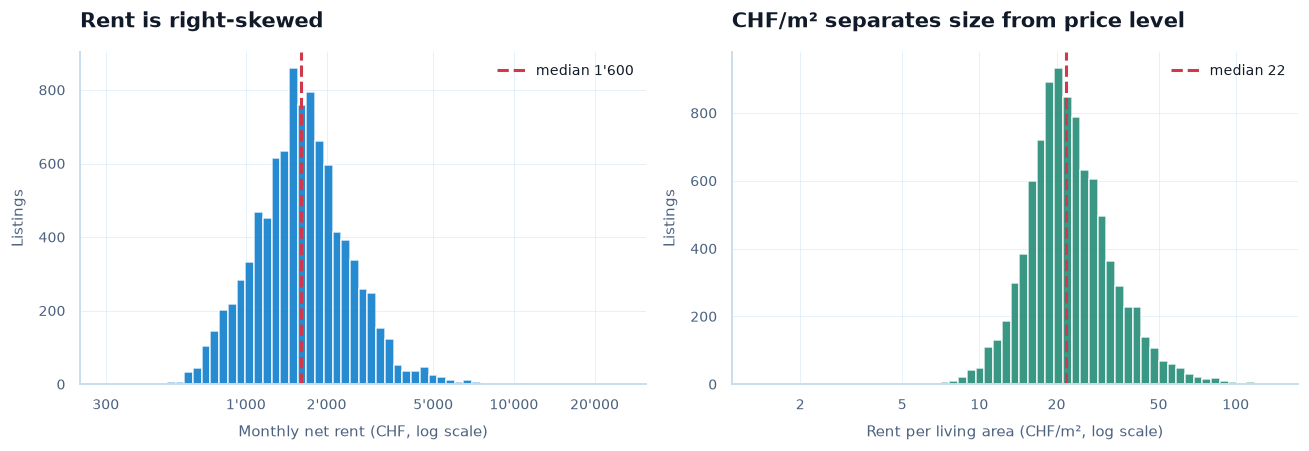

In [9]:
valid = df_raw[(df_raw["price"] > 0) & (df_raw["area"] > 0)]
ppsqm = valid["price"] / valid["area"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, values, label, color, ticks in [
    (axes[0], valid["price"], "Monthly net rent (CHF, log scale)", COLORS["primary"],
     [300, 1000, 2000, 5000, 10000, 20000]),
    (axes[1], ppsqm, "Rent per living area (CHF/m², log scale)", COLORS["teal"],
     [2, 5, 10, 20, 50, 100]),
]:
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 60)
    ax.hist(values, bins=bins, color=color, alpha=0.85)
    ax.axvline(values.median(), color=COLORS["reference"], ls="--",
               label=f"median {values.median():,.0f}".replace(",", "'"))
    ax.set_xscale("log")
    ax.set_xticks([t for t in ticks if values.min() <= t <= values.max()])
    ax.xaxis.set_major_formatter(chf_formatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel(label)
    ax.set_ylabel("Listings")
    ax.legend()
axes[0].set_title("Rent is right-skewed")
axes[1].set_title("CHF/m² separates size from price level")
fig.tight_layout()
save_fig(fig, "rent_distribution", paths.figures)
plt.show()

**Reading the audit.** If the description coverage is below 50 %, `HAS_TEXT` is `False` and all
text sections later in the notebook skip gracefully; this is always the case for the CSV
fallback, which has no descriptions. If the share of half rooms is zero and `rooms_is_integer`
equals "rooms known", the scraper rounded every room count: the flag then carries no half-room
information and is only a missingness indicator, so it is dropped from the features in
section 9. On the log scale the rent looks roughly symmetric, which is why all models are
trained on `log(price)` and evaluated in CHF after back-transformation. The CHF/m² panel shows
the tails that the outlier filter in section 6 has to handle: very low values are typical for
parking spaces or placeholder prices, very high values for small studios or weekly prices.

## 4. Duplicate Audit: From Listings to Rental Objects

The supervisor asked for an explicit duplicate check, and for good reason: the same apartment is
often listed several times (relisted after a few weeks, posted by two agents, or with a slightly
different price). If copies end up on both sides of a split, the test error is too optimistic,
and the DSPRO1 kNN features could even read a listing's own rent from its copy.

We audit in two steps. First, **exact duplicates** (identical coordinates, area, rooms and
rent). Second, **near-duplicates** with `assign_object_ids`, which links listings that share a
slug, an identical (anonymised) description, or the same building (EGID, rounded coordinates or
address) with equal rooms, area within ±3 m² and rent within ±10 %. Linked listings form one
rental object with one `object_id`, the unit of analysis in the evaluation plan.

In [10]:
exact_subsets = {
    "coords + area + rooms + price": ["east", "north", "area", "rooms", "price"],
    "coords + area + price": ["east", "north", "area", "price"],
}
if df_raw["slug"].notna().any():
    exact_subsets["slug"] = ["slug"]
if HAS_TEXT:
    exact_subsets["description"] = ["description"]
exact_dups = pd.Series(
    {name: int(exact_duplicate_mask(df_raw, cols).sum()) for name, cols in exact_subsets.items()},
    name="exact duplicate rows (2nd+ occurrence)",
)
exact_dups.to_frame()

,exact duplicate rows (2nd+ occurrence)
coords + area + rooms + price,727
coords + area + price,740


In [11]:
object_ids = assign_object_ids(df_raw)
dedup = dedup_report(df_raw, object_ids)
metric = dedup["value"]
assert metric.get("exact_dup_groups_split_coords_attrs", 0) == 0, "exact duplicates split apart"
key_metrics = ["rows", "unique_objects", "duplicate_rows", "duplicate_share_pct",
               "objects_with_duplicates", "objects_size_2", "objects_size_3",
               "objects_size_4plus", "max_group_size", "median_rel_price_range_dup_objects"]
display(metric.reindex(key_metrics).round(3).to_frame())
rules = sorted({k.split("_", 1)[1] for k in metric.index if k.startswith(("rows_", "merges_"))})
display(pd.DataFrame({"rows touched": [metric.get(f"rows_{r}") for r in rules],
                      "merges": [metric.get(f"merges_{r}") for r in rules]},
                     index=pd.Index(rules, name="rule")).T)

# Sensitivity: how many objects remain if the building block uses coarser rounded coordinates?
sensitivity = pd.Series(
    {f"coord_round_m={r}": assign_object_ids(df_raw, coord_round_m=r).nunique()
     for r in (5, 25, 50)},
    name="unique objects",
)
sensitivity.to_frame().T

,value
metric,
rows,9405.00
unique_objects,8298.00
duplicate_rows,1107.00
duplicate_share_pct,11.77
objects_with_duplicates,953.00
objects_size_2,834.00
objects_size_3,99.00
objects_size_4plus,20.00
max_group_size,9.00


rule,address,coords,coords_exact,description,egid,listing_id,slug
rows touched,0.0,1101.0,829.0,0.0,923.0,0.0,0.0
merges,0.0,588.0,23.0,0.0,496.0,0.0,0.0


,coord_round_m=5,coord_round_m=25,coord_round_m=50
unique objects,8298,8286,8246


In [12]:
df_obj = collapse_objects(df_raw, object_ids, how="median", median_cols=("price",))
before_after = pd.DataFrame({
    "listings": [len(df_raw), len(df_obj)],
    "unique objects": [object_ids.nunique(), df_obj["object_id"].nunique()],
    "median rent (CHF)": [df_raw["price"].median(), df_obj["price"].median()],
}, index=pd.Index(["before (listings)", "after (one row per object)"], name="stage"))
display(before_after)
print("listings per object:", df_obj["n_listings"].value_counts().sort_index().to_dict())

with tracker.run("dedup_audit", stage="data", tags={"session": SESSION_ID},
                 params={"data_source": DATA_USED, "area_tol": 3.0, "price_rel_tol": 0.10,
                         "coord_round_m": 5.0, "collapse": "median price"}):
    tracker.log_metrics({k: float(v) for k, v in dedup["value"].items() if pd.notna(v)})
    tracker.log_metrics({"n_listings_raw": len(df_raw), "n_objects": len(df_obj)})

,listings,unique objects,median rent (CHF)
stage,,,
before (listings),9405,8298,1600.0
after (one row per object),8298,8298,1600.0


listings per object: {1: 7345, 2: 834, 3: 99, 4: 13, 5: 3, 6: 2, 7: 1, 9: 1}


**Interpretation.** The exact-duplicate count shows what DSPRO1's `drop_duplicates` could see;
the object count shows how many listings are really repeated offers of the same apartment. If
the object count barely moves between 5 m and 50 m rounding, the grouping is not driven by an
arbitrary radius. From here on the notebook works with **one row per object**: the
representative listing is the one with the smallest `listing_id`, and its rent is replaced by
the median rent over all listings of the object (a consensus rent within the ±10 % tolerance).
`object_id` stays in the table and is the group key of every split and CV fold, so no apartment
can appear on both sides of a comparison.

## 5. Geo Hierarchy: Canton > District > Municipality

RQ2 asks whether nested random effects help in **sparsely covered municipalities**. That needs
an official hierarchy for every listing. We join the LV95 coordinates to the municipality
polygons of **swissBOUNDARIES3D** (release 2026-01), which also gives district, canton,
population, land area (without lakes) and an approximate language region. Points in
Liechtenstein or the enclaves Büsingen and Campione are masked explicitly, so they are not
snapped to a Swiss municipality across the border; they get `admin_match = "none"`.

In [13]:
gpkg = geo.download_swissboundaries(paths.data_external, SB3D_VERSION)  # cached after 1st run
admin_units = geo.load_admin_units(gpkg)
foreign_mask = geo.load_foreign_mask(gpkg)
df_geo = geo.assign_admin_units(df_obj, admin_units, exclude=foreign_mask)
df_geo = df_geo.join(geo.nested_group_keys(df_geo))

print(f"{len(admin_units):,} municipalities in {admin_units['district_id'].nunique()} districts "
      f"and {admin_units['canton'].nunique()} cantons (swissBOUNDARIES3D {SB3D_VERSION})")
display(df_geo["admin_match"].value_counts().rename("objects").to_frame())
df_geo[["canton", "district_name", "municipality_name", "lang_region",
        "re_canton", "re_district", "re_municipality"]].head(3)

2,110 municipalities in 144 districts and 26 cantons (swissBOUNDARIES3D 2026-01)


,objects
admin_match,
within,8287
none,11


,canton,district_name,municipality_name,lang_region,re_canton,re_district,re_municipality
listing_id,,,,,,,
1,ZH,Uster,Dübendorf,de,ZH,ZH/109,ZH/109/191
2,VS,Brig,Naters,de,VS,VS/2301,VS/2301/6007
3,VD,Ouest lausannois,Renens (VD),fr,VD,VD/2229,VD/2229/5591


1,186 of 2,110 municipalities have at least one object; median 2, max 443 objects per municipality


,municipalities,objects,objects share
count_bucket,,,
<5,831,1550,0.187
5-20,281,2573,0.310
>20,74,4164,0.502


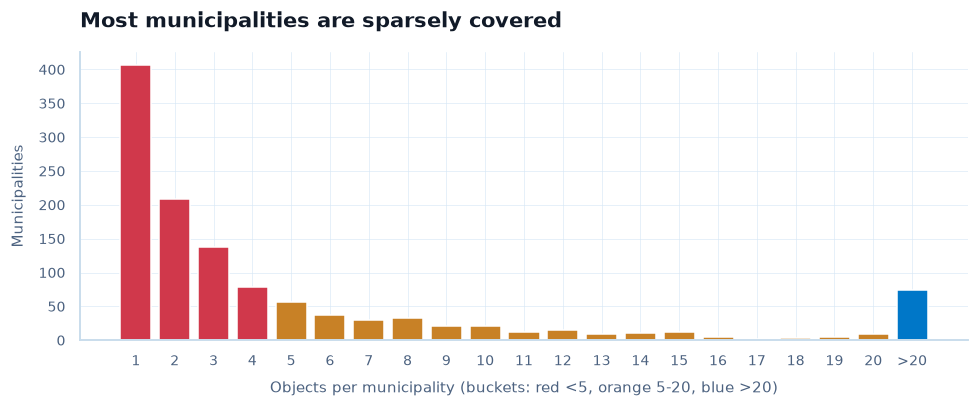

In [14]:
matched = df_geo[df_geo["admin_match"].ne("none")]
per_muni = matched.groupby("municipality_id").size()
bucket = geo.count_bucket(per_muni)
sparse = pd.DataFrame({
    "municipalities": bucket.value_counts(),
    "objects": per_muni.groupby(bucket).sum(),
}).reindex(list(geo.COUNT_BUCKET_ORDER))
sparse["objects share"] = (sparse["objects"] / sparse["objects"].sum()).round(3)
print(f"{per_muni.size:,} of {len(admin_units):,} municipalities have at least one object; "
      f"median {per_muni.median():.0f}, max {per_muni.max():,} objects per municipality")
display(sparse)

capped = per_muni.clip(upper=21).value_counts().reindex(range(1, 22), fill_value=0)
bar_colors = [COLORS["reference"] if n < 5 else COLORS["orange"] if n <= 20 else COLORS["primary"]
              for n in capped.index]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar([str(n) for n in capped.index[:-1]] + [">20"], capped.to_numpy(), color=bar_colors)
ax.set_xlabel("Objects per municipality (buckets: red <5, orange 5-20, blue >20)")
ax.set_ylabel("Municipalities")
ax.set_title("Most municipalities are sparsely covered")
fig.tight_layout()
save_fig(fig, "objects_per_municipality", paths.figures)
plt.show()

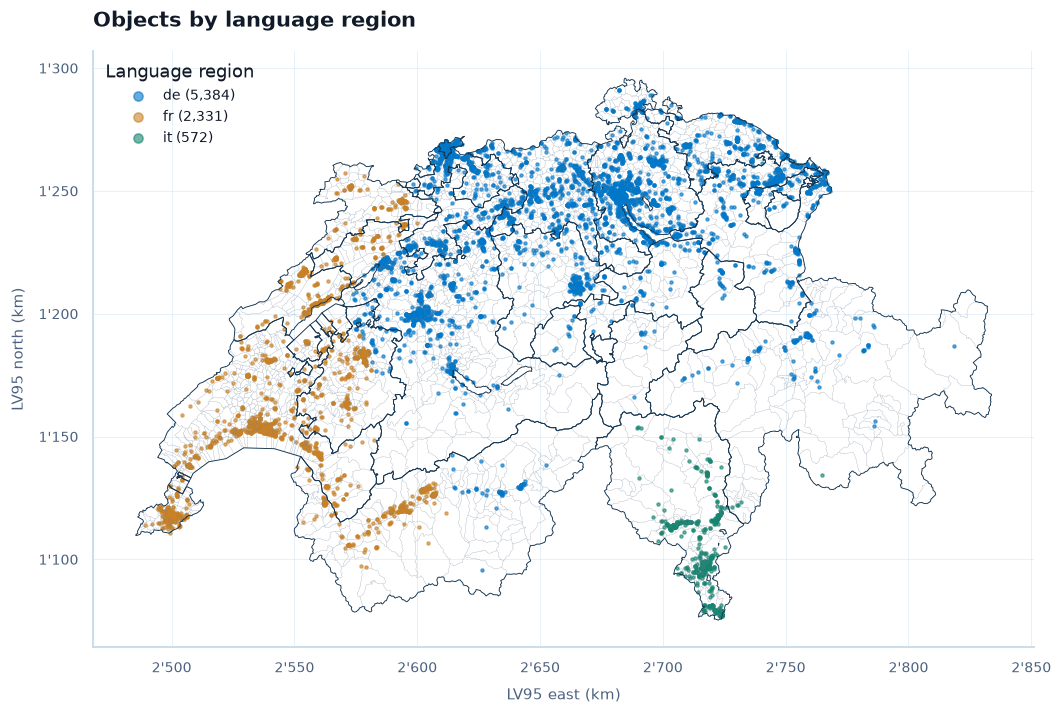

In [15]:
lang_colors = {"de": COLORS["primary"], "fr": COLORS["orange"], "it": COLORS["teal"]}
cantons = admin_units[["canton", "geometry"]].dissolve("canton")
fig, ax = plt.subplots(figsize=(10, 6.5))
admin_units.geometry.simplify(150).boundary.plot(ax=ax, color=COLORS["gray"], linewidth=0.15,
                                                 alpha=0.5)
cantons.geometry.simplify(150).boundary.plot(ax=ax, color=COLORS["dark"], linewidth=0.6)
for lang, part in matched.groupby("lang_region"):
    ax.scatter(part["east"], part["north"], s=4, alpha=0.6, color=lang_colors.get(lang),
               label=f"{lang} ({len(part):,})", rasterized=True)
km = plt.FuncFormatter(lambda v, _: f"{v / 1000:,.0f}".replace(",", "'"))
ax.xaxis.set_major_formatter(km)
ax.yaxis.set_major_formatter(km)
ax.set_xlabel("LV95 east (km)")
ax.set_ylabel("LV95 north (km)")
ax.set_aspect("equal")
ax.legend(title="Language region", markerscale=3, loc="upper left")
ax.set_title("Objects by language region")
fig.tight_layout()
save_fig(fig, "objects_language_map", paths.figures)
plt.show()

**Interpretation.** Almost all objects should fall inside a municipality polygon; the few
`"none"` rows lie abroad or have unusable coordinates and are dropped in section 6. The bucket
table is the core of RQ2: if many municipalities have fewer than 5 objects while most objects
sit in the `>20` bucket, a model that treats each municipality independently (target encoding)
has little to learn from in exactly the places where users most need an estimate, whereas nested
random effects can borrow strength from the district and the canton. The buckets used for the
RQ2 evaluation are recomputed in section 10 **from the training set only**, so they never use
test information. The map shows how the objects are distributed over the language regions,
which later define the Mondrian calibration groups (RQ3); a thin Italian-speaking region means
few calibration listings in that cell.

## 6. Cleaning: Domain Rules and Price-per-m² Outliers

The cleaning stays conservative, as in DSPRO1: only rows that cannot be a market apartment
are removed, and every rule is logged with its count.

- **No admin match:** objects outside Switzerland or without coordinates cannot get a random
  effect or a map cell.
- **Domain rules:** living area 10–500 m² and net rent 300–15,000 CHF (inclusive).
- **Price-per-m² outliers:** a robust z-score (median/MAD) of log CHF/m² within the
  municipality, falling back to district, canton and Switzerland when a group has fewer than
  10 objects; |z| > 3.5 is removed. This catches parking spaces, weekly prices and placeholders
  without cutting genuine expensive apartments, because it compares like with like.

In [16]:
df_matched = df_geo[df_geo["admin_match"].ne("none")].copy()
kept, removed_domain = domain_filter(df_matched)
ppsqm_flag = price_per_sqm_outliers(kept, object_ids=kept["object_id"])
df_clean = kept.loc[~ppsqm_flag].copy()
df_ppsqm_outliers = kept.loc[ppsqm_flag].copy()  # kept aside for an unfiltered robustness check

cleaning_steps = [
    ("raw listings", len(df_raw)),
    ("one row per object (dedup)", len(df_obj)),
    ("admin match in Switzerland", len(df_matched)),
    ("domain rules (area, rent)", len(kept)),
    ("price-per-m² outliers", len(df_clean)),
]
cleaning_table = cleaning_log(cleaning_steps)
(paths.results / "cleaning_log.md").write_text(to_markdown(cleaning_table, index=False) + "\n")
display(cleaning_table)
print("domain removals by reason:", removed_domain["reason"].value_counts().to_dict())

outlier_ppsqm = df_ppsqm_outliers["price"] / df_ppsqm_outliers["area"]
median_ppsqm = (df_clean["price"] / df_clean["area"]).median()
print(f"CHF/m² outliers: {int(ppsqm_flag.sum())} "
      f"({int((outlier_ppsqm < median_ppsqm).sum())} low tail, "
      f"{int((outlier_ppsqm >= median_ppsqm).sum())} high tail); median area of flagged "
      f"objects: {df_ppsqm_outliers['area'].median():.0f} m²")

with tracker.run("cleaning", stage="data", tags={"session": SESSION_ID},
                 params={"data_source": DATA_USED, "z_thresh": 3.5, "min_group": 10}):
    tracker.log_metrics({f"n_after_step_{i}": n for i, (_, n) in enumerate(cleaning_steps)})
    tracker.log_table(cleaning_table, "cleaning_log")

,step,n_rows,removed,removed_pct,retained_pct
0,raw listings,9405,0,0.000000,100.000000
1,one row per object (dedup),8298,1107,11.770335,88.229665
2,admin match in Switzerland,8287,11,0.132562,88.112706
3,"domain rules (area, rent)",8280,7,0.084470,88.038278
4,price-per-m² outliers,8125,155,1.871981,86.390218


domain removals by reason: {'area_above_max': 5, 'price_above_max': 2}
CHF/m² outliers: 155 (40 low tail, 115 high tail); median area of flagged objects: 30 m²


**Interpretation.** The cleaning log is the audit trail for the report: each row says how many
objects a rule removed and what share of the raw listings is left. If the price-per-m² filter
removes mostly high-tail objects with a small median area, it is mainly catching small
studios or furnished short stays, which is worth a manual look before trusting it completely.
Because this filter uses the rent before the split, the flagged objects are kept aside as
`df_ppsqm_outliers`: they are distinct objects that are never in the training set, so section 21
scores the app's point model on them as an "unfiltered" robustness check.

---

## Phase 2 — Text, target population and a frozen evaluation design

## 7. Text Preparation: Anonymisation and Language

The listing description is the new signal in DSPRO2 (RQ1), but it cannot be used as it is.
It contains **personal data** (names, phone numbers, e-mail addresses) that must not leave our
database (revDSG), and it often states the **rent itself**, which would let a text model read
the target instead of predicting it. Every text feature, the rule-based extractor and the LLM
therefore only ever see `description_anon`: contact details and prices are replaced by
placeholders at ingestion, and a leak check measures how many texts still contain a number
within ±3 % of their own rent. The language (DE/FR/IT) is detected on the anonymised text,
because the keyword rules and the calibration groups depend on it.

The anonymiser is first shown on three synthetic listings, one per language, so the behaviour
is visible even when the real descriptions are not available.

In [17]:
demo_texts = pd.Series({
    -1: "Schöne 3.5-Zimmer-Wohnung mit Balkon und Seesicht in 8044 Zürich, Baujahr 1995, "
        "renoviert 2021. Mietzins CHF 2'150.– plus Nebenkosten 250.–. Bezug ab 1. Juli 2026. "
        "Kontakt: Frau Anna Muster, Tel. 079 123 45 67, anna.muster@example.ch",
    -2: "Bel appartement de 4 pièces (95 m²) à Lausanne avec ascenseur et balcon, vue sur le "
        "lac. Loyer: 1'980 CHF + charges 180 CHF. Renseignements: M. Jean Dupont, "
        "+41 21 555 12 34, www.regie-exemple.ch",
    -3: "Appartamento di 2.5 locali a Lugano con terrazza e vista lago, 3° piano, ascensore. "
        "Affitto mensile Fr. 1'450.- spese escluse. Contatto: Sig.ra Maria Rossi, "
        "091 987 65 43, maria.rossi@esempio.ch",
}, name="description")
demo_price = pd.Series({-1: 2150.0, -2: 1980.0, -3: 1450.0})
demo_anon = anonymize_series(demo_texts)
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"language": demo_anon.map(detect_language),
                          "before": demo_texts, "after (description_anon)": demo_anon}))
print(f"price leak rate before: {price_leak_rate(demo_texts.astype('string'), demo_price):.0%}, "
      f"after anonymisation: {price_leak_rate(demo_anon, demo_price):.0%}")

,language,before,after (description_anon)
-1,de,"Schöne 3.5-Zimmer-Wohnung mit Balkon und Seesicht in 8044 Zürich, Baujahr 1995, renoviert 2021. Mietzins CHF 2'150.– plus Nebenkosten 250.–. Bezug ab 1. Juli 2026. Kontakt: Frau Anna Muster, Tel. 079 123 45 67, anna.muster@example.ch","Schöne 3.5-Zimmer-Wohnung mit Balkon und Seesicht in 8044 Zürich, Baujahr 1995, renoviert 2021. Mietzins [PRICE] plus Nebenkosten [PRICE]. Bezug ab 1. Juli 2026. Kontakt: Frau [NAME], Tel. [PHONE], [EMAIL]"
-2,fr,"Bel appartement de 4 pièces (95 m²) à Lausanne avec ascenseur et balcon, vue sur le lac. Loyer: 1'980 CHF + charges 180 CHF. Renseignements: M. Jean Dupont, +41 21 555 12 34, www.regie-exemple.ch","Bel appartement de 4 pièces (95 m²) à Lausanne avec ascenseur et balcon, vue sur le lac. Loyer: [PRICE] + charges [PRICE] Renseignements: M. [NAME], [PHONE], [URL]"
-3,it,"Appartamento di 2.5 locali a Lugano con terrazza e vista lago, 3° piano, ascensore. Affitto mensile Fr. 1'450.- spese escluse. Contatto: Sig.ra Maria Rossi, 091 987 65 43, maria.rossi@esempio.ch","Appartamento di 2.5 locali a Lugano con terrazza e vista lago, 3° piano, ascensore. Affitto mensile [PRICE] spese escluse. Contatto: Sig.ra [NAME], [PHONE], [EMAIL]"


price leak rate before: 100%, after anonymisation: 0%


In [18]:
df_text = df_clean.copy()
df_text["description_anon"] = anonymize_series(df_text["description"])
df_text["text_lang"] = df_text["description_anon"].map(detect_language)
LEAK_RATE = price_leak_rate(df_text["description_anon"], df_text["price"])

if HAS_TEXT:
    print(f"price leak rate after anonymisation: {LEAK_RATE:.2%} (target < 1 %)")
    if LEAK_RATE >= 0.01:
        warnings.warn("More than 1 % of the texts still contain a number close to their rent; "
                      "inspect price_leak_mask(...) before using text features.",
                      stacklevel=2)
    leaks = price_leak_mask(df_text["description_anon"], df_text["price"])
    print(f"texts flagged by the leak check: {int(leaks.sum())} (years or postcodes that happen "
          "to lie within ±3 % of the rent are flagged too)")
    lang_table = pd.DataFrame({
        "objects": df_text["text_lang"].value_counts(),
        "share": df_text["text_lang"].value_counts(normalize=True).round(3),
    })
    lang_table["cross-check: lang_region share"] = (
        df_text["lang_region"].value_counts(normalize=True).round(3))
    display(lang_table)
else:
    print(f"HAS_TEXT is False (data source: {DATA_USED}): no descriptions to anonymise. "
          "description_anon is empty and text_lang is 'unknown' for all rows; the text "
          "sections below skip their real-data steps.")

HAS_TEXT is False (data source: csv): no descriptions to anonymise. description_anon is empty and text_lang is 'unknown' for all rows; the text sections below skip their real-data steps.


In [19]:
F_TEXT_KW: list[str] = []
kw_table = None
if HAS_TEXT:
    kw = keyword_flags(df_text["description_anon"])
    df_text = df_text.join(kw)
    F_TEXT_KW = list(kw.columns)
    has_text = df_text["description_anon"].notna()
    ppsqm_text = (df_text["price"] / df_text["area"])[has_text]
    flags = kw[has_text].astype(bool)
    kw_table = pd.DataFrame({
        "prevalence": flags.mean(),
        "median CHF/m² with": flags.apply(lambda f: ppsqm_text[f].median()),
        "median CHF/m² without": flags.apply(lambda f: ppsqm_text[~f].median()),
    }).sort_values("prevalence", ascending=False)
    kw_table["ratio"] = kw_table["median CHF/m² with"] / kw_table["median CHF/m² without"]
    display(kw_table.round(3))
else:
    print("Keyword flags skipped (no text): F_TEXT_KW = []")

Keyword flags skipped (no text): F_TEXT_KW = []


In [20]:
if kw_table is not None:
    shown = kw_table[kw_table["prevalence"] >= 0.02].sort_values("ratio")
    fig, ax = plt.subplots(figsize=(8, 0.3 * len(shown) + 1.5))
    colors = [COLORS["teal"] if r >= 1 else COLORS["reference"] for r in shown["ratio"]]
    ax.barh(shown.index.str.removeprefix("kw_"), (shown["ratio"] - 1) * 100, color=colors)
    ax.axvline(0, color=COLORS["neutral"], lw=0.8)
    ax.set_xlabel("Median CHF/m² with flag vs without (%)")
    ax.set_title("Raw rent premium of text keywords (not causal)")
    fig.tight_layout()
    save_fig(fig, "keyword_premium", paths.figures)
    plt.show()

**Interpretation.** The synthetic examples show the contract of the anonymiser: names, phone
numbers, e-mail addresses, URLs and every rent figure become placeholders, while the room count,
area, construction year and postcode stay, because they are legitimate features. On real data
the leak rate should stay below 1 %; a small non-zero floor is expected, since years or
postcodes can coincidentally lie within ±3 % of a rent. If the detected text language and the
geographic `lang_region` disagree for a noticeable share, many listings in bilingual regions
are written in the other language, which matters for the per-language extraction quality.
The keyword table is descriptive only: a flag with a higher median CHF/m² (for example lake
view or new build) is a candidate signal for RQ1, but the raw premium mixes the feature with
location and size, so only the controlled ablation in the text sections can say whether it
improves the model.

## 8. Attribute Extraction and Rent Regime

Keywords only say whether a word occurs. The proposal asks for **structured attributes** with
text evidence: floor, lift, balcony or terrace, view, renovation year, furnished, temporary lease,
parking, Minergie, pets and a few more, plus a **rent-regime label**. The regime matters for the
target itself: cooperative, cost-based or subsidised rents and rooms in shared flats sit well
below the market level, so they are excluded from the market-rent target and reported
separately.

We use two extractors with the same schema. The **rule-based extractor** is free, deterministic
and runs on every text; each value carries the verbatim text span as evidence. The **LLM
extractor** (Claude, forced tool call on the anonymised text, cached per text) is optional
because it costs money; here it runs live only on a capped, language-stratified sample and is
compared with the rules. Once a batch run has filled its cache for **every** description, its
labels replace the rules row by row (the rules stay the fallback for failed rows) for the
attribute stage and the regime filter; otherwise the rules are used (`ATTR_SOURCE`). Both
extractors are evaluated against about 300 hand-labelled listings once those labels exist.

In [21]:
demo_attrs = extract_frame(demo_anon, rule_based_extract, include_evidence=True)
with pd.option_context("display.max_colwidth", 120):
    display(demo_attrs.drop(columns=["extractor"]).T)

attr_frame = None
if HAS_TEXT:
    t0 = time.time()
    attr_frame = extract_frame(df_text["description_anon"], rule_based_extract,
                               include_evidence=True)
    attr_cols = [c for c in attr_frame.columns if c.startswith("attr_")]
    has_text = df_text["description_anon"].notna()
    attr_coverage = pd.DataFrame({
        "found in text": attr_frame.loc[has_text, attr_cols].notna().mean(),
        "positive (bool fields)": attr_frame.loc[has_text, attr_cols]
        .apply(lambda c: c.eq(1).mean() if c.dtype.kind == "f" else np.nan),
    }).round(3)
    print(f"rule-based extraction on {int(has_text.sum()):,} texts in {time.time() - t0:.1f}s")
    display(attr_coverage.sort_values("found in text", ascending=False))
else:
    print("Rule-based extraction skipped on real data (no text): attr_frame = None")

,-1,-2,-3
attr_floor,NaN,NaN,3.0
attr_has_lift,NaN,1.0,1.0
attr_has_balcony_or_terrace,1.0,1.0,1.0
attr_view,lake,lake,lake
attr_renovation_year,2021.0,NaN,NaN
attr_is_furnished,NaN,NaN,NaN
attr_is_temporary,NaN,NaN,NaN
attr_parking,none,none,none
attr_is_minergie,NaN,NaN,NaN
attr_pets_allowed,NaN,NaN,NaN


Rule-based extraction skipped on real data (no text): attr_frame = None


In [22]:
def per_language_sample(frame: pd.DataFrame, n_per_lang: int) -> pd.DataFrame:
    # Up to n_per_lang texts per detected language (de/fr/it), fixed seed.
    parts = [g.sample(min(len(g), n_per_lang), random_state=RANDOM_STATE)
             for lang, g in frame.groupby("text_lang") if lang in ("de", "fr", "it")]
    return pd.concat(parts) if parts else frame.iloc[0:0]


LLM_SAMPLE_PER_LANG = 10 if FAST else 100
llm_frame, llm_agreement, extractor = None, None, None
if HAS_TEXT and RUN_LLM and os.environ.get("ANTHROPIC_API_KEY"):
    from rentml.extraction import ClaudeExtractor, ExtractionCache  # lazy: optional llm extra

    extractor = ClaudeExtractor(cache=ExtractionCache(paths.cache / "extraction.jsonl"))
    llm_texts = per_language_sample(df_text.dropna(subset=["description_anon"]),
                                    LLM_SAMPLE_PER_LANG)["description_anon"]
    t0 = time.time()
    llm_frame = extract_frame(llm_texts, extractor, errors="ignore")
    print(f"LLM ({extractor.model}) on {len(llm_texts)} texts in {time.time() - t0:.0f}s")
    fields = [f for f in ATTRIBUTE_FIELDS if f"attr_{f}" in llm_frame.columns]
    # Rules scored against the LLM labels: an agreement check, not an accuracy estimate.
    llm_agreement = evaluate_extraction(attr_frame.loc[llm_frame.index], llm_frame, fields)
    display(llm_agreement.set_index("field")[["support", "precision", "recall", "f1"]].round(3))
elif RUN_LLM:
    print("RUN_LLM=1 but no text or no ANTHROPIC_API_KEY: LLM extraction skipped.")
else:
    print("LLM extraction not requested (DSPRO2_RUN_LLM=0); the rules are used for all rows.")

LLM extraction not requested (DSPRO2_RUN_LLM=0); the rules are used for all rows.


In [23]:
gold_path = paths.data_interim / "extraction_gold.csv"
extraction_eval = None
if HAS_TEXT and gold_path.is_file():
    gold = pd.read_csv(gold_path, index_col="listing_id")
    fields = [f for f in ATTRIBUTE_FIELDS if f in gold.columns or f"attr_{f}" in gold.columns]
    extraction_eval = evaluate_extraction(attr_frame, gold, fields, by=df_text["text_lang"])
    (paths.results / "extraction_eval_rules.md").write_text(
        to_markdown(extraction_eval, index=False) + "\n")
    display(extraction_eval.round(3))
    if llm_frame is not None:
        display(evaluate_extraction(llm_frame, gold, fields, by=df_text["text_lang"]).round(3))
elif HAS_TEXT:
    template = paths.data_interim / "extraction_gold_template.csv"
    todo = per_language_sample(df_text.dropna(subset=["description_anon"]), 100)
    labels = pd.DataFrame("", index=todo.index, columns=list(ATTRIBUTE_FIELDS))
    todo[["text_lang", "description_anon"]].join(labels).to_csv(template)
    print(f"No gold labels yet. Wrote {len(todo)} texts (up to 100 per language) to {template}.\n"
          f"Label them by hand and save the file as {gold_path.name}; this cell then reports "
          "precision/recall/F1 per field and language.")
else:
    print("Gold-label evaluation needs listing text: skipped. With the database source, this "
          "cell writes a language-stratified template of 300 texts for hand labelling "
          f"(saved later as {gold_path.name}).")

Gold-label evaluation needs listing text: skipped. With the database source, this cell writes a language-stratified template of 300 texts for hand labelling (saved later as extraction_gold.csv).


In [24]:
ATTR_SOURCE = "rules" if HAS_TEXT else "none"  # extractor behind F_ATTR and rent_regime
if extractor is not None:
    pending = extractor.batch_requests(df_text["description_anon"].dropna())  # uncached texts
    if pending:
        print(f"LLM cache misses {len(pending):,} distinct descriptions: attributes and regime "
              "come from the rules. Fill the cache with extractor.submit_batch(pending) and "
              "extractor.collect_batch(...) (batch pricing), then rerun to use the LLM labels.")
    else:  # every description is cached: no API call, LLM labels row by row
        llm_all = extract_frame(df_text["description_anon"], extractor, errors="ignore",
                                include_evidence=True)
        llm_ok = llm_all["extractor"].notna()  # failed extractions keep the rule labels
        for col in llm_all.columns:
            attr_frame[col] = llm_all[col].where(llm_ok, attr_frame[col])
        ATTR_SOURCE = "llm"
        print(f"LLM labels for {int(llm_ok.sum()):,} objects, rule fallback for "
              f"{int((~llm_ok).sum()):,}")
print(f"ATTR_SOURCE = {ATTR_SOURCE!r} (attribute stage S3 and rent-regime filter)")

ATTR_SOURCE = 'none' (attribute stage S3 and rent-regime filter)


In [25]:
df_text["rent_regime"] = attr_frame["rent_regime"] if attr_frame is not None else "unknown"
df_market, df_excluded = regime_split(df_text)
regime_table = (
    df_text.assign(ppsqm=df_text["price"] / df_text["area"])
    .groupby("rent_regime")
    .agg(objects=("price", "size"), median_rent_chf=("price", "median"),
         median_chf_per_m2=("ppsqm", "median"))
    .sort_values("objects", ascending=False)
)
display(regime_table.round(1))
print(f"df_market: {len(df_market):,} objects (market-rent target), "
      f"df_excluded: {len(df_excluded):,} objects (reported separately)")
if not HAS_TEXT:
    print("Without text there is no regime evidence: every object is labelled 'unknown' and "
          "treated as market rent, so the target may still contain some non-market rents.")

if HAS_TEXT:
    with tracker.run("attribute_extraction", stage="data", tags={"session": SESSION_ID},
                     params={"data_source": DATA_USED, "extractor": ATTR_SOURCE}):
        tracker.log_metrics({"leak_rate": LEAK_RATE, "n_market": len(df_market),
                             "n_excluded": len(df_excluded)})
        tracker.log_table(attr_coverage, "attribute_coverage")

,objects,median_rent_chf,median_chf_per_m2
rent_regime,,,
unknown,8125,1610.0,21.5


df_market: 8,125 objects (market-rent target), df_excluded: 0 objects (reported separately)
Without text there is no regime evidence: every object is labelled 'unknown' and treated as market rent, so the target may still contain some non-market rents.


**Interpretation.** The demo table shows what the extractor returns per field and which text
span supports it; a field without evidence stays missing instead of being guessed. On real data,
fields with high coverage (balcony, lift, view) are the most promising structured features,
while rare fields can only matter for a few listings. If the regime table shows cooperative or
subsidised objects with a clearly lower median CHF/m² than market objects, removing them makes
the target more homogeneous, which is exactly the argument of the proposal; if the difference
is small, the filter mostly protects the interval calibration against a few extreme cases.
The LLM agreement and the gold-label evaluation show whether the cheaper rule-based
attributes are good enough per language. The attribute stage (S3) and the regime filter use the
LLM labels only when the LLM cache covers every description (`ATTR_SOURCE = "llm"` after a batch
run); otherwise they use the rules, and the LLM sample is an agreement check only (changelog of
the evaluation plan).

## 9. Feature Engineering and Feature Sets

The engineered features are the DSPRO1 ones with a real-estate reading (area per room,
building age, land area per apartment) plus coordinates rotated by 45°, which let axis-aligned
tree splits follow diagonal price gradients such as lake shores. The feature lists are defined
once here, so that every model in the ablation uses exactly the same columns:

- `F_TAB`: listing, building and location features without coordinates and without any target
  encoding (the "tabular" stage).
- `F_GEO_LGBM`: `F_TAB` plus LV95 and rotated coordinates; the target-encoded hierarchy columns
  are added later inside the cross-validation, so they are never fitted on validation rows.
- `GROUP_COLS`: the nested random-effect keys canton > district > municipality.
- `F_TEXT_KW` and `F_ATTR`: keyword flags and extracted attributes (empty without text).

**Schema fix from the text.** The DSPRO1 scraper stored whole room counts (3.5 became 4). If the
description states a half room within 0.5 of the stored count, or the count is missing, the text
value is used (`recover_rooms_from_text`, only with text). A missing living area cannot be
recovered here, because section 6 removes those objects before any text is read, and gross rents
cannot be flagged, because the DSPRO1 schema has no gross/net indicator (both recorded in the
changelog of the evaluation plan).

In [26]:
from rentml.cleaning import recover_rooms_from_text

df_base = df_market
if attr_frame is not None:  # schema fix: half rooms and missing room counts from the text
    rooms_fixed, rooms_source = recover_rooms_from_text(df_market["rooms"],
                                                        attr_frame["attr_rooms"])
    df_base = df_market.assign(rooms=rooms_fixed,
                               rooms_is_integer=rooms_fixed.notna() & (rooms_fixed % 1 == 0))
    ROOMS_INTEGER_ONLY = bool(df_base["rooms_is_integer"].eq(df_base["rooms"].notna()).all())
    print("room counts by source:", rooms_source.value_counts().to_dict())
df_model = add_engineered_features(df_base, reference_year=REFERENCE_YEAR)
df_model["log_price"] = np.log(df_model["price"])
F_ATTR: list[str] = []
if attr_frame is not None:
    attr_all = [c for c in attr_frame.columns if c.startswith("attr_")]
    df_model = df_model.join(attr_frame[attr_all])
    # area/rooms from text feed the schema fix above; they are not features themselves
    F_ATTR = [c for c in attr_all if c not in ("attr_area_sqm", "attr_rooms")]

F_TAB = [c for c in BASE + BUILDING + LOCATION
         if not (c == "rooms_is_integer" and ROOMS_INTEGER_ONLY)]
F_GEO_LGBM = F_TAB + COORDS + ROT_COORDS
GROUP_COLS = ["re_canton", "re_district", "re_municipality"]
missing_cols = [c for c in F_GEO_LGBM + GROUP_COLS + F_TEXT_KW + F_ATTR if c not in df_model]
assert not missing_cols, f"feature columns missing: {missing_cols}"
print(f"df_model: {len(df_model):,} objects x {df_model.shape[1]} columns")
print(f"rooms_is_integer dropped from F_TAB: {ROOMS_INTEGER_ONLY}")
print(f"F_TAB ({len(F_TAB)}): {F_TAB}")
print(f"F_GEO_LGBM adds {COORDS + ROT_COORDS}; GROUP_COLS = {GROUP_COLS}")
print(f"F_TEXT_KW: {len(F_TEXT_KW)} columns, F_ATTR: {len(F_ATTR)} columns")

df_model: 8,125 objects x 49 columns
rooms_is_integer dropped from F_TAB: True
F_TAB (14): ['area', 'rooms', 'area_per_room', 'year_built', 'building_age', 'apartments', 'land_area', 'land_area_per_apartment', 'population', 'oev', 'solar', 'elevation', 'muni_density', 'muni_population']
F_GEO_LGBM adds ['east', 'north', 'rot45_x', 'rot45_y']; GROUP_COLS = ['re_canton', 're_district', 're_municipality']
F_TEXT_KW: 0 columns, F_ATTR: 0 columns


In [27]:
FEATURE_DESCRIPTIONS = {
    "area": "living area (m²)", "rooms": "number of rooms (NaN if implausible)",
    "area_per_room": "area / rooms (m² per room)",
    "rooms_is_integer": "whole room count (missingness indicator on DSPRO1 data)",
    "year_built": "construction year (GWR)", "building_age": f"{REFERENCE_YEAR} − year built",
    "apartments": "dwellings in the building (GWR)", "land_area": "GWR building area (m²)",
    "land_area_per_apartment": "GWR building area per dwelling (m²)",
    "population": "population (DSPRO1 swisstopo enrichment)",
    "oev": "public-transport quality score", "solar": "solar suitability class",
    "elevation": "elevation (m a.s.l.)",
    "muni_density": "inhabitants per km² of municipal land area (lakes excluded)",
    "muni_population": "municipal population (swissBOUNDARIES3D)",
    "east": "LV95 east (m)", "north": "LV95 north (m)",
    "rot45_x": "LV95 rotated by 45° (x)", "rot45_y": "LV95 rotated by 45° (y)",
    "re_canton": "canton key", "re_district": "canton/district key",
    "re_municipality": "canton/district/municipality key",
}
groups = ([("tabular", c) for c in F_TAB] + [("coordinates", c) for c in COORDS + ROT_COORDS]
          + [("hierarchy (RE / TE)", c) for c in GROUP_COLS]
          + [("text keywords", c) for c in F_TEXT_KW] + [("text attributes", c) for c in F_ATTR])
feature_table = pd.DataFrame(groups, columns=["group", "feature"])
feature_table["description"] = feature_table["feature"].map(FEATURE_DESCRIPTIONS).fillna(
    feature_table["feature"].str.replace("_", " "))
feature_table["missing %"] = feature_table["feature"].map(
    lambda c: round(100 * df_model[c].isna().mean(), 1))
(paths.results / "feature_table.md").write_text(to_markdown(feature_table, index=False) + "\n")
feature_table.style.hide(axis="index")

group,feature,description,missing %
tabular,area,living area (m²),0.000000
tabular,rooms,number of rooms (NaN if implausible),0.200000
tabular,area_per_room,area / rooms (m² per room),0.200000
tabular,year_built,construction year (GWR),51.500000
tabular,building_age,2026 − year built,51.500000
tabular,apartments,dwellings in the building (GWR),51.500000
tabular,land_area,GWR building area (m²),51.500000
tabular,land_area_per_apartment,GWR building area per dwelling (m²),51.500000
tabular,population,population (DSPRO1 swisstopo enrichment),5.200000
tabular,oev,public-transport quality score,51.500000


**Interpretation.** The missing-value column shows the price of the larger dataset: building
and swisstopo features exist only for the rows that DSPRO1 could enrich, so a large share of
missing values in `BUILDING` is expected and handled natively by the tree models (no
imputation). If `muni_density` and `muni_population` are complete, every object has at least
some municipal context, even without the DSPRO1 enrichment. Coordinates and hierarchy keys are
complete by construction after section 6.

## 10. Train / Calibration / Test Split and Cross-Validation Folds

The split is made **once**, before any model is compared, and then frozen:

- **60 % train** for fitting, tuning and grouped cross-validation,
- **20 % calibration** only for the conformal intervals (RQ3),
- **20 % test** only for the final comparisons, touched once per research question.

The split is grouped by `object_id` and stratified by canton × price quartile, so every set
covers the regions and price levels in similar proportions. The assignment is written to
`data/interim` and reused as long as the set of objects does not change. The
listings-per-municipality buckets for RQ2 are computed **from the training set only**: a test
object in a municipality with fewer than 5 training objects is exactly the sparse case that
RQ2 is about.

In [28]:
strata = make_strata(df_model, min_stratum=20)
fresh = train_calib_test_split(df_model, group_col="object_id", strata=strata)
split_col = pd.Series({i: k for k, idx in fresh.items() for i in idx}, name="split")
split_file = paths.data_interim / f"split_v1_{DATA_USED}.parquet"
if split_file.is_file():
    frozen = pd.read_parquet(split_file)["split"]
    if frozen.index.sort_values().equals(df_model.index.sort_values()):
        print(f"reusing frozen split {split_file.name}; identical to a fresh split: "
              f"{frozen.reindex(split_col.index).eq(split_col).all()}")
        split_col = frozen
    else:
        print(f"{split_file.name} covers other objects (data changed): writing a new split")
split_col.rename_axis("listing_id").to_frame().to_parquet(split_file)

df_model["split"] = split_col.reindex(df_model.index)
splits = {k: df_model.index[df_model["split"].eq(k)] for k in ("train", "calib", "test")}
assert_no_group_leakage(splits, df_model["object_id"])
TEST_SHA = hashlib.sha256(",".join(map(str, sorted(splits["test"]))).encode()).hexdigest()
print({k: len(v) for k, v in splits.items()}, f"test sha256: {TEST_SHA[:16]}…")

reusing frozen split split_v1_csv.parquet; identical to a fresh split: True
{'train': 4875, 'calib': 1625, 'test': 1625} test sha256: 4e56167f535f8172…


In [29]:
muni_counts_train = geo.listings_per_unit(df_model.loc[splits["train"]], col="municipality_id")
df_model["muni_bucket"] = pd.Categorical(
    geo.count_bucket(df_model["municipality_id"].map(muni_counts_train)),
    categories=list(geo.COUNT_BUCKET_ORDER), ordered=True)
train_df, calib_df, test_df = (df_model.loc[splits[k]] for k in ("train", "calib", "test"))

summary = split_summary(df_model, splits, ["price", "area", "canton"])
display(summary[["n", "share", "n_groups", "price_median", "area_median", "canton_n_unique"]])
shares = (pd.crosstab(df_model["split"], df_model["lang_region"], normalize="index")
          .add_prefix("lang_").join(pd.crosstab(df_model["split"], df_model["muni_bucket"],
                                                normalize="index").add_prefix("bucket_")))
display(shares.loc[["train", "calib", "test"]].round(3))

,n,share,n_groups,price_median,area_median,canton_n_unique
train,4875,0.6,4875,1600.0,77.0,26
calib,1625,0.2,1625,1610.0,77.0,26
test,1625,0.2,1625,1607.0,76.0,25
all,8125,1.0,8125,1610.0,77.0,26


,lang_de,lang_fr,lang_it,bucket_<5,bucket_5-20,bucket_>20
split,,,,,,
train,0.647,0.284,0.069,0.271,0.376,0.353
calib,0.652,0.279,0.068,0.317,0.334,0.349
test,0.649,0.282,0.069,0.307,0.355,0.338


In [30]:
cv_folds = grouped_cv_folds(train_df, group_col="object_id", n_splits=BUDGET["cv_folds"],
                            strata=strata)
spatial_folds = spatial_cv_folds(train_df, spatial_col="municipality_id",
                                 n_splits=BUDGET["cv_folds"])
train_groups = train_df["object_id"].to_numpy()
train_munis = train_df["municipality_id"].to_numpy()
for name, folds in [("grouped (object)", cv_folds), ("spatial (municipality)", spatial_folds)]:
    assert all(not set(train_groups[tr]) & set(train_groups[va]) for tr, va in folds)
    sizes = [len(va) for _, va in folds]
    print(f"{name}: {len(folds)} folds, validation sizes {sizes}")
assert all(not set(train_munis[tr]) & set(train_munis[va]) for tr, va in spatial_folds), \
    "spatial folds share a municipality"

with tracker.run("splits", stage="data", tags={"session": SESSION_ID},
                 params={"data_source": DATA_USED, "fractions": "0.6/0.2/0.2",
                         "cv_folds": BUDGET["cv_folds"], "test_sha256": TEST_SHA[:16]}):
    tracker.log_metrics({f"n_{k}": len(v) for k, v in splits.items()})
    tracker.log_metrics({"n_municipalities_train": len(muni_counts_train)})

grouped (object): 5 folds, validation sizes [976, 975, 975, 975, 974]
spatial (municipality): 5 folds, validation sizes [975, 975, 975, 975, 975]


**Interpretation.** If the median rent, the language shares and the bucket shares are close
across train, calibration and test, the stratification worked and the test set is a fair
sample of the population. The test set usually has a **larger** share of the `<5` bucket than
train would suggest, because buckets are counted from training objects only: this is intended,
since it mirrors deployment, where many municipalities have few observed listings. Grouped
folds are used for model selection and tuning; spatial folds, where a whole municipality is
held out, are the harder robustness check for transfer to unseen places.

## 11. Pre-Registered Evaluation Plan and Minimum Detectable Effect

Before the first model comparison, the evaluation plan
([`docs/EVALUATION_PLAN.md`](../docs/EVALUATION_PLAN.md)) fixes the primary
metric, the hypotheses and tests, the order of decisions and the budgets. The constants live in
`rentml.config`, so this notebook cannot silently drift from the plan.

One number is still open: the **minimum detectable effect (MDE)**. A paired comparison on a
test set of a given size can only detect MAE differences above a certain size with 80 % power.
We estimate it by simulation on real per-listing errors: a quick LightGBM on `F_TAB` +
coordinates (a DSPRO1-like baseline without kNN features and without target encoding) gives
out-of-fold absolute errors on the training set, and a second LightGBM without coordinates
provides the pairing (how strongly the errors of two models move together).

In [31]:
plan = pd.DataFrame([
    ("primary metric", "MAE in CHF on the frozen hold-out test set"),
    ("significance level α", ALPHA_TEST),
    ("paired bootstrap resamples", f"{N_BOOTSTRAP} (this run: {BUDGET['n_boot']})"),
    ("multiple testing", "Holm across the RQ1 ablation stages"),
    ("split", "60/20/20, grouped by object_id, stratified canton × price quartile"),
    ("CV folds on train", f"5 (this run: {BUDGET['cv_folds']})"),
    ("Optuna trials (LightGBM)", f"60 (this run: {BUDGET['optuna_trials']})"),
    ("interval coverage", INTERVAL_COVERAGE),
    ("quantile levels", ", ".join(f"{q:.2f}" for q in QUANTILE_LEVELS)),
    ("min. calibration listings per Mondrian cell", MIN_MONDRIAN_GROUP),
    ("min. listings per published map cell", MIN_MAP_CELL),
    ("random seed", RANDOM_STATE),
    ("order of decisions", "RQ2 → RQ1 (on the RQ2 winner) → RQ3 (on that model)"),
], columns=["item", "value"])
plan["value"] = plan["value"].astype(str)
plan.style.hide(axis="index")

item,value
primary metric,MAE in CHF on the frozen hold-out test set
significance level α,0.05
paired bootstrap resamples,2000 (this run: 2000)
multiple testing,Holm across the RQ1 ablation stages
split,"60/20/20, grouped by object_id, stratified canton × price quartile"
CV folds on train,5 (this run: 5)
Optuna trials (LightGBM),60 (this run: 60)
interval coverage,0.8
quantile levels,"0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95"
min. calibration listings per Mondrian cell,100


In [32]:
y_train = train_df["price"].to_numpy()
y_train_log = train_df["log_price"].to_numpy()
t0 = time.time()
oof_geo = fit_predict_cv(lambda: make_lgbm(), train_df[F_TAB + COORDS], y_train_log, cv_folds)
oof_tab = fit_predict_cv(lambda: make_lgbm(), train_df[F_TAB], y_train_log, cv_folds)
abs_err_geo = np.abs(y_train - np.exp(oof_geo))
abs_err_tab = np.abs(y_train - np.exp(oof_tab))
baseline_cv = pd.DataFrame({
    "LightGBM F_TAB + coordinates (reference A)": regression_metrics(y_train, np.exp(oof_geo)),
    "LightGBM F_TAB only (pairing model B)": regression_metrics(y_train, np.exp(oof_tab)),
}).T
print(f"{len(cv_folds)}-fold grouped CV on {len(train_df):,} training objects "
      f"in {time.time() - t0:.1f}s")
display(baseline_cv.round(3))

5-fold grouped CV on 4,875 training objects in 4.0s


,MAE,RMSE,MedAE,MAPE,R2
LightGBM F_TAB + coordinates (reference A),274.056,437.995,185.955,15.406,0.708
LightGBM F_TAB only (pairing model B),312.732,489.680,215.354,17.599,0.635


In [33]:
test_sizes = sorted({len(test_df), 2000, 3000, 4000, 5000, 6000})
t0 = time.time()
power = power_mde(abs_err_geo, abs_err_b=abs_err_tab, test_sizes=test_sizes,
                  rel_effects=np.round(np.arange(0.005, 0.1005, 0.005), 3),
                  n_sim=BUDGET["power_sims"], seed=RANDOM_STATE)
ERROR_RHO, PAIR_SD_RATIO = float(power["rho"].iloc[0]), float(power["pair_sd_ratio"].iloc[0])
mde_table = (power.groupby("test_size")[["mde_rel", "mde_chf"]].first()
             .join(power[power["rel_effect"].eq(0.05)].set_index("test_size")["power"]
                   .rename("power_at_5pct")))
print(f"{BUDGET['power_sims']} simulations per cell in {time.time() - t0:.1f}s; "
      f"error correlation rho = {ERROR_RHO:.2f}, pair SD ratio = {PAIR_SD_RATIO:.2f}")

mde_md = pd.DataFrame({
    "Test-set size": [f"{n:,}".replace(",", "'") + (" (this test set)" if n == len(test_df)
                                                    else "") for n in mde_table.index],
    "MDE (relative MAE reduction)": [f"{r:.1%}" if pd.notna(r) else "> 10 %"
                                     for r in mde_table["mde_rel"]],
    "MDE (CHF)": [f"{c:.0f}" if pd.notna(c) else "–" for c in mde_table["mde_chf"]],
})
header = (f"<!-- power_mde: n_sim={BUDGET['power_sims']}, rho={ERROR_RHO:.2f}, "
          f"reference CV MAE={abs_err_geo.mean():.0f} CHF, data={DATA_USED}, run={RUN_MODE} -->\n")
(paths.results / "mde_table.md").write_text(header + to_markdown(mde_md, index=False) + "\n")
display(mde_md.style.hide(axis="index"))

500 simulations per cell in 1.2s; error correlation rho = 0.87, pair SD ratio = 0.54


Test-set size,MDE (relative MAE reduction),MDE (CHF)
1'625 (this test set),5.0%,14
2'000,4.5%,12
3'000,3.5%,10
4'000,3.0%,8
5'000,3.0%,8
6'000,3.0%,8


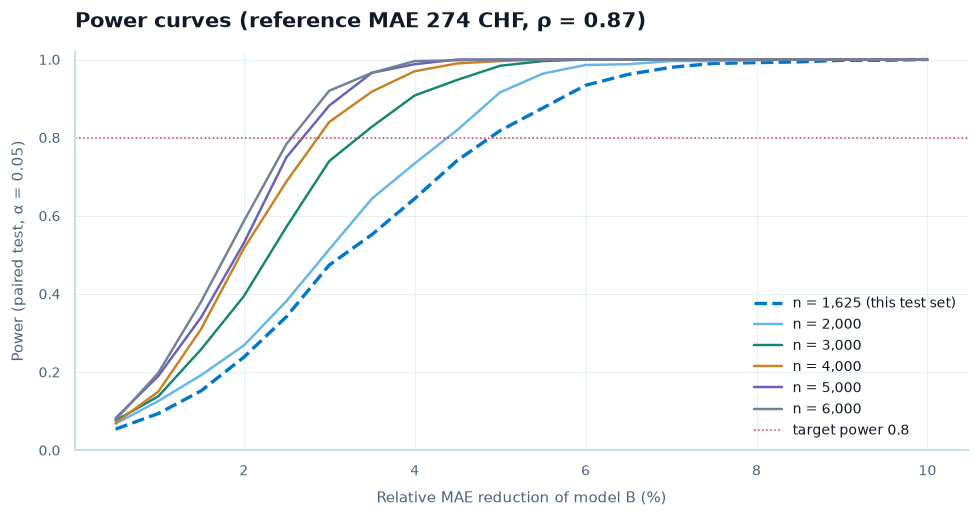

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for color, (n, part) in zip(PALETTE, power.groupby("test_size"), strict=False):
    is_test = n == len(test_df)
    ax.plot(part["rel_effect"] * 100, part["power"], color=color, lw=2.2 if is_test else 1.6,
            ls="--" if is_test else "-", label=f"n = {n:,}" + (" (this test set)" if is_test else ""))
ax.axhline(0.8, color=COLORS["reference"], lw=1, ls=":", label="target power 0.8")
ax.set_xlabel("Relative MAE reduction of model B (%)")
ax.set_ylabel("Power (paired test, α = 0.05)")
ax.set_ylim(0, 1.02)
ax.set_title(f"Power curves (reference MAE {abs_err_geo.mean():,.0f} CHF, ρ = {ERROR_RHO:.2f})")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
save_fig(fig, "power_curves", paths.figures)
plt.show()

with tracker.run("power_mde", stage="eval-plan", tags={"session": SESSION_ID},
                 params={"data_source": DATA_USED, "n_sim": BUDGET["power_sims"],
                         "reference": "lgbm F_TAB+COORDS", "pairing": "lgbm F_TAB"}):
    tracker.log_metrics({"cv_mae": float(abs_err_geo.mean()),
                         "cv_mae_tab": float(abs_err_tab.mean()),
                         "error_rho": ERROR_RHO, "pair_sd_ratio": PAIR_SD_RATIO})
    tracker.log_metrics({f"mde_rel_{n}": v for n, v in mde_table["mde_rel"].items()
                         if pd.notna(v)})
    tracker.log_table(mde_table, "mde_table")

**Interpretation.** Each curve shows how often a true relative MAE reduction of the given size
would be declared significant. The MDE is where a curve crosses 0.8. The pairing matters a lot:
the more strongly the two models' errors move together (higher ρ), the smaller the detectable
effect, because the per-listing differences are less noisy. Using a model without coordinates
as the pairing partner is deliberately conservative; the RQ2 and RQ1 comparisons are between
closer models, so their real power is likely higher. If the MDE for the size of this test set
is larger than the improvements we can realistically expect (a few percent of MAE), a
non-significant result must be reported as "no detectable difference", not as "no difference",
and the per-bucket comparisons in RQ2, with far fewer test objects, are exploratory by design.

**Before tagging `eval-plan-v1`.** Run this notebook once in full mode (`DSPRO2_RUN_MODE=full`,
500 simulations) on the frozen data source, copy the rows of `docs/results/mde_table.md`
into the MDE table in section 4 of `EVALUATION_PLAN.md` (the HTML comment in the file records
ρ, the reference MAE and the data source), add a changelog line, commit, and tag the commit with
`git tag eval-plan-v1`. Only after that tag are the models in the next sections compared.

---

## Phase 3 — Location: baselines, spatial mixed effects and the RQ2 decision

## 12. Baselines: Naive Rate, DSPRO1 Reproduction and Learning Curve

Every model in this phase has to beat two references.

- The **naive baseline** is the landlord's rule of thumb: the median rent per m² of the
  municipality times the living area. If a municipality has fewer than 5 training objects, the
  rate comes from the district, then the canton, then the whole country. The evaluation plan
  requires this baseline in every table, because a model that cannot clearly beat it adds
  nothing.
- The **DSPRO1 champion recipe** is LightGBM with the mean and median rent of the 10 nearest
  training listings as features. We reproduce it for two reasons: to measure how far DSPRO2 has
  moved, and to check the weakness that motivates RQ2.

All models except the naive baseline are trained on `log_price`. Every error is reported in CHF
after the back-transform, always on the same grouped folds (`cv_folds`) and the same frozen
hold-out objects. From here on, `pred_test`, `pred_calib` and `cv_oof` collect the CHF
predictions of every model, so later sections can compare them without refitting anything.

In [35]:
from dataclasses import asdict, replace

from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

from rentml.evaluation import (
    bootstrap_ci,
    comparison_table,
    learning_curve,
    paired_bootstrap_mae,
    segment_metrics,
)
from rentml.features import HierarchicalTargetEncoder, knn_price_features, monotone_vector
from rentml.fusion import UNKNOWN_LABEL, FusedRentRegressor, FusionConfig
from rentml.models import NaiveMunicipalityBaseline, make_te_lgbm, tune_lgbm_optuna
from rentml.plotting import to_latex
from rentml.spatial import GPBoostConfig, GPBoostRegressor, morans_i
from rentml.text import SentenceEmbedder, reduce_embeddings

y_train, y_train_log = train_df["price"].to_numpy(), train_df["log_price"].to_numpy()
y_calib, y_test = calib_df["price"].to_numpy(), test_df["price"].to_numpy()
groups_test = test_df["object_id"].to_numpy()
BUCKETS = list(geo.COUNT_BUCKET_ORDER)
bucket_test = test_df["muni_bucket"].astype(str).to_numpy()
BUCKET_KEYS = {"<5": "lt5", "5-20": "5_20", ">20": "gt20"}
pred_test: dict[str, np.ndarray] = {}   # model -> CHF predictions on the test objects
pred_calib: dict[str, np.ndarray] = {}  # model -> CHF predictions on the calibration objects
cv_oof: dict[str, np.ndarray] = {}      # model -> out-of-fold CHF predictions on train


def test_metrics(pred: np.ndarray) -> dict[str, float]:
    # Hold-out metrics in CHF with tracking names, incl. MAE per listings-per-municipality bucket.
    out = {f"test_{k.lower()}": v for k, v in regression_metrics(y_test, pred).items()}
    for bucket, key in BUCKET_KEYS.items():
        mask = bucket_test == bucket
        out[f"test_mae_{key}"] = float(np.mean(np.abs(y_test[mask] - pred[mask])))
    return out


def cv_mae(name: str) -> float:
    return float(np.mean(np.abs(y_train - cv_oof[name])))

In [36]:
naive = NaiveMunicipalityBaseline(levels=("municipality_id", "district_id", "canton"))
naive.fit(train_df)
pred_test["naive"], pred_calib["naive"] = naive.predict(test_df), naive.predict(calib_df)
cv_oof["naive"] = np.exp(fit_predict_cv(lambda: NaiveMunicipalityBaseline(log_target=True),
                                        train_df, y_train_log, cv_folds))
naive_test = test_metrics(pred_test["naive"])
rate_source = naive.rate_source(test_df).value_counts(normalize=True).rename("share of test objects")

with tracker.run("naive", stage="baseline", tags={"session": SESSION_ID, "model": "naive"},
                 params={"levels": "municipality>district>canton>national", "min_count": 5,
                         "data_source": DATA_USED}):
    tracker.log_metrics({"cv_mae": cv_mae("naive"), **naive_test,
                         "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["naive"])))})

print(f"naive baseline: CV MAE {cv_mae('naive'):,.0f} CHF, test MAE {naive_test['test_mae']:,.0f} "
      f"CHF (R² {naive_test['test_r2']:.3f})")
print("test MAE per bucket (CHF): " + ", ".join(
    f"{b} {naive_test[f'test_mae_{k}']:,.0f}" for b, k in BUCKET_KEYS.items()))
display(rate_source.to_frame().style.format("{:.1%}"))

naive baseline: CV MAE 352 CHF, test MAE 355 CHF (R² 0.618)
test MAE per bucket (CHF): <5 376, 5-20 314, >20 378


,share of test objects
rate_source,
municipality_id,69.3%
district_id,29.7%
canton,0.9%
global,0.1%


**Interpretation.** The naive baseline sets the floor: any model in this phase has to be
clearly below its MAE. The rate-source table shows where the rule of thumb has to fall back to a
coarser level: every test object whose rate comes from the district or canton sits in a
municipality with fewer than 5 training objects. The larger that share, the more the result
depends on how a model handles **sparse municipalities**, which is exactly what RQ2 asks. If the
`<5` bucket has a clearly higher MAE than the `>20` bucket, the coarse fallback costs accuracy,
and a model that borrows strength more cleverly should gain most there.

### 12.1 DSPRO1 reproduction: are leave-one-out kNN rent features leaky?

DSPRO1 computed the kNN rent features of a training listing **leave-one-out**: its 10 nearest
*other* training listings. The listing itself is excluded, but a relisting of the same apartment
is not, and it usually shares the building coordinates. Its rent then enters the listing's own
"neighbourhood" median, and cross-validation rewards a model for trusting that feature. Outside
the training set, no copy of the apartment is available, so the advantage disappears.

We make this measurable with four protocols that all use the same LightGBM, the same features
(`F_TAB` + coordinates + kNN mean/median) and the same hold-out objects:

| | Training rows | kNN features of training rows | CV folds |
|---|---|---|---|
| A | **listings** incl. relistings (as in DSPRO1) | leave-one-out | random K-fold (as in DSPRO1) |
| B | listings incl. relistings | leave-one-out | grouped by object |
| C | **objects** (after the duplicate audit) | leave-one-out | grouped by object |
| D | objects | **out-of-fold** | grouped by object |

For the listing rows, every training object is expanded back to its listings with their own
advertised rent. The test features always come from all training rows, so A and B are the same
model with the same test score and differ only in how it was validated. A CV score is never
exactly the test score: each CV model sees only (K−1)/K of the training objects, so even the
clean protocol D usually has a CV MAE a bit above its test MAE. The leak therefore shows up as
**optimism relative to D**: `(test − CV)` of a protocol minus `(test − CV)` of D. A positive
value means the protocol's CV score looks better than its test score justifies.

In [37]:
# DSPRO1 trained on listings: expand every training object back to its listings (own rents)
obj_pos = pd.Series(np.arange(len(train_df)), index=train_df["object_id"].to_numpy())
listing_obj = object_ids[object_ids.isin(obj_pos.index)]
listing_obj = listing_obj[df_raw.loc[listing_obj.index, "price"].gt(0).to_numpy()]  # rent known
lst_pos = obj_pos.loc[listing_obj.to_numpy()].to_numpy()  # train_df position of each listing
train_listings = (train_df.iloc[lst_pos].set_axis(listing_obj.index)
                  .assign(price=df_raw.loc[listing_obj.index, "price"].to_numpy()))
folds_listing = [(np.flatnonzero(np.isin(lst_pos, tr)), np.flatnonzero(np.isin(lst_pos, va)))
                 for tr, va in cv_folds]
folds_random = list(KFold(len(cv_folds), shuffle=True, random_state=RANDOM_STATE)
                    .split(train_listings))
n_relisted = int((train_df["n_listings"] > 1).sum())
price_differs = train_listings.groupby("object_id")["price"].nunique().gt(1).sum()
print(f"{len(train_listings):,} training listings for {len(train_df):,} objects; "
      f"{n_relisted:,} objects are relisted, {price_differs:,} of them with differing rents")

KNN_COLS = ["knn_price_mean", "knn_price_median"]
F_DSPRO1 = F_TAB + COORDS + KNN_COLS


def dspro1_knn(frame: pd.DataFrame, folds: list, mode: str) -> dict:
    # DSPRO1 recipe: kNN rent features + LightGBM; OOF on `frame`, then refit -> calib/test.
    knn = knn_price_features(frame, mode=mode, folds=folds if mode == "oof" else None)
    X, y_log = frame[F_TAB + COORDS].join(knn), np.log(frame["price"].to_numpy())
    oof = np.exp(fit_predict_cv(lambda: make_lgbm(), X[F_DSPRO1], y_log, folds))
    model = make_lgbm().fit(X[F_DSPRO1], y_log)
    out = {"oof": oof, "cv_mae": float(np.mean(np.abs(frame["price"].to_numpy() - oof)))}
    for split, new in (("calib", calib_df), ("test", test_df)):
        X_new = new[F_TAB + COORDS].join(knn_price_features(frame, apply_df=new))
        out[split] = np.exp(model.predict(X_new[F_DSPRO1]))
    return out

5,521 training listings for 4,875 objects; 561 objects are relisted, 168 of them with differing rents


In [38]:
PROTOCOLS = {  # key -> (description, training rows, CV folds, kNN mode of the training rows)
    "A": ("DSPRO1: listings, LOO kNN, random folds", train_listings, folds_random, "loo"),
    "B": ("listings, LOO kNN, grouped folds", train_listings, folds_listing, "loo"),
    "C": ("objects, LOO kNN, grouped folds", train_df, cv_folds, "loo"),
    "D": ("objects, OOF kNN, grouped folds", train_df, cv_folds, "oof"),
}
t0 = time.perf_counter()
knn_runs = {key: dspro1_knn(frame, folds, mode)
            for key, (_, frame, folds, mode) in PROTOCOLS.items()}
leak_table = pd.DataFrame({
    "protocol": [desc for desc, *_ in PROTOCOLS.values()],
    "training rows": [len(frame) for _, frame, *_ in PROTOCOLS.values()],
    "cv_mae": [r["cv_mae"] for r in knn_runs.values()],
    "test_mae": [float(np.mean(np.abs(y_test - r["test"]))) for r in knn_runs.values()],
}, index=pd.Index(list(PROTOCOLS), name="key"))
leak_table["test_minus_cv"] = leak_table["test_mae"] - leak_table["cv_mae"]
leak_table["optimism_vs_D"] = leak_table["test_minus_cv"] - leak_table.loc["D", "test_minus_cv"]
(paths.results / "dspro1_knn_leakage.md").write_text(to_markdown(leak_table) + "\n")
print(f"4 protocols x {len(cv_folds)} folds in {time.perf_counter() - t0:.1f}s")
display(leak_table.round(1))

# DSPRO1 benchmark recipe (B = A refitted), object-level OOF from the grouped protocol B
pred_test["dspro1_knn"], pred_calib["dspro1_knn"] = knn_runs["B"]["test"], knn_runs["B"]["calib"]
cv_oof["dspro1_knn"] = (pd.Series(knn_runs["B"]["oof"]).groupby(lst_pos).mean()
                        .reindex(range(len(train_df))).to_numpy())  # mean over an object's listings
pred_test["dspro1_knn_oof"] = knn_runs["D"]["test"]
pred_calib["dspro1_knn_oof"], cv_oof["dspro1_knn_oof"] = knn_runs["D"]["calib"], knn_runs["D"]["oof"]
for name, key, mode, rows in [("dspro1_knn", "B", "loo", "listings"),
                              ("dspro1_knn_oof", "D", "oof", "objects")]:
    with tracker.run(name, stage="dspro1", tags={"session": SESSION_ID, "model": name},
                     params={"knn_mode": mode, "k": 10, "training_rows": rows,
                             "features": "F_TAB+COORDS+knn", "data_source": DATA_USED}):
        tracker.log_metrics({"cv_mae": cv_mae(name), **test_metrics(pred_test[name]),
                             "cv_mae_protocol": leak_table.loc[key, "cv_mae"]})
        if key == "B":
            tracker.log_metrics({"cv_mae_random_folds": leak_table.loc["A", "cv_mae"]})
            tracker.log_table(leak_table, "dspro1_knn_leakage")

4 protocols x 5 folds in 11.1s


,protocol,training rows,cv_mae,test_mae,test_minus_cv,optimism_vs_D
key,,,,,,
A,"DSPRO1: listings, LOO kNN, random folds",5521,249.6,270.7,21.1,25.8
B,"listings, LOO kNN, grouped folds",5521,272.0,270.7,-1.3,3.4
C,"objects, LOO kNN, grouped folds",4875,273.0,271.9,-1.1,3.6
D,"objects, OOF kNN, grouped folds",4875,277.4,272.7,-4.7,0.0


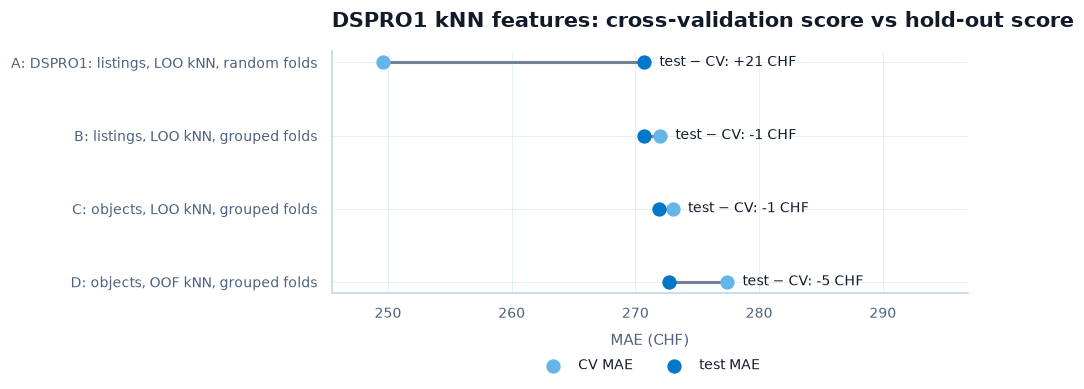

DSPRO1 protocol A is optimistic: its CV MAE is 25.8 CHF lower than the clean protocol D would predict (B, grouped folds: +3.4 CHF).
Test MAE with LOO features (B) 271 CHF vs OOF features (D) 273 CHF.


In [39]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ypos = np.arange(len(leak_table))[::-1]  # protocol A on top
maes = leak_table[["cv_mae", "test_mae"]].to_numpy()
for y, (cv, te) in zip(ypos, maes, strict=True):
    ax.plot([cv, te], [y, y], color=COLORS["gray"], lw=2, zorder=1)
    ax.annotate(f"test − CV: {te - cv:+.0f} CHF", (max(cv, te), y), xytext=(10, 0),
                textcoords="offset points", va="center", fontsize=9)
ax.scatter(maes[:, 0], ypos, s=70, color=COLORS["secondary"], zorder=2, label="CV MAE")
ax.scatter(maes[:, 1], ypos, s=70, color=COLORS["primary"], zorder=2, label="test MAE")
ax.set_yticks(ypos, [f"{k}: {d}" for k, d in leak_table["protocol"].items()])
span = max(maes.max() - maes.min(), 20.0)
ax.set_xlim(maes.min() - 0.15 * span, maes.max() + 0.7 * span)  # room for the labels
ax.xaxis.set_major_formatter(chf_formatter())
ax.set_xlabel("MAE (CHF)")
ax.set_title("DSPRO1 kNN features: cross-validation score vs hold-out score")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncols=2, frameon=False)
fig.tight_layout()
save_fig(fig, "dspro1_knn_leakage", paths.figures)
plt.show()

opt_a, opt_b = leak_table.loc["A", "optimism_vs_D"], leak_table.loc["B", "optimism_vs_D"]
verdict = "optimistic" if opt_a > 0 else "not optimistic"
print(f"DSPRO1 protocol A is {verdict}: its CV MAE is {abs(opt_a):.1f} CHF "
      f"{'lower' if opt_a > 0 else 'higher'} than the clean protocol D would predict "
      f"(B, grouped folds: {opt_b:+.1f} CHF).")
print(f"Test MAE with LOO features (B) {leak_table.loc['B', 'test_mae']:,.0f} CHF vs "
      f"OOF features (D) {leak_table.loc['D', 'test_mae']:,.0f} CHF.")

**Interpretation.** The printed verdict and the `optimism_vs_D` column carry the result. If
protocol A has a clearly positive optimism, the DSPRO1 validation overstated the model: random
folds put relistings of the same apartment on both sides of the split, and the leave-one-out
neighbourhood hands a listing the rent of its own relisting. Protocol B isolates the feature leak
(the split is grouped, only the kNN features still see relistings), and C shows what is left once
the duplicate audit has merged the relistings. If the optimism shrinks from A to C, most of the
DSPRO1 leak came from the duplicates, and the object table of section 4 already removes it.

Two further points decide how location should enter DSPRO2. First, compare the **test** MAEs: if
LOO and OOF features give about the same hold-out error, the kNN features are not useless, they
are only validated wrongly, and every tuning decision made on their CV score would have been
biased. Second, even clean kNN features are an in-sample aggregate of target values with no notion
of uncertainty: a listing in a municipality with two training neighbours gets a feature as
confident as one in the city of Zurich. This is why DSPRO2 replaces them with models that shrink
sparse areas explicitly (sections 13–14). The DSPRO1 recipe stays in the comparison as
`dspro1_knn` (as in the DSPRO1 benchmark, LOO features) and `dspro1_knn_oof` (clean features).
Both runs are tracked under the stage `dspro1`; the ablation table of section 24 excludes the LOO
run from its CV-based selection, so it can never pick the leaky CV score of the benchmark recipe
as the DSPRO1 row.

### 12.2 Learning curve: would more data help?

The proposal aims at about 30,000 unique objects accumulated over several weeks, but only if that
volume is actually needed. A learning curve answers this on the current data: LightGBM on `F_TAB`
plus coordinates is refitted on nested random subsets of 20 % to 100 % of the training *objects*
of each grouped fold and always scored on the complete validation fold.

In [40]:
X_lc = train_df[F_GEO_LGBM]


def lgbm_fit_predict(train_pos: np.ndarray, val_pos: np.ndarray) -> np.ndarray:
    model = make_lgbm().fit(X_lc.iloc[train_pos], y_train_log[train_pos])
    return np.exp(model.predict(X_lc.iloc[val_pos]))


t0 = time.perf_counter()
lc = learning_curve(lgbm_fit_predict, len(train_df), folds=cv_folds, y=y_train,
                    groups=train_df["object_id"])
slope, intercept = np.polyfit(np.log(lc["n_train_mean"]), np.log(lc["mae_mean"]), 1)
n_max = lc["n_train_mean"].iloc[-1]
gain_last = 1 - lc["mae_mean"].iloc[-1] / lc["mae_mean"].iloc[-2]
mae_double = float(np.exp(intercept) * (2 * n_max) ** slope)
print(f"{len(lc) * len(cv_folds)} fits in {time.perf_counter() - t0:.1f}s; power-law slope {slope:.3f} "
      f"(MAE ∝ n^{slope:.2f})")
print(f"last step ({lc['fraction'].iloc[-2]:.0%} -> 100% of the objects): MAE {gain_last:+.1%} "
      f"lower; doubling the objects projects {mae_double:,.0f} CHF "
      f"({mae_double / lc['mae_mean'].iloc[-1] - 1:+.1%})")
with tracker.run("learning_curve", stage="diagnostics", tags={"session": SESSION_ID},
                 params={"model": "lgbm F_GEO_LGBM", "folds": len(cv_folds)}):
    tracker.log_metrics({"lc_slope": float(slope), "lc_gain_last_step": float(gain_last),
                         "lc_mae_projected_2x": mae_double})
    tracker.log_table(lc, "learning_curve")

25 fits in 11.0s; power-law slope -0.084 (MAE ∝ n^-0.08)
last step (80% -> 100% of the objects): MAE +2.9% lower; doubling the objects projects 256 CHF (-5.1%)


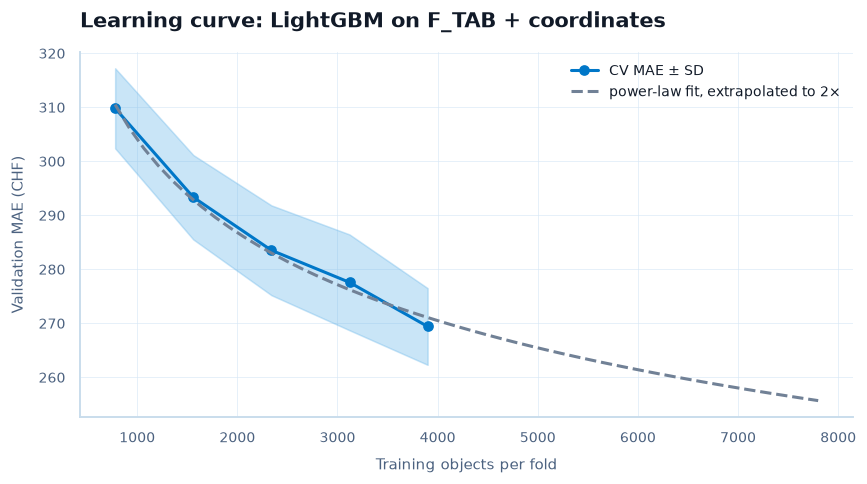

In [41]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(lc["n_train_mean"], lc["mae_mean"] - lc["mae_std"],
                lc["mae_mean"] + lc["mae_std"], color=COLORS["secondary"], alpha=0.35)
ax.plot(lc["n_train_mean"], lc["mae_mean"], "o-", color=COLORS["primary"], label="CV MAE ± SD")
n_grid = np.linspace(lc["n_train_mean"].iloc[0], 2 * n_max, 50)
ax.plot(n_grid, np.exp(intercept) * n_grid**slope, ls="--", color=COLORS["gray"],
        label="power-law fit, extrapolated to 2×")
ax.set_xlabel("Training objects per fold")
ax.set_ylabel("Validation MAE (CHF)")
ax.yaxis.set_major_formatter(chf_formatter())
ax.set_title("Learning curve: LightGBM on F_TAB + coordinates")
ax.legend()
fig.tight_layout()
save_fig(fig, "learning_curve", paths.figures)
plt.show()

**Interpretation.** If the curve still falls noticeably at 100 % (a clearly negative slope and a
last-step gain of several percent), the model is **data-limited** and the accumulation of more
listings planned in the proposal is worth the effort. If it has flattened, more of the same
listings will not help much, and the remaining error has to come from better features (the text in
RQ1) or better handling of location (RQ2). The power-law extrapolation is only a rough guide: it
assumes that new listings come from the same regions and price segments, whereas new data would in
practice fill the sparse municipalities first, where the gain is likely larger than the average
curve suggests.

## 13. LightGBM with Coordinates and Out-of-Fold Target Encoding (RQ2 Comparator)

The RQ2 comparison model is the strongest *conventional* way to put location into a tree model:

- **coordinates** (LV95) and the same coordinates **rotated by 45°**, so that axis-aligned splits
  can follow diagonal price gradients;
- **hierarchical target encoding** of canton, district and municipality: the mean log rent of a
  municipality shrunk towards its district, which is shrunk towards its canton
  (`HierarchicalTargetEncoder`, pseudo-count 20). Training rows get **out-of-fold** encodings, so a
  row never sees its own rent;
- a **monotone constraint on the living area**: at equal location, building and number of rooms, a
  larger flat never gets a lower predicted rent. Because `area_per_room = area / rooms` moves with
  the area, it is constrained as well (a deviation from the plan, recorded in its changelog): in
  the CSV development run, constraining `area` alone left 94 of 1'625 test flats with a lower
  estimate after enlarging them (found by the what-if check in section 23). `rooms` has no
  constraint of its own; through `area_per_room`, more rooms at equal area can only lower that
  feature's contribution. This keeps the what-if view of the app plausible.

Tuning uses Optuna on the grouped folds with the complete pipeline `make_te_lgbm`: the encoder is
refitted inside every fold, so the validation objects never influence their own encodings. The
tuned setting is then refitted on the full training set. The same fitted encoder produces the
matrices `X_train_lgb`, `X_calib_lgb` and `X_test_lgb` that the quantile models of RQ3 and the
SHAP explanations (section 20) reuse.

60 trials (36 pruned) in 474s; best CV MAE 265.1 CHF (trial 24)


,learning_rate,n_estimators,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,reg_alpha
tuned value,0.011826,1750.0,37.0,9.0,0.711232,0.415594,0.051147,0.236577


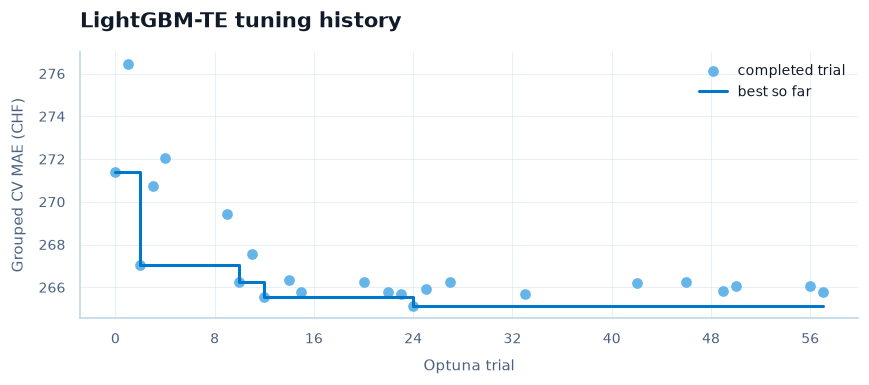

In [42]:
TE_INPUT = F_GEO_LGBM + GROUP_COLS + ["object_id"]
# area_per_room is derived from area, so both must be non-decreasing for a monotone what-if.
MONOTONE_INCREASING = ("area", "area_per_room")


def te_lgbm(params: dict | None = None):
    # RQ2 comparator: TE refitted inside the pipeline, monotone non-decreasing in area.
    return make_te_lgbm(F_GEO_LGBM, te_cols=GROUP_COLS, group_col="object_id", params=params,
                        monotone_increasing=MONOTONE_INCREASING)


t0 = time.perf_counter()
lgb_params, lgb_study = tune_lgbm_optuna(train_df[TE_INPUT], y_train_log, cv_folds,
                                         n_trials=BUDGET["optuna_trials"], model_factory=te_lgbm,
                                         seed=RANDOM_STATE)
trials = lgb_study.trials_dataframe(attrs=("number", "value", "state"))
done = trials[trials["state"].eq("COMPLETE")]
print(f"{len(trials)} trials ({len(trials) - len(done)} pruned) in {time.perf_counter() - t0:.0f}s; "
      f"best CV MAE {lgb_study.best_value:,.1f} CHF (trial {lgb_study.best_trial.number})")
display(pd.Series(lgb_params, name="tuned value").to_frame().T)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(done["number"], done["value"], color=COLORS["secondary"], label="completed trial")
ax.plot(done["number"], done["value"].cummin(), drawstyle="steps-post", color=COLORS["primary"],
        label="best so far")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Optuna trial")
ax.set_ylabel("Grouped CV MAE (CHF)")
ax.yaxis.set_major_formatter(chf_formatter())
ax.set_title("LightGBM-TE tuning history")
ax.legend()
fig.tight_layout()
save_fig(fig, "lgbm_te_tuning", paths.figures)
plt.show()

In [43]:
oof_lgbm_te = fit_predict_cv(lambda: te_lgbm(lgb_params), train_df[TE_INPUT], y_train_log,
                             cv_folds)
cv_oof["lgbm_te"] = np.exp(oof_lgbm_te)

te_encoder = HierarchicalTargetEncoder(cols=tuple(GROUP_COLS), group_col="object_id")
te_train = te_encoder.fit_transform(train_df[GROUP_COLS + ["object_id"]], y_train_log)  # OOF
X_train_lgb = pd.concat([te_train, train_df[F_GEO_LGBM]], axis=1)
X_calib_lgb = pd.concat([te_encoder.transform(calib_df), calib_df[F_GEO_LGBM]], axis=1)
X_test_lgb = pd.concat([te_encoder.transform(test_df), test_df[F_GEO_LGBM]], axis=1)
F_LGB = list(X_train_lgb.columns)
t0 = time.perf_counter()
lgb_point = make_lgbm(lgb_params, monotone=monotone_vector(F_LGB, increasing=MONOTONE_INCREASING))
lgb_point.fit(X_train_lgb, y_train_log)
pred_calib["lgbm_te"] = np.exp(lgb_point.predict(X_calib_lgb))
pred_test["lgbm_te"] = np.exp(lgb_point.predict(X_test_lgb))
# the explicit matrices reproduce the tuned pipeline exactly (same encoder folds and seed)
pipe_check = te_lgbm(lgb_params).fit(train_df[TE_INPUT], y_train_log)
same = np.allclose(np.log(pred_test["lgbm_te"]), pipe_check.predict(test_df[TE_INPUT]))

cv_lgbm = regression_metrics(y_train, cv_oof["lgbm_te"])
with tracker.run("lgbm_te", stage="tabular+geo", tags={"session": SESSION_ID, "model": "lgbm_te"},
                 params={"lgbm": lgb_params, "features": "F_TAB+COORDS+ROT_COORDS+TE",
                         "n_features": len(F_LGB), "te_smoothing": te_encoder.smoothing,
                         "monotone": ",".join(MONOTONE_INCREASING),
                         "optuna_trials": BUDGET["optuna_trials"],
                         "cv_folds": len(cv_folds), "data_source": DATA_USED}):
    tracker.log_metrics({"cv_mae": cv_lgbm["MAE"], "cv_rmse": cv_lgbm["RMSE"],
                         "cv_r2": cv_lgbm["R2"], "optuna_best_cv_mae": lgb_study.best_value,
                         "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["lgbm_te"]))),
                         **test_metrics(pred_test["lgbm_te"])})  # test: read in section 15
print(f"LightGBM-TE: CV MAE {cv_lgbm['MAE']:,.1f} CHF, CV R² {cv_lgbm['R2']:.3f}; "
      f"{len(F_LGB)} features; refit in {time.perf_counter() - t0:.1f}s; matrices == pipeline: {same}")
print(f"CV MAE of the DSPRO1 recipe with clean OOF kNN features: {cv_mae('dspro1_knn_oof'):,.1f} CHF")

LightGBM-TE: CV MAE 265.1 CHF, CV R² 0.718; 21 features; refit in 4.6s; matrices == pipeline: True
CV MAE of the DSPRO1 recipe with clean OOF kNN features: 277.4 CHF


In [44]:
# Ablation stage "tabular" (evaluation plan, section 6): the same learner and settings without any
# location signal (no coordinates, no encodings), so the "+geo" gain of the ablation is measured.
def tab_lgbm():
    return make_lgbm(lgb_params, monotone=monotone_vector(F_TAB, increasing=MONOTONE_INCREASING))


cv_oof["lgbm_tab"] = np.exp(fit_predict_cv(tab_lgbm, train_df[F_TAB], y_train_log, cv_folds))
lgb_tab = tab_lgbm().fit(train_df[F_TAB], y_train_log)
pred_calib["lgbm_tab"] = np.exp(lgb_tab.predict(calib_df[F_TAB]))
pred_test["lgbm_tab"] = np.exp(lgb_tab.predict(test_df[F_TAB]))
with tracker.run("lgbm_tab", stage="tabular", tags={"session": SESSION_ID, "model": "lgbm_tab"},
                 params={"lgbm": lgb_params, "features": "F_TAB", "n_features": len(F_TAB),
                         "monotone": ",".join(MONOTONE_INCREASING), "cv_folds": len(cv_folds),
                         "data_source": DATA_USED}):
    tracker.log_metrics({"cv_mae": cv_mae("lgbm_tab"),
                         "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["lgbm_tab"]))),
                         **test_metrics(pred_test["lgbm_tab"])})  # test: read in section 24
print(f"LightGBM on F_TAB only (ablation stage 'tabular'): CV MAE {cv_mae('lgbm_tab'):,.1f} CHF "
      f"vs {cv_mae('lgbm_te'):,.1f} CHF with coordinates and target encodings")

LightGBM on F_TAB only (ablation stage 'tabular'): CV MAE 304.1 CHF vs 265.1 CHF with coordinates and target encodings


**Interpretation.** The CV MAE of the tuned model is slightly optimistic, because Optuna chose the
setting on the same folds (nested CV would cost K times the tuning budget). It is used only to
compare with the other CV scores of this phase; the unbiased number is the hold-out MAE in
section 15, which is logged with the model but not looked at before both RQ2 models are frozen.
If the target-encoded model reaches about the CV MAE of the DSPRO1 recipe with clean kNN features,
the kNN features can be dropped without loss: the encoding carries the same location signal with
explicit shrinkage for small municipalities. `matrices == pipeline: True` confirms that the
matrices reused later produce exactly the predictions of the tuned pipeline. The `lgbm_tab` run
is the "tabular" row of the pre-registered ablation: the same learner and settings on `F_TAB`
only. The gap between its CV MAE and that of LightGBM-TE is the value of the location
information; it reuses the tuned parameters, so it is not tuned for its own feature set.

## 14. GPBoost: Boosting with Nested Random Effects and a Spatial Gaussian Process (RQ2 Candidate)

GPBoost (Sigrist, JMLR 2022, developed at HSLU) models the log rent as

$$\log(\text{rent}) = F(\mathbf{x}) + b_{\text{canton}} + b_{\text{district}} + b_{\text{municipality}} + g(\mathbf{s}) + \varepsilon,$$

with tree boosting for the fixed effects $F$, **nested random intercepts** for the administrative
hierarchy and a **Gaussian process** $g$ on the LV95 coordinates for the micro-location (Matérn
covariance, Vecchia approximation with 20 neighbours). Unlike the target encoding, where a fixed
pseudo-count sets the shrinkage, the strength of the shrinkage follows from **estimated variance
components**. A municipality with two listings is therefore pulled towards its district by an
amount the data itself determines, and every prediction comes with a predictive variance.

To keep the comparison clean, the trees see only `F_TAB`, with no coordinates and no encodings:
location enters **only** through the random effects and the GP. Any gain over section 13 is then
attributable to the spatial model, not to extra features.

### 14.1 Why the fit is two-stage

gpboost's default estimates the covariance parameters (the three random-effect variances, the GP
variance and range, and the error variance) anew in every boosting round. On this data that failed
in two ways. It took about 12 s per round, and, more importantly, it converged to a **degenerate
solution**: the error variance collapsed to about $5 \cdot 10^{-7}$. Many listings share the
building coordinates of the GWR, so the GP can interpolate the training rents exactly at those
points. The model then had a training MAE of 0 and 80 % intervals that covered only 62 % of new
listings. The likelihood is not wrong; the model is simply allowed to explain a rent by "this
exact coordinate is expensive".

The fit is therefore **two-stage** (recorded in the changelog of the evaluation plan):

1. The covariance parameters are estimated **once** in a linear mixed model with the same
   random-effect structure and data-driven starting values (about half of the variance as error
   variance), which keeps the optimiser away from the degenerate corner.
2. The boosting runs with these parameters **fixed**, at learning rate 0.01 without line search
   (line search gave the same accuracy at 20 times the cost per round).

The number of boosting rounds is chosen by early stopping on one grouped fold carved from the
training set (never calibration or test). The model is then refitted on the full training set,
where stage 1 is repeated on all training objects.

early-stopping fit on 3,899 objects in 203s (stage 1: 137s); best round 30 of 400


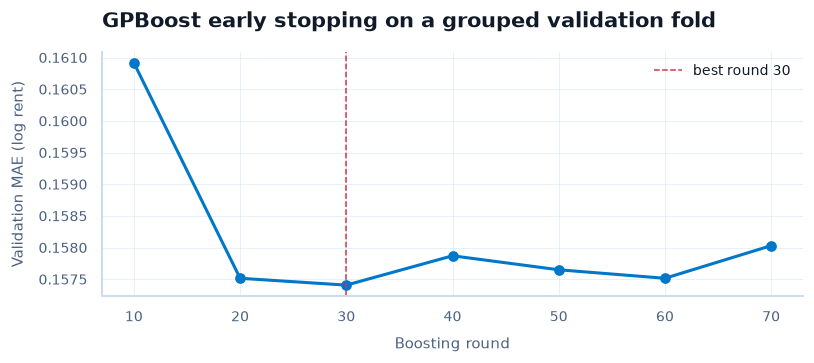

In [45]:
GPB_CFG = GPBoostConfig(group_cols=tuple(GROUP_COLS), num_boost_round=BUDGET["gpb_rounds"],
                        learning_rate=0.01, line_search_step_length=False, eval_every=10,
                        num_threads=8)
es_train_pos, es_val_pos = cv_folds[0]  # grouped validation fold inside train
fit_part, val_part = train_df.iloc[es_train_pos], train_df.iloc[es_val_pos]
t0 = time.perf_counter()
gpb_es = GPBoostRegressor(GPB_CFG).fit(
    fit_part[F_TAB], fit_part["log_price"], fit_part[GROUP_COLS], fit_part[COORDS],
    eval_set=(val_part[F_TAB], val_part["log_price"], val_part[GROUP_COLS], val_part[COORDS]),
    early_stopping_rounds=40)
GPB_ROUNDS = int(gpb_es.best_iteration_)
print(f"early-stopping fit on {len(fit_part):,} objects in {time.perf_counter() - t0:.0f}s "
      f"(stage 1: {gpb_es.cov_.fit_time_s:.0f}s); best round {GPB_ROUNDS} of "
      f"{GPB_CFG.num_boost_round}")
if gpb_es.best_iteration_ >= GPB_CFG.num_boost_round:
    print("note: best round at the budget limit; a larger BUDGET['gpb_rounds'] may help")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(gpb_es.eval_iterations_, gpb_es.evals_result_["valid"]["l1"], "o-",
        color=COLORS["primary"])
ax.axvline(GPB_ROUNDS, color=COLORS["reference"], ls="--", lw=1, label=f"best round {GPB_ROUNDS}")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Validation MAE (log rent)")
ax.set_title("GPBoost early stopping on a grouped validation fold")
ax.legend()
fig.tight_layout()
save_fig(fig, "gpboost_early_stopping", paths.figures)
plt.show()

In [46]:
t0 = time.perf_counter()
gpb_model = GPBoostRegressor(replace(GPB_CFG, num_boost_round=GPB_ROUNDS)).fit(
    train_df[F_TAB], train_df["log_price"], train_df[GROUP_COLS], train_df[COORDS])
mu_calib, gpb_var_calib = gpb_model.predict(calib_df[F_TAB], calib_df[GROUP_COLS],
                                            calib_df[COORDS], return_var=True)
mu_test, gpb_var_test = gpb_model.predict(test_df[F_TAB], test_df[GROUP_COLS], test_df[COORDS],
                                          return_var=True)
pred_calib["gpboost"], pred_test["gpboost"] = np.exp(mu_calib), np.exp(mu_test)  # median scale
z80 = 1.2816  # raw Gaussian 80 % interval on the log scale (calibrated properly in RQ3)
cover80 = float(np.mean(np.abs(np.log(y_calib) - mu_calib) <= z80 * np.sqrt(gpb_var_calib)))
print(f"full fit on {len(train_df):,} objects in {time.perf_counter() - t0:.0f}s "
      f"(stage 1: {gpb_model.cov_.fit_time_s:.0f}s)")
print(f"raw 80 % Gaussian interval coverage on calibration: {cover80:.3f}")


def gpb_fit_predict(train_pos: np.ndarray, val_pos: np.ndarray) -> np.ndarray:
    # Fold fit with the train-level covariance parameters (stage 1 is not repeated).
    a, b = train_df.iloc[train_pos], train_df.iloc[val_pos]
    model = GPBoostRegressor(replace(GPB_CFG, num_boost_round=GPB_ROUNDS)).fit(
        a[F_TAB], a["log_price"], a[GROUP_COLS], a[COORDS], cov_pars=gpb_model.cov_)
    return model.predict(b[F_TAB], b[GROUP_COLS], b[COORDS])


t0 = time.perf_counter()
oof_gpb = np.full(len(train_df), np.nan)
for tr, va in cv_folds:
    oof_gpb[va] = gpb_fit_predict(tr, va)
cv_oof["gpboost"] = np.exp(oof_gpb)
cv_gpb = regression_metrics(y_train, cv_oof["gpboost"])
print(f"GPBoost: CV MAE {cv_gpb['MAE']:,.1f} CHF, CV R² {cv_gpb['R2']:.3f} "
      f"({len(cv_folds)} folds in {time.perf_counter() - t0:.0f}s) | LightGBM-TE: {cv_mae('lgbm_te'):,.1f} CHF")

full fit on 4,875 objects in 130s (stage 1: 122s)
raw 80 % Gaussian interval coverage on calibration: 0.881


GPBoost: CV MAE 276.9 CHF, CV R² 0.703 (5 folds in 27s) | LightGBM-TE: 265.1 CHF


The cross-validation reuses the covariance parameters estimated once on the full training set;
only the trees are refitted per fold. Re-running stage 1 in every fold would cost one to two
minutes each. This is a documented approximation: it can make the GPBoost CV score slightly
optimistic (the variances saw the validation objects) but does not affect the hold-out test, where
the final model was fitted on the training set only.

The printed raw coverage is a first check of the two-stage fit. The degenerate joint fit covered
only 62 % of new listings with its nominal 80 % Gaussian intervals. If the two-stage model is close
to or above 80 % on the calibration objects, the error variance is no longer collapsed. RQ3 turns
these variances into calibrated intervals; this number is only a diagnostic.

component,parameter,variance,share
residual,error_variance,0.04053,46.5%
canton,Group_1,0.01519,17.4%
district,Group_2,0.0008408,1.0%
municipality,Group_3,0.002162,2.5%
gp_variance,GP_var,0.02849,32.7%
gp_range,GP_range,13.41,–
gp_practical_range,derived,36.73,–


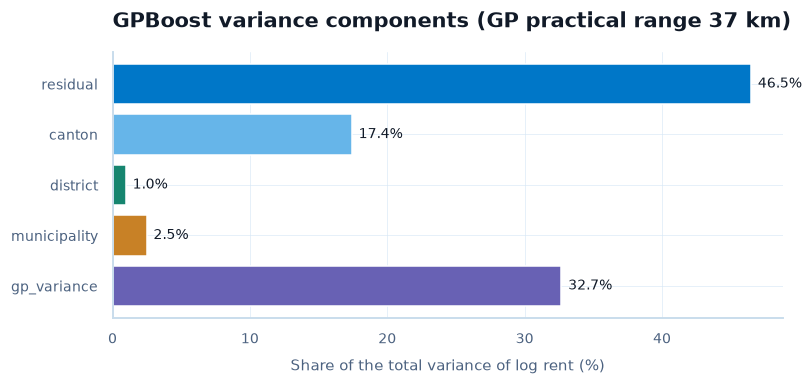

In [47]:
var_comp = gpb_model.variance_components()
with tracker.run("gpboost", stage="tabular+geo", tags={"session": SESSION_ID, "model": "gpboost"},
                 params={"gpboost": {k: v for k, v in asdict(GPB_CFG).items()
                                     if k != "num_boost_round"},
                         "num_boost_round": GPB_ROUNDS, "fit": "two-stage",
                         "features": "F_TAB (+RE +GP)", "cv_folds": len(cv_folds),
                         "data_source": DATA_USED}):
    tracker.log_metrics({"cv_mae": cv_gpb["MAE"], "cv_rmse": cv_gpb["RMSE"], "cv_r2": cv_gpb["R2"],
                         "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["gpboost"]))),
                         "calib_coverage_80_raw": cover80,
                         "fit_time_s": gpb_model.fit_time_s_,
                         **{f"var_{c}": v for c, v in var_comp.set_index("component")["variance"].items()},
                         **test_metrics(pred_test["gpboost"])})  # test: read in section 15
    tracker.log_table(var_comp, "variance_components", index=False)
(paths.results / "gpboost_variance_components.md").write_text(
    to_markdown(var_comp, floatfmt={"variance": ".4g", "share": ".3f"}, index=False) + "\n")
display(var_comp.style.format({"variance": "{:.4g}", "share": "{:.1%}"}, na_rep="–")
        .hide(axis="index"))

shares = var_comp.dropna(subset=["share"]).set_index("component")["share"]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(shares.index, shares.to_numpy() * 100, color=PALETTE[: len(shares)])
for y, s in enumerate(shares.to_numpy()):
    ax.text(s * 100 + 0.5, y, f"{s:.1%}", va="center", fontsize=9)
rng = var_comp.set_index("component")["variance"]
ax.set_xlabel("Share of the total variance of log rent (%)")
ax.set_title(f"GPBoost variance components (GP practical range "
             f"{rng.get('gp_practical_range', np.nan):.0f} km)")
ax.invert_yaxis()
fig.tight_layout()
save_fig(fig, "gpboost_variance_components", paths.figures)
plt.show()

**Interpretation.** The shares answer *where* rent differences live once the flat and the building
are accounted for. A large **canton** share means that a substantial part of the location premium
is regional (tax level, labour market). A large **GP** share with a practical range of a few tens
of kilometres means that rents vary smoothly across municipality borders (commuting belts around
the centres), which the nested intercepts alone could not express. Small **district** and
**municipality** shares do not mean that municipalities do not matter: most of their differences
are already explained by the GP and the canton, and what remains is municipality-specific noise.
The **residual** share is the part that no location model can remove; it is the target of the
text features in RQ1.

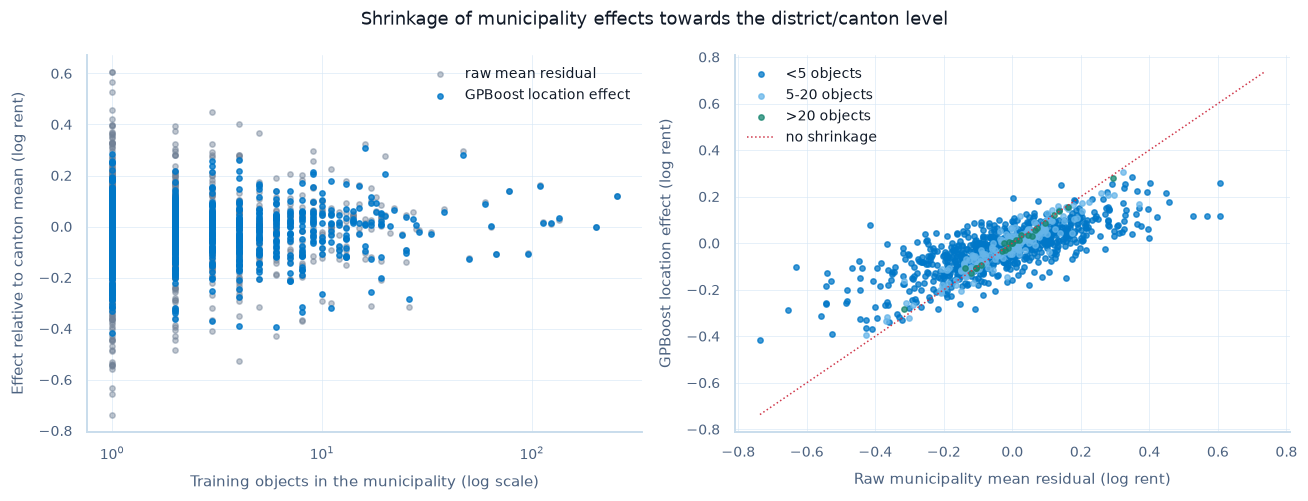

slope of location effect on raw residual per bucket: <5 0.41, 5-20 0.80, >20 0.94


In [48]:
fixed_train = gpb_model.predict_fixed_effects(train_df[F_TAB])
shrink = pd.DataFrame({
    "canton": train_df["re_canton"].to_numpy(), "muni": train_df["re_municipality"].to_numpy(),
    "model": gpb_model.predict(train_df[F_TAB], train_df[GROUP_COLS], train_df[COORDS]) - fixed_train,
    "raw": y_train_log - fixed_train,  # unshrunk: plain mean residual of the tree part
})
shrink[["model", "raw"]] -= shrink.groupby("canton")[["model", "raw"]].transform("mean")
per_muni = shrink.groupby("muni").agg(n=("model", "size"), model=("model", "mean"),
                                      raw=("raw", "mean"))
per_muni["bucket"] = geo.count_bucket(per_muni["n"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(per_muni["n"], per_muni["raw"], s=12, color=COLORS["gray"], alpha=0.45,
                label="raw mean residual")
axes[0].scatter(per_muni["n"], per_muni["model"], s=12, color=COLORS["primary"], alpha=0.8,
                label="GPBoost location effect")
axes[0].set_xscale("log")
axes[0].set_xlabel("Training objects in the municipality (log scale)")
axes[0].set_ylabel("Effect relative to canton mean (log rent)")
axes[0].legend(fontsize=9)
for color, bucket in zip(PALETTE, BUCKETS, strict=False):
    part = per_muni[per_muni["bucket"].eq(bucket)]
    axes[1].scatter(part["raw"], part["model"], s=12, color=color, alpha=0.75,
                    label=f"{bucket} objects")
lim = np.nanmax(np.abs(per_muni[["raw", "model"]].to_numpy()))
axes[1].plot([-lim, lim], [-lim, lim], color=COLORS["reference"], lw=1, ls=":", label="no shrinkage")
axes[1].set_xlabel("Raw municipality mean residual (log rent)")
axes[1].set_ylabel("GPBoost location effect (log rent)")
axes[1].legend(fontsize=9)
fig.suptitle("Shrinkage of municipality effects towards the district/canton level")
fig.tight_layout()
save_fig(fig, "gpboost_shrinkage", paths.figures)
plt.show()
slopes = {b: np.polyfit(p["raw"], p["model"], 1)[0] for b, p in per_muni.groupby("bucket") if len(p) > 2}
print("slope of location effect on raw residual per bucket: "
      + ", ".join(f"{b} {slopes[b]:.2f}" for b in BUCKETS if b in slopes))

**Interpretation.** Each point is a municipality: its mean location effect (random intercepts plus
GP, relative to the canton mean) against the raw mean residual of its training objects. Without
shrinkage the points would lie on the dotted diagonal. The printed slopes quantify the pull: a
slope well below 1 in the `<5` bucket and closer to 1 in the `>20` bucket is the shrinkage RQ2 is
about. A municipality with one or two objects is not trusted on its own; it borrows the level of
its district, its canton and, through the GP, its neighbouring municipalities. The target encoding
of section 13 also shrinks, but with a fixed pseudo-count instead of estimated variances, and
without a spatial neighbourhood across administrative borders.

## 15. RQ2 Decision: GPBoost vs LightGBM-TE

RQ2 asks whether spatial mixed effects reduce the error in sparsely covered municipalities and the
spatial autocorrelation of the residuals. The pre-registered evidence (evaluation plan, section 4)
is, on the frozen test set:

- **H2a:** the paired cluster-bootstrap 95 % CI of `MAE(lgbm_te) − MAE(gpboost)` lies above 0
  (overall), with the Wilcoxon signed-rank test as a rank-based secondary check;
- **H2b:** the same in the `<5` listings-per-municipality bucket (MAE per bucket `<5`, `5–20`,
  `>20` is reported in any case);
- **H2c:** GPBoost has a lower Moran's I of the test log-residuals (k = 8 nearest neighbours,
  permutation test). The permutation test checks each model's I against 0; the difference
  between the two I values is not tested, so H2c is reported descriptively (point estimates).

**Decision rule (coded below).** The evaluation plan (section 5) decides RQ2 first, on the tabular +
geo stage. The RQ2 winner, which carries the text ablation (RQ1) and the
intervals (RQ3), is **GPBoost if H2a holds**, i.e. the primary evidence shows a significantly
lower overall test MAE. Otherwise LightGBM-TE stays the point model: it is the simpler comparator
and already serves the monotone what-if view. H2b and H2c are reported as the answers to the
sparse-area and autocorrelation parts of RQ2 but do not change the winner. The test set is
evaluated here once for both frozen models. Spatial CV (whole municipalities held out) is a
robustness check and not part of the decision.

**Consequence of a test-based rule.** The pre-registered rule picks the point model of record on
the test set. Everything built on `RQ2_WINNER` (the text ablation RQ1 and the intervals RQ3) is
therefore conditional on this rule, and the test MAE of stage S0 in RQ1 is slightly optimistic
when the two models are close (a winner's curse). Model selection *within* RQ1 and RQ3 still uses
only CV and calibration data. This is recorded in the changelog of the evaluation plan.

In [49]:
rq2_segments = {"all": np.ones(len(test_df), dtype=bool)} | {b: bucket_test == b for b in BUCKETS}
rq2_results = [
    paired_bootstrap_mae(y_test[mask], pred_test["lgbm_te"][mask], pred_test["gpboost"][mask],
                         name_a="lgbm_te", name_b="gpboost", n_boot=BUDGET["n_boot"],
                         seed=RANDOM_STATE, groups=groups_test[mask])
    for mask in rq2_segments.values()
]
rq2_by_segment = dict(zip(rq2_segments, rq2_results, strict=True))
rq2_table = comparison_table(rq2_results)
rq2_table.insert(0, "segment", list(rq2_segments))
# the decision reads the CI of the overall row; Holm across segments is not part of the plan
rq2_table = rq2_table.drop(columns=["comparison", "name_a", "name_b", "p_holm", "reject"])
p_fmt = {"p_bootstrap": ".3g", "p_wilcoxon": ".3g", "rel_diff_pct": ".2f"}
(paths.results / "rq2_comparison.md").write_text(
    to_markdown(rq2_table, floatfmt=p_fmt, index=False) + "\n")
(paths.results / "rq2_comparison.tex").write_text(to_latex(
    rq2_table, "RQ2: paired cluster bootstrap of MAE(LightGBM-TE) $-$ MAE(GPBoost) on the test set",
    "tab:rq2_comparison", floatfmt=p_fmt, index=False) + "\n")
print(f"paired cluster bootstrap ({BUDGET['n_boot']} resamples of objects); diff > 0: GPBoost better")
display(rq2_table.style.format({"mae_a": "{:.1f}", "mae_b": "{:.1f}", "diff": "{:+.1f}",
                                "ci_low": "{:+.1f}", "ci_high": "{:+.1f}", "p_bootstrap": "{:.3g}",
                                "p_wilcoxon": "{:.3g}", "rel_diff_pct": "{:+.2f}"})
        .hide(axis="index"))

paired cluster bootstrap (2000 resamples of objects); diff > 0: GPBoost better


segment,mae_a,mae_b,diff,ci_low,ci_high,p_bootstrap,p_wilcoxon,n,rel_diff_pct
all,260.7,269.4,-8.7,-15.0,-2.2,0.01,0.0155,1625,-3.34
<5,260.4,278.8,-18.5,-29.3,-7.5,0.0005,0.00244,499,-7.09
5-20,235.7,235.9,-0.2,-9.1,+8.7,0.974,0.545,577,-0.07
>20,287.1,295.9,-8.8,-22.6,+4.8,0.194,0.511,549,-3.06


segment,all,<5,5-20,>20
model,,,,
naive,354.9,376.4,314.2,378.0
dspro1_knn,270.7,283.7,241.3,289.8
lgbm_te,260.7,260.4,235.7,287.1
gpboost,269.4,278.8,235.9,295.9


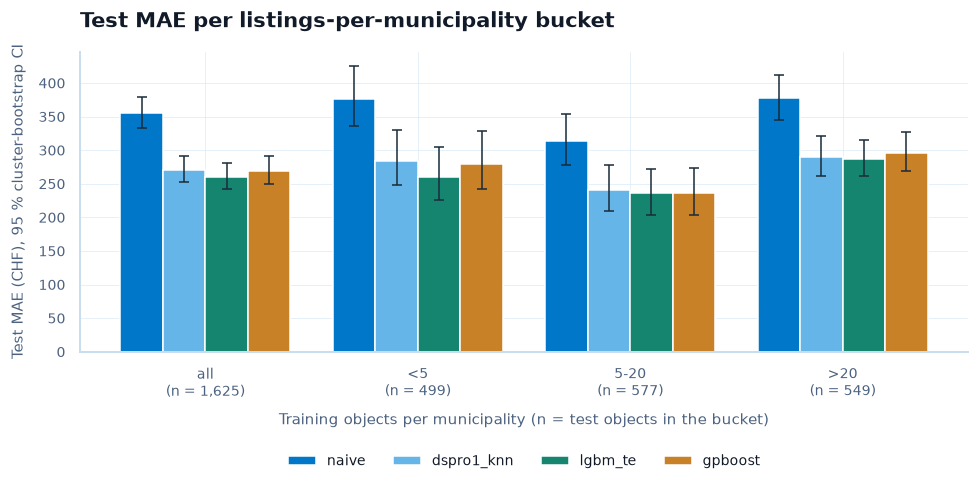

mean bias per bucket (CHF, prediction − truth):


muni_bucket,<5,5-20,>20
naive,66.0,29.0,16.0
dspro1_knn,-44.0,-11.0,-44.0
lgbm_te,-53.0,-8.0,-37.0
gpboost,-68.0,-28.0,-58.0


In [50]:
RQ2_MODELS = ["naive", "dspro1_knn", "lgbm_te", "gpboost"]
ci_rows = []
for name in RQ2_MODELS:
    for seg, mask in rq2_segments.items():
        point, lo, hi = bootstrap_ci(y_test[mask], pred_test[name][mask], "MAE",
                                     n_boot=BUDGET["n_boot"], groups=groups_test[mask])
        ci_rows.append((name, seg, int(mask.sum()), point, lo, hi))
bucket_mae = pd.DataFrame(ci_rows, columns=["model", "segment", "n", "MAE", "ci_low", "ci_high"])
bias = {name: segment_metrics(y_test, pred_test[name], test_df["muni_bucket"])["bias"]
        for name in RQ2_MODELS}
display(bucket_mae.pivot(index="model", columns="segment", values="MAE")
        .loc[RQ2_MODELS, list(rq2_segments)].round(1))

fig, ax = plt.subplots(figsize=(9, 4.8))
width = 0.8 / len(RQ2_MODELS)
for i, (color, name) in enumerate(zip(PALETTE, RQ2_MODELS, strict=False)):
    part = bucket_mae[bucket_mae["model"].eq(name)].set_index("segment").loc[list(rq2_segments)]
    x = np.arange(len(part)) + (i - (len(RQ2_MODELS) - 1) / 2) * width
    ax.bar(x, part["MAE"], width, color=color, label=name,
           yerr=[part["MAE"] - part["ci_low"], part["ci_high"] - part["MAE"]], capsize=3,
           error_kw={"lw": 1, "ecolor": COLORS["neutral"]})
labels = [f"{s}\n(n = {int(rq2_segments[s].sum()):,})" for s in rq2_segments]
ax.set_xticks(np.arange(len(rq2_segments)), labels)
ax.set_xlabel("Training objects per municipality (n = test objects in the bucket)")
ax.set_ylabel("Test MAE (CHF), 95 % cluster-bootstrap CI")
ax.yaxis.set_major_formatter(chf_formatter())
ax.set_title("Test MAE per listings-per-municipality bucket")
ax.legend(ncols=len(RQ2_MODELS), fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.3),
          frameon=False)
fig.tight_layout()
save_fig(fig, "rq2_mae_by_bucket", paths.figures)
plt.show()
print("mean bias per bucket (CHF, prediction − truth):")
display(pd.DataFrame(bias).T.round(0))

In [51]:
coords_test = test_df[COORDS].to_numpy(dtype=float)
t0 = time.perf_counter()
moran = {name: morans_i(np.log(y_test) - np.log(pred_test[name]), coords_test, k=8,
                        permutations=BUDGET["permutations"], seed=RANDOM_STATE)
         for name in RQ2_MODELS}
moran_table = pd.DataFrame({name: {"moran_I": r.I, "z": r.z, "p_value": r.p_value}
                            for name, r in moran.items()}).T
print(f"Moran's I of test log-residuals (k = 8, {BUDGET['permutations']} permutations, "
      f"{time.perf_counter() - t0:.1f}s); E[I] = {moran['gpboost'].expected:.4f}")
display(moran_table.style.format({"moran_I": "{:.4f}", "z": "{:.1f}", "p_value": "{:.3g}"}))

t0 = time.perf_counter()
oof_sp_lgbm = np.exp(fit_predict_cv(lambda: te_lgbm(lgb_params), train_df[TE_INPUT], y_train_log,
                                    spatial_folds))
oof_sp_gpb = np.full(len(train_df), np.nan)
for tr, va in spatial_folds:
    oof_sp_gpb[va] = gpb_fit_predict(tr, va)
spatial_cv = {"lgbm_te": float(np.mean(np.abs(y_train - oof_sp_lgbm))),
              "gpboost": float(np.mean(np.abs(y_train - np.exp(oof_sp_gpb))))}
print(f"spatial CV (whole municipalities held out, {len(spatial_folds)} folds, "
      f"{time.perf_counter() - t0:.0f}s): " + ", ".join(f"{k} {v:,.1f} CHF" for k, v in spatial_cv.items()))

Moran's I of test log-residuals (k = 8, 999 permutations, 0.1s); E[I] = -0.0006


,moran_I,z,p_value
naive,0.0462,4.1,0.001
dspro1_knn,0.0370,3.2,0.004
lgbm_te,0.0247,2.2,0.025
gpboost,0.0171,1.5,0.133


spatial CV (whole municipalities held out, 5 folds, 35s): lgbm_te 300.7 CHF, gpboost 298.6 CHF


In [52]:
overall, sparse = rq2_by_segment["all"], rq2_by_segment["<5"]
decision = pd.DataFrame([
    ("H2a", "overall: 95 % CI of MAE(lgbm_te) − MAE(gpboost) > 0",
     f"{overall.diff:+.1f} CHF [{overall.ci_low:+.1f}, {overall.ci_high:+.1f}], "
     f"Wilcoxon p = {overall.p_wilcoxon:.3g}", overall.ci_low > 0),
    ("H2b", "<5 bucket: 95 % CI > 0",
     f"{sparse.diff:+.1f} CHF [{sparse.ci_low:+.1f}, {sparse.ci_high:+.1f}], "
     f"Wilcoxon p = {sparse.p_wilcoxon:.3g}", sparse.ci_low > 0),
    ("H2c", "Moran's I(gpboost) < Moran's I(lgbm_te), point estimates (difference not tested)",
     f"{moran['gpboost'].I:.4f} (p = {moran['gpboost'].p_value:.3g}) vs "
     f"{moran['lgbm_te'].I:.4f} (p = {moran['lgbm_te'].p_value:.3g}); p: I vs 0",
     moran["gpboost"].I < moran["lgbm_te"].I),
], columns=["hypothesis", "criterion", "estimate", "supported"])
decision["evidence"] = ["paired bootstrap CI", "paired bootstrap CI", "descriptive"]
RQ2_WINNER = "gpboost" if overall.ci_low > 0 else "lgbm_te"  # pre-registered rule, see above
display(decision.style.hide(axis="index"))
print(f"RQ2_WINNER = {RQ2_WINNER!r}")
print(f"tuning reference, CV MAE: untuned LightGBM F_TAB + coordinates (section 11) "
      f"{abs_err_geo.mean():,.1f} CHF | GPBoost {cv_mae('gpboost'):,.1f} CHF | tuned "
      f"LightGBM-TE {cv_mae('lgbm_te'):,.1f} CHF")

rq2_models = pd.DataFrame({name: {"cv_mae": cv_mae(name), **test_metrics(pred_test[name]),
                                  "moran_I": moran[name].I} for name in RQ2_MODELS}).T
rq2_models["spatial_cv_mae"] = pd.Series(spatial_cv)
(paths.results / "rq2_models.md").write_text(to_markdown(
    rq2_models, floatfmt={"test_r2": ".3f", "moran_I": ".4f"}) + "\n")
display(rq2_models.style.format("{:.1f}", na_rep="–")
        .format({"test_r2": "{:.3f}", "moran_I": "{:.4f}"}))
with tracker.run("rq2_decision", stage="rq2", tags={"session": SESSION_ID},
                 params={"winner": RQ2_WINNER, "rule": "gpboost iff overall CI(diff) > 0",
                         "n_boot": BUDGET["n_boot"], "permutations": BUDGET["permutations"]}):
    for seg, res in rq2_by_segment.items():
        key = "all" if seg == "all" else BUCKET_KEYS[seg]
        tracker.log_metrics({f"diff_{key}": res.diff, f"ci_low_{key}": res.ci_low,
                             f"ci_high_{key}": res.ci_high, f"p_boot_{key}": res.p_bootstrap,
                             f"p_wilcoxon_{key}": res.p_wilcoxon})
    tracker.log_metrics({f"moran_{k}": r.I for k, r in moran.items()}
                        | {f"spatial_cv_mae_{k}": v for k, v in spatial_cv.items()})
    tracker.log_table(rq2_table, "rq2_comparison", index=False)
    tracker.log_table(rq2_models, "rq2_models")

hypothesis,criterion,estimate,supported,evidence
H2a,overall: 95 % CI of MAE(lgbm_te) − MAE(gpboost) > 0,"-8.7 CHF [-15.0, -2.2], Wilcoxon p = 0.0155",False,paired bootstrap CI
H2b,<5 bucket: 95 % CI > 0,"-18.5 CHF [-29.3, -7.5], Wilcoxon p = 0.00244",False,paired bootstrap CI
H2c,"Moran's I(gpboost) < Moran's I(lgbm_te), point estimates (difference not tested)",0.0171 (p = 0.133) vs 0.0247 (p = 0.025); p: I vs 0,True,descriptive


RQ2_WINNER = 'lgbm_te'
tuning reference, CV MAE: untuned LightGBM F_TAB + coordinates (section 11) 274.1 CHF | GPBoost 276.9 CHF | tuned LightGBM-TE 265.1 CHF


,cv_mae,test_mae,test_rmse,test_medae,test_mape,test_r2,test_mae_lt5,test_mae_5_20,test_mae_gt20,moran_I,spatial_cv_mae
naive,352.161782,354.852886,580.049187,237.500000,19.752270,0.618,376.433308,314.188333,377.976413,0.0462,nan
dspro1_knn,273.139081,270.707336,503.323553,184.708671,14.781495,0.712,283.665581,241.303900,289.832325,0.0370,nan
lgbm_te,265.123428,260.657063,483.118605,177.980891,14.245061,0.735,260.387228,235.702016,287.130123,0.0247,300.721136
gpboost,276.938408,269.351197,503.214305,182.247689,14.489439,0.712,278.843876,235.857852,295.924626,0.0171,298.584850


**Interpretation.** Read the decision table from top to bottom.

- **H2a** is the primary result. If the CI lies above 0, GPBoost is the better point model and the
  σ-normalised conformal score is used in RQ3. If the CI contains 0, the honest statement is "no
  detectable difference at this test-set size" (compare the MDE of section 11), not "the models are
  equal". If it lies below 0, the conventional encoding is better on this data.
- **H2b** answers the sparse-area part of RQ2. The `<5` bucket has only a few hundred test objects,
  so its CI is wide. A positive difference there with an overall tie would still be a useful
  finding for the app: GPBoost would then be the safer choice exactly where listings are rare.
- **H2c.** A residual Moran's I close to its expectation (and a large permutation p-value) means
  that the model has absorbed the spatial structure. If the naive baseline shows strong positive
  autocorrelation and both learned models are close to 0, location is captured well by either
  approach, and the difference between them is a matter of accuracy, not of missed spatial
  structure. `supported` for H2c only compares the two point estimates: each p-value tests one
  model's I against 0, not the difference, so "GPBoost lower" is descriptive, not a significant
  reduction.
- **Spatial CV** simulates municipalities without any training object. If GPBoost's advantage
  grows there, its hierarchy and GP transfer better to unseen places; if the ranking flips, the
  result on the random test split should not be generalised to new regions. Like the grouped CV,
  the spatial CV of GPBoost reuses the covariance parameters of the full training set.

- **Tuning budget.** As fixed in the evaluation plan (section 7), LightGBM-TE was tuned with Optuna,
  whereas GPBoost only had its number of boosting rounds chosen by early stopping at fixed tree
  parameters. The printed tuning reference puts this into perspective: if GPBoost is about as good
  as the *untuned* LightGBM of section 11 and LightGBM-TE wins, part of the gap is tuning rather
  than the location model, and tuning the GPBoost trees is the obvious next step before the
  question is closed.

Whatever the outcome, the kNN rent features are not needed any more: both models reach the
location signal without an in-sample target aggregate.

## 16. Deep-Learning Component: Fused Network with Entity Embeddings

The proposal adds a neural model as an optional, time-boxed extension. `FusedRentRegressor`
combines three branches:

- **entity embeddings** for canton, district and municipality: each unit gets a learned vector,
  and weight decay pulls rarely seen municipalities towards zero, a neural analogue of the random
  intercepts in GPBoost (units with fewer than 2 training objects share the "unknown" vector);
- a **numeric MLP** on `F_TAB` plus the plain and rotated coordinates (skewed counts log1p-scaled,
  missing values median-imputed with indicator columns);
- a **text branch** on 32-dimensional sentence embeddings of the anonymised description, only
  when descriptions are available (`HAS_TEXT`).

Early stopping uses the same grouped validation fold as GPBoost (`cv_folds[0]`), never calibration
or test data, so `nn_model` is trained on the other (K−1)/K of the training objects. It is not
refitted on all of them: the stopping epoch found on the smaller set does not transfer reliably to
a larger one, and the extension does not justify a second tuning loop. The network is not monotone in the living area, so it cannot replace the constrained
LightGBM in the what-if view. The comparison with the RQ2 winner below is **exploratory**: it was
not pre-registered, so it informs future work but does not change any decision.

In [53]:
NN_NUM = F_GEO_LGBM
NN_LOG1P = ("area", "population", "land_area", "apartments", "land_area_per_apartment", "oev",
            "muni_density", "muni_population")
NN_CFG = FusionConfig(epochs=BUDGET["nn_epochs"], device=DEVICE, log1p_cols=NN_LOG1P)
TEXT_EMB: dict[str, np.ndarray] | None = None  # reduced sentence embeddings per split
text_note = "no descriptions (HAS_TEXT is False)"
if HAS_TEXT and SentenceEmbedder.is_available():
    try:
        embedder = SentenceEmbedder(cache_dir=paths.cache / "embeddings", device=DEVICE)
        texts = {s: f["description_anon"].astype("string").fillna("")
                 for s, f in (("train", train_df), ("calib", calib_df), ("test", test_df))}
        raw_emb = {s: embedder.encode(t.tolist()) for s, t in texts.items()}
        has_desc = {s: (t.str.len() >= 50).to_numpy() for s, t in texts.items()}
        # PCA fitted on training rows with a description only; NaN row = "no description"
        _, reduced = reduce_embeddings(raw_emb["train"][has_desc["train"]],
                                       [raw_emb[s] for s in texts], n_components=32)
        TEXT_EMB = dict(zip(texts, reduced, strict=True))
        for split, emb in TEXT_EMB.items():
            emb[~has_desc[split]] = np.nan
        text_note = "on (32-dim sentence embeddings)"
    except (OSError, RuntimeError, ValueError) as exc:  # e.g. model not downloadable offline
        text_note = f"off, embedding failed: {exc}"
elif HAS_TEXT:
    text_note = "off, sentence-transformers not installed"
print(f"text branch: {text_note} | device={DEVICE} | max epochs {NN_CFG.epochs}")

text branch: no descriptions (HAS_TEXT is False) | device=cuda | max epochs 300


In [54]:
def text_of(split: str, pos: np.ndarray | None = None) -> np.ndarray | None:
    if TEXT_EMB is None:
        return None
    return TEXT_EMB[split] if pos is None else TEXT_EMB[split][pos]


def fit_fused(train_pos: np.ndarray, val_pos: np.ndarray) -> FusedRentRegressor:
    # Fit on train_df rows train_pos, early stopping on the grouped split val_pos (CHF MAE).
    a, b = train_df.iloc[train_pos], train_df.iloc[val_pos]
    eval_set = (b[NN_NUM], b[GROUP_COLS], b["log_price"])
    if TEXT_EMB is not None:
        eval_set += (text_of("train", val_pos),)
    return FusedRentRegressor(NN_CFG).fit(a[NN_NUM], a[GROUP_COLS], a["log_price"],
                                          X_text=text_of("train", train_pos), eval_set=eval_set)


def predict_fused(model: FusedRentRegressor, frame: pd.DataFrame, text) -> np.ndarray:
    return np.exp(model.predict(frame[NN_NUM], frame[GROUP_COLS], text))

nn_model: 37 epochs in 6s on cuda, best epoch 17 (validation MAE 296.6 CHF); CV MAE 295.9 CHF (5 folds in 18s)


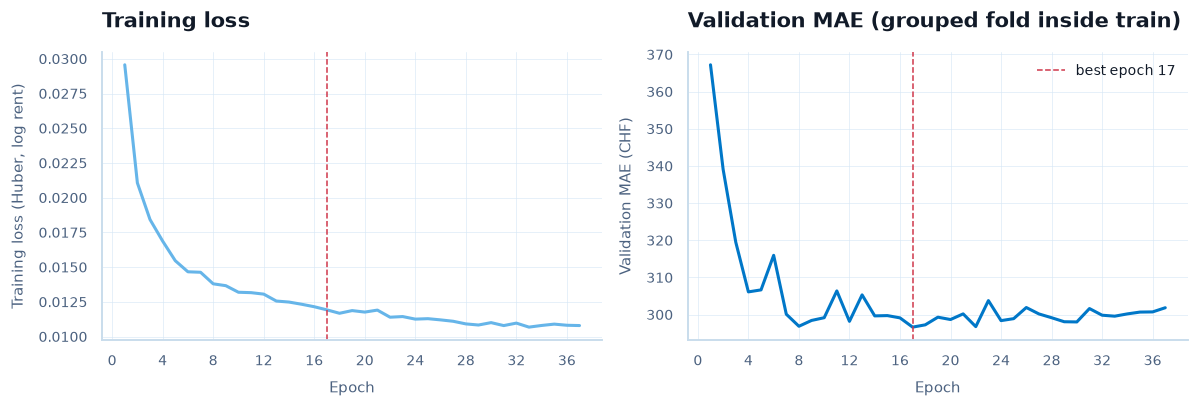

In [55]:
t0 = time.perf_counter()
nn_model = fit_fused(*cv_folds[0])
fit_s = time.perf_counter() - t0
pred_calib["fused_nn"] = predict_fused(nn_model, calib_df, text_of("calib"))
pred_test["fused_nn"] = predict_fused(nn_model, test_df, text_of("test"))

t0 = time.perf_counter()  # out-of-fold predictions: each outer fold gets its own inner grouped split
oof_nn = np.full(len(train_df), np.nan)
for tr, va in cv_folds:
    inner_tr, inner_va = grouped_cv_folds(train_df.iloc[tr], n_splits=len(cv_folds),
                                          strata=strata)[0]
    net = fit_fused(tr[inner_tr], tr[inner_va])
    oof_nn[va] = predict_fused(net, train_df.iloc[va], text_of("train", va))
cv_oof["fused_nn"] = oof_nn
print(f"nn_model: {len(nn_model.history_)} epochs in {fit_s:.0f}s on {nn_model.device_}, best "
      f"epoch {nn_model.best_epoch_} (validation MAE {nn_model.best_val_mae_:,.1f} CHF); "
      f"CV MAE {cv_mae('fused_nn'):,.1f} CHF ({len(cv_folds)} folds in {time.perf_counter() - t0:.0f}s)")

hist = nn_model.history_
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
axes[0].plot(hist["epoch"], hist["train_loss"], color=COLORS["secondary"])
axes[0].set_ylabel("Training loss (Huber, log rent)")
axes[0].set_title("Training loss")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].plot(hist["epoch"], hist["val_mae"], color=COLORS["primary"])
axes[1].set_ylabel("Validation MAE (CHF)")
axes[1].yaxis.set_major_formatter(chf_formatter())
axes[1].set_title("Validation MAE (grouped fold inside train)")
for ax in axes:
    ax.axvline(nn_model.best_epoch_, color=COLORS["reference"], ls="--", lw=1,
               label=f"best epoch {nn_model.best_epoch_}")
    ax.set_xlabel("Epoch")
axes[1].legend(loc="upper right")
fig.tight_layout()
save_fig(fig, "fused_nn_training_curve", paths.figures)
plt.show()

In [56]:
nn_test = test_metrics(pred_test["fused_nn"])
nn_vs_winner = paired_bootstrap_mae(y_test, pred_test[RQ2_WINNER], pred_test["fused_nn"],
                                    name_a=RQ2_WINNER, name_b="fused_nn", n_boot=BUDGET["n_boot"],
                                    seed=RANDOM_STATE, groups=groups_test)
with tracker.run("fused_nn", stage="fused", tags={"session": SESSION_ID, "model": "fused_nn",
                                                  "pre_registered": "false"},
                 params={"fusion": {k: v for k, v in asdict(NN_CFG).items() if k != "log1p_cols"},
                         "text_branch": TEXT_EMB is not None, "numeric": "F_GEO_LGBM",
                         "categorical": "+".join(GROUP_COLS), "data_source": DATA_USED}):
    for epoch, val in zip(hist["epoch"], hist["val_mae"], strict=True):
        tracker.log_metrics({"val_mae": float(val)}, step=int(epoch))
    tracker.log_metrics({"cv_mae": cv_mae("fused_nn"), "best_epoch": nn_model.best_epoch_,
                         "val_mae": nn_model.best_val_mae_,
                         "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["fused_nn"]))),
                         **nn_test, "diff_vs_winner": nn_vs_winner.diff,
                         "p_boot_vs_winner": nn_vs_winner.p_bootstrap})

res = nn_vs_winner
print(f"fused_nn test MAE {nn_test['test_mae']:,.1f} CHF (R² {nn_test['test_r2']:.3f}) vs "
      f"{RQ2_WINNER} {res.mae_a:,.1f} CHF")
print(f"exploratory paired bootstrap: MAE({RQ2_WINNER}) − MAE(fused_nn) = {res.diff:+.1f} CHF, "
      f"95 % CI [{res.ci_low:+.1f}, {res.ci_high:+.1f}], p = {res.p_bootstrap:.3g}, "
      f"Wilcoxon p = {res.p_wilcoxon:.3g}")
verdict = ("better than" if res.ci_low > 0 else "worse than" if res.ci_high < 0
           else "not distinguishable from")
print(f"-> the fused network is {verdict} the RQ2 winner on this test set (not pre-registered)")

fused_nn test MAE 287.9 CHF (R² 0.685) vs lgbm_te 260.7 CHF
exploratory paired bootstrap: MAE(lgbm_te) − MAE(fused_nn) = -27.2 CHF, 95 % CI [-37.5, -17.1], p = 0.0005, Wilcoxon p = 7.01e-06
-> the fused network is worse than the RQ2 winner on this test set (not pre-registered)


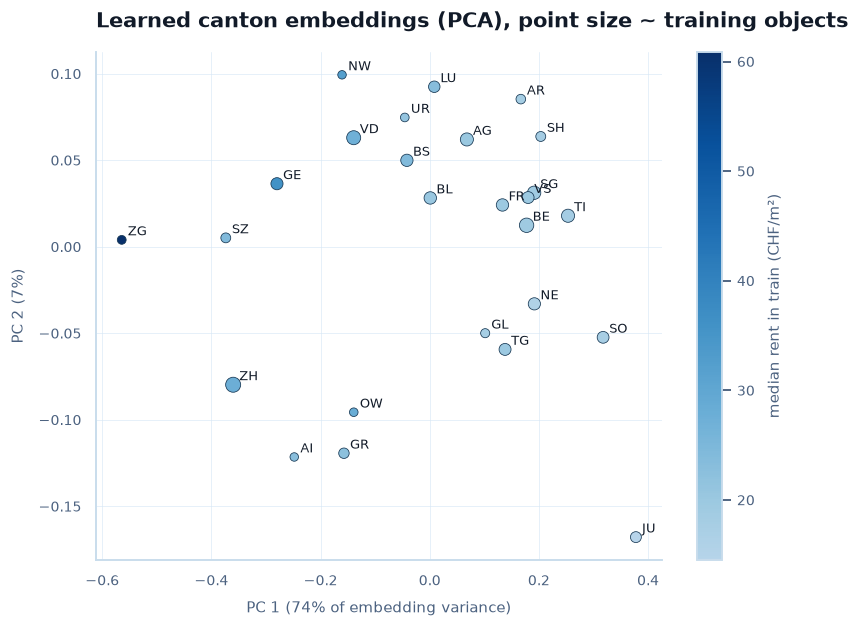

26 cantons with an own embedding; Spearman ρ with CHF/m²: PC1 -0.91, PC2 +0.15
prediction dictionaries: {'pred_test': ['dspro1_knn', 'dspro1_knn_oof', 'fused_nn', 'gpboost', 'lgbm_tab', 'lgbm_te', 'naive'], 'pred_calib': ['dspro1_knn', 'dspro1_knn_oof', 'fused_nn', 'gpboost', 'lgbm_tab', 'lgbm_te', 'naive'], 'cv_oof': ['dspro1_knn', 'dspro1_knn_oof', 'fused_nn', 'gpboost', 'lgbm_tab', 'lgbm_te', 'naive']}


In [57]:
emb_canton = nn_model.embedding_table("re_canton").drop(index=UNKNOWN_LABEL, errors="ignore")
emb_cols = [c for c in emb_canton.columns if c.startswith("emb_")]
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(emb_canton[emb_cols])
pc = pd.DataFrame(pca.transform(emb_canton[emb_cols]), index=emb_canton.index,
                  columns=["pc1", "pc2"])
rate = (train_df["price"] / train_df["area"]).groupby(train_df["re_canton"]).median()
pc["chf_per_m2"] = rate.reindex(pc.index)
rho = pc[["pc1", "pc2"]].corrwith(pc["chf_per_m2"], method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 5.8))
blues = ListedColormap(plt.get_cmap("Blues")(np.linspace(0.3, 1.0, 256)))  # no near-white
sc = ax.scatter(pc["pc1"], pc["pc2"], c=pc["chf_per_m2"], cmap=blues,
                s=25 + 3 * np.sqrt(emb_canton["n_train"]), edgecolor=COLORS["dark"], lw=0.5)
for label, row in pc.iterrows():
    ax.annotate(label, (row["pc1"], row["pc2"]), xytext=(4, 3), textcoords="offset points",
                fontsize=8.5)
fig.colorbar(sc, ax=ax, label="median rent in train (CHF/m²)")
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.0%} of embedding variance)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Learned canton embeddings (PCA), point size ~ training objects")
fig.tight_layout()
save_fig(fig, "fused_nn_canton_embeddings", paths.figures)
plt.show()
print(f"{len(pc)} cantons with an own embedding; Spearman ρ with CHF/m²: "
      f"PC1 {rho['pc1']:+.2f}, PC2 {rho['pc2']:+.2f}")
print("prediction dictionaries:", {k: sorted(v) for k, v in
                                   [("pred_test", pred_test), ("pred_calib", pred_calib),
                                    ("cv_oof", cv_oof)]})

**Interpretation.** The training curve shows whether early stopping worked: the validation MAE
should reach its minimum before the last epoch and flatten or rise afterwards. If the best epoch
equals the maximum number of epochs, the budget (`nn_epochs`) was too small and the network is
under-trained, which is expected in the fast smoke run. The exploratory comparison places the
network relative to the RQ2 winner. A network that is not better is still informative: with only a
few thousand objects and no text, gradient boosting on tabular data is hard to beat, in line with
the literature. The text branch is the real reason to keep the network, and it can only be judged
on the database data with descriptions.

The canton embeddings show *what* the network learned about location without being told. If a
principal component correlates strongly with the median rent per m² (|ρ| well above 0.5), the
network has rebuilt the rent level of the cantons from the data. Cantons with similar markets (for
example the expensive lake cantons, or the rural cantons of central and eastern Switzerland) then
sit close together, whatever their language. The embeddings are used only for this inspection.
They are never fed to another model: they are fitted on their own training rows, and the vectors of
different networks are not comparable.

---

## Phase 4 — Listing text and calibrated uncertainty

## 17. RQ1 Text Ablation: Does the Description Improve the Winning Model?

The listing description is the one source that DSPRO1 stored but never used. It mentions what the
structured fields miss: a lake view, a recent renovation, a parking space, a furnished flat. RQ1
asks whether this text lowers the error of the point model **beyond the tabular and location
features**. Following the order of decisions in the evaluation plan, the ablation runs only on the
RQ2 winner (`RQ2_WINNER`, section 15). Each stage adds one kind of text information:

| Stage | Adds (cumulative) | Fitted on |
|---|---|---|
| S0 tabular + geo | nothing: the RQ2 winner exactly as frozen in section 15 | – |
| S1 + keywords + TF-IDF | keyword flags (section 7), 50-dimensional TF-IDF/SVD | training texts |
| S2 + sentence embeddings | 32 PCA components of multilingual sentence embeddings | training texts |
| S3 + attributes | attributes of section 8 (floor, lift, view, parking, …) | – (`ATTR_SOURCE`) |
| S4 fused network | the network of section 16, if it had a text branch (exploratory) | – |

The TF-IDF block combines word 1–2-grams and character 3–5-grams of the anonymised description. S2
runs only if `sentence-transformers` is installed and the model can be loaded. The S3 attributes
come from the rules, or from the LLM if its cache covered every description (`ATTR_SOURCE`,
section 8); the pre-registered plan names LLM extraction, and the deviation is in its changelog.

**Protocol.**

- The stages are cumulative and keep the winner's settings: `lgb_params` for LightGBM-TE, or the
  boosting rounds and covariance parameters of section 14 for GPBoost. Nothing is re-tuned per
  stage, so the text stages get no extra tuning budget.
- TF-IDF/SVD and the embedding PCA see only training descriptions and never a rent. The CV folds
  share this vocabulary but not the target: target encodings are refitted inside every fold
  (LightGBM-TE), and GPBoost reuses the covariance parameters of section 14, the same documented
  approximation as in its CV there.
- A description shorter than 50 characters counts as "no text": its TF-IDF and embedding features
  are missing (NaN, which both learners handle natively) and its keyword flags are 0.
- **Selection** uses the grouped CV MAE on the folds of sections 13–14. The **test** set is used
  once: a paired cluster bootstrap of `MAE(previous stage) − MAE(stage)` per stage (positive = the
  stage helps), with a Holm correction across the pre-registered stages S1–S3. The exploratory S4
  row is not part of that family.

Without descriptions (CSV fallback) the section prints a notice and sets `rq1_table = None`. The
code path is the same one that runs on the database data.

In [58]:
from matplotlib.colors import TwoSlopeNorm, to_rgba
from matplotlib.ticker import PercentFormatter
from scipy import stats
from sklearn.pipeline import Pipeline

from rentml.conformal import (
    CQRCalibrator,
    MondrianCQR,
    NormalizedConformal,
    assign_band,
    constant_band_for_coverage,
    coverage_report,
    fit_band_cutpoints,
    interval_score,
)
from rentml.evaluation import holm_correction, paired_bootstrap_mae
from rentml.features import monotone_vector
from rentml.plotting import to_latex
from rentml.quantile import (
    MonotoneQuantileLGBM,
    crossing_rate,
    quantile_calibration_table,
    quantile_columns,
)
from rentml.spatial import GPBoostRegressor
from rentml.text import SentenceEmbedder, TfidfSvd, reduce_embeddings

y_train_log, y_train = train_df["log_price"].to_numpy(), train_df["price"].to_numpy()
y_calib, y_test = calib_df["price"].to_numpy(), test_df["price"].to_numpy()
y_calib_log, y_test_log = np.log(y_calib), np.log(y_test)
groups_test = test_df["object_id"].to_numpy()
bucket_test = test_df["muni_bucket"].astype(str).to_numpy()

In [59]:
RQ1_SPLITS = {"train": train_df, "calib": calib_df, "test": test_df}
RQ1_LABELS = {"S0": "tabular + geo (RQ2 winner)", "S1": "+ keywords + TF-IDF-SVD",
              "S2": "+ sentence embeddings", "S3": f"+ structured attributes ({ATTR_SOURCE})",
              "S4": "fused network with text (exploratory)"}
RQ1_SVD_DIM, RQ1_EMB_DIM, MIN_TEXT_CHARS = 50, 32, 50
RQ1_BUCKETS = {"<5": "lt5", "5-20": "5_20", ">20": "gt20"}
rq1_extra = {split: frame[[]].copy() for split, frame in RQ1_SPLITS.items()}  # text features
RQ1_STAGES: dict[str, list[str]] = {}  # stage -> cumulative extra feature columns
rq1_table = None


def stage_metrics(pred: np.ndarray) -> dict[str, float]:
    # Hold-out metrics in CHF with the tracking names of section 13 (incl. MAE per bucket).
    out = {f"test_{k.lower()}": v for k, v in regression_metrics(y_test, pred).items()}
    for bucket, key in RQ1_BUCKETS.items():
        mask = bucket_test == bucket
        if mask.any():
            out[f"test_mae_{key}"] = float(np.mean(np.abs(y_test[mask] - pred[mask])))
    return out


if not HAS_TEXT:
    print(f"RQ1 skipped: no listing descriptions in this run (data source {DATA_USED!r}, "
          f"HAS_TEXT={HAS_TEXT}), so rq1_table = None. Sections 18-19 do not use text.")
else:
    t0 = time.time()
    texts = {s: f["description_anon"].astype("string") for s, f in RQ1_SPLITS.items()}
    no_text = {s: t.fillna("").str.len().lt(MIN_TEXT_CHARS).to_numpy() for s, t in texts.items()}
    tfidf = TfidfSvd(n_components=RQ1_SVD_DIM, random_state=RANDOM_STATE)
    tfidf.fit(texts["train"][~no_text["train"]])  # training descriptions only
    for split, frame in RQ1_SPLITS.items():
        svd = tfidf.transform(texts[split])
        svd.loc[no_text[split]] = np.nan
        rq1_extra[split] = frame[F_TEXT_KW].join(svd)
        rq1_extra[split].loc[no_text[split], F_TEXT_KW] = 0  # short text: no keyword evidence
    RQ1_STAGES["S0"] = []
    RQ1_STAGES["S1"] = F_TEXT_KW + list(tfidf.get_feature_names_out())
    print(f"S1: {len(F_TEXT_KW)} keyword flags + {tfidf.n_components_} SVD components, fitted on "
          f"{(~no_text['train']).sum():,} training descriptions ({no_text['train'].mean():.1%} of "
          f"the training objects have no text), {time.time() - t0:.0f}s")

RQ1 skipped: no listing descriptions in this run (data source 'csv', HAS_TEXT=False), so rq1_table = None. Sections 18-19 do not use text.


In [60]:
if HAS_TEXT and SentenceEmbedder.is_available():
    t0 = time.time()
    try:
        embedder = SentenceEmbedder(cache_dir=paths.cache / "embeddings", device=DEVICE)
        raw_emb = {s: embedder.encode(t.fillna("").tolist()) for s, t in texts.items()}
    except (OSError, RuntimeError, ImportError, ValueError) as exc:  # e.g. model not downloadable
        print(f"S2 skipped: sentence embeddings failed ({type(exc).__name__}: {exc})")
    else:
        _, reduced = reduce_embeddings(raw_emb["train"][~no_text["train"]],
                                       [raw_emb[s] for s in RQ1_SPLITS],
                                       n_components=RQ1_EMB_DIM, seed=RANDOM_STATE)
        emb_cols = [f"emb_{i}" for i in range(reduced[0].shape[1])]
        for (split, frame), red in zip(RQ1_SPLITS.items(), reduced, strict=True):
            emb = pd.DataFrame(red, index=frame.index, columns=emb_cols)
            emb.loc[no_text[split]] = np.nan
            rq1_extra[split] = rq1_extra[split].join(emb)
        RQ1_STAGES["S2"] = RQ1_STAGES["S1"] + emb_cols
        print(f"S2: {len(emb_cols)} PCA components of {raw_emb['train'].shape[1]}-dimensional "
              f"sentence embeddings (PCA on training texts), {time.time() - t0:.0f}s")
elif HAS_TEXT:
    print("S2 skipped: sentence-transformers is not installed (optional extra)")

if HAS_TEXT and F_ATTR:
    for split, frame in RQ1_SPLITS.items():
        attrs = frame[F_ATTR].copy()
        for col in attrs.select_dtypes("category").columns:  # view, parking -> integer codes
            attrs[col] = attrs[col].cat.codes.where(attrs[col].notna()).astype(float)
        rq1_extra[split] = rq1_extra[split].join(attrs.astype(float))
    RQ1_STAGES["S3"] = RQ1_STAGES[list(RQ1_STAGES)[-1]] + F_ATTR
elif HAS_TEXT:
    print("S3 skipped: no structured attributes (F_ATTR is empty)")
if HAS_TEXT:
    print("added columns per stage:", {s: len(cols) for s, cols in RQ1_STAGES.items()})

In [61]:
def stage_X(split: str, cols: list[str], rows: np.ndarray | None = None) -> pd.DataFrame:
    # Input frame of the RQ2 winner plus the stage's text/attribute columns (row order kept).
    frame = RQ1_SPLITS[split]
    base = F_TAB if RQ2_WINNER == "gpboost" else F_GEO_LGBM + GROUP_COLS + ["object_id"]
    X = frame[base].join(rq1_extra[split][cols])
    return X if rows is None else X.iloc[rows]


def fit_stage(cols: list[str], rows: np.ndarray) -> GPBoostRegressor | Pipeline:
    # Fit the RQ2 winner with extra columns on the training objects at positions `rows`.
    X, part = stage_X("train", cols, rows), train_df.iloc[rows]
    y = part["log_price"].to_numpy()
    if RQ2_WINNER == "gpboost":  # rounds and covariance parameters of section 14 (no stage 1)
        return GPBoostRegressor(gpb_model.config).fit(X, y, part[GROUP_COLS], part[COORDS],
                                                     cov_pars=gpb_model.cov_)
    pipe = make_te_lgbm(F_GEO_LGBM + cols, te_cols=GROUP_COLS, group_col="object_id",
                        params=lgb_params, monotone_increasing=MONOTONE_INCREASING)
    return pipe.fit(X, y)


def predict_stage(model: GPBoostRegressor | Pipeline, split: str, cols: list[str],
                  rows: np.ndarray | None = None) -> np.ndarray:
    # CHF predictions (median scale) for one split, optionally only at positions `rows`.
    X = stage_X(split, cols, rows)
    if RQ2_WINNER == "gpboost":
        frame = RQ1_SPLITS[split] if rows is None else RQ1_SPLITS[split].iloc[rows]
        return np.exp(model.predict(X, frame[GROUP_COLS], frame[COORDS]))
    return np.exp(model.predict(X))


def stage_cv(cols: list[str]) -> np.ndarray:
    # Out-of-fold CHF predictions on the grouped CV folds of section 10.
    oof = np.full(len(train_df), np.nan)
    for tr, va in cv_folds:
        oof[va] = predict_stage(fit_stage(cols, tr), "train", cols, va)
    return oof

In [62]:
stage_pred: dict[str, np.ndarray] = {}  # stage -> CHF test predictions
stage_calib: dict[str, np.ndarray] = {}  # stage -> CHF calibration predictions
rq1_rows: list[dict[str, object]] = []
t_rq1 = time.time()
for stage, cols in RQ1_STAGES.items():
    t0 = time.time()
    if cols:
        model = fit_stage(cols, np.arange(len(train_df)))
        p_calib, p_test = predict_stage(model, "calib", cols), predict_stage(model, "test", cols)
        oof = stage_cv(cols)
    else:  # S0 is the frozen RQ2 winner; its CV predictions come from sections 13-14
        p_calib = np.asarray(pred_calib[RQ2_WINNER], dtype=float)
        p_test = np.asarray(pred_test[RQ2_WINNER], dtype=float)
        oof = cv_oof[RQ2_WINNER] if RQ2_WINNER in cv_oof else stage_cv(cols)
    row = {"stage": stage, "label": RQ1_LABELS[stage], "n_added": len(cols),
           "cv_mae": float(np.mean(np.abs(y_train - oof))),
           "calib_mae": float(np.mean(np.abs(y_calib - p_calib))),
           "test_mae": float(np.mean(np.abs(y_test - p_test)))}
    if stage_pred:
        prev = list(stage_pred)[-1]
        res = paired_bootstrap_mae(y_test, stage_pred[prev], p_test, name_a=prev, name_b=stage,
                                   n_boot=BUDGET["n_boot"], seed=RANDOM_STATE, groups=groups_test)
        row |= {"vs": prev, "diff": res.diff, "ci_low": res.ci_low, "ci_high": res.ci_high,
                "p_bootstrap": res.p_bootstrap, "p_wilcoxon": res.p_wilcoxon}
    stage_pred[stage], stage_calib[stage] = p_test, p_calib
    rq1_rows.append(row)
    print(f"{stage} {RQ1_LABELS[stage]}: CV MAE {row['cv_mae']:,.1f} CHF, "
          f"test MAE {row['test_mae']:,.1f} CHF ({time.time() - t0:.0f}s)")

In [63]:
if stage_pred and globals().get("TEXT_EMB") is not None and "fused_nn" in pred_test:
    last = list(stage_pred)[-1]  # exploratory S4: section-16 network with its text branch
    res = paired_bootstrap_mae(y_test, stage_pred[last], np.asarray(pred_test["fused_nn"]),
                               name_a=last, name_b="S4", n_boot=BUDGET["n_boot"],
                               seed=RANDOM_STATE, groups=groups_test)
    stage_pred["S4"] = np.asarray(pred_test["fused_nn"], dtype=float)
    rq1_rows.append({"stage": "S4", "label": RQ1_LABELS["S4"], "n_added": np.nan,
                     "cv_mae": float(np.mean(np.abs(y_train - cv_oof["fused_nn"])))
                     if "fused_nn" in cv_oof else np.nan,
                     "calib_mae": float(np.mean(np.abs(y_calib - pred_calib["fused_nn"]))),
                     "test_mae": res.mae_b, "vs": last, "diff": res.diff, "ci_low": res.ci_low,
                     "ci_high": res.ci_high, "p_bootstrap": res.p_bootstrap,
                     "p_wilcoxon": res.p_wilcoxon})
if rq1_rows:
    print(f"RQ1 ablation: {len(rq1_rows)} rows in {time.time() - t_rq1:.0f}s")

In [64]:
if rq1_rows:
    rq1_table = pd.DataFrame(rq1_rows).set_index("stage")
    family = rq1_table.loc[rq1_table.index.isin(["S1", "S2", "S3"]), "p_bootstrap"]
    holm = holm_correction(family.to_dict(), alpha=ALPHA_TEST)
    rq1_table = rq1_table.join(holm[["p_holm", "reject"]])
    rq1_table["supported"] = rq1_table["reject"].eq(True) & rq1_table["diff"].gt(0)
    pre_registered = rq1_table.drop(index="S4", errors="ignore")
    rq1_table["selected_by_cv"] = rq1_table.index == pre_registered["cv_mae"].idxmin()
    for stage in family.index:
        r, name = rq1_table.loc[stage], f"{RQ2_WINNER}+{stage.lower()}"
        pred_test[name], pred_calib[name] = stage_pred[stage], stage_calib[stage]  # section 24
        with tracker.run(name,
                         stage="attributes" if stage == "S3" else "text",
                         tags={"session": SESSION_ID, "model": RQ2_WINNER, "rq": "RQ1"},
                         params={"base_model": RQ2_WINNER, "text_stage": RQ1_LABELS[stage],
                                 "n_added_features": int(r["n_added"]), "svd_dim": RQ1_SVD_DIM,
                                 "emb_dim": RQ1_EMB_DIM if "S2" in RQ1_STAGES else 0,
                                 "cv_folds": len(cv_folds), "n_boot": BUDGET["n_boot"],
                                 "data_source": DATA_USED}):
            tracker.log_metrics({"cv_mae": r["cv_mae"], "calib_mae": r["calib_mae"],
                                 **stage_metrics(stage_pred[stage]), "diff_vs_prev": r["diff"],
                                 "p_boot_vs_prev": r["p_bootstrap"], "p_holm": r["p_holm"]})
    rq1_fmt = {"cv_mae": ".1f", "calib_mae": ".1f", "test_mae": ".1f", "diff": "+.1f",
               "ci_low": "+.1f", "ci_high": "+.1f", "p_bootstrap": ".3g", "p_wilcoxon": ".3g",
               "p_holm": ".3g", "n_added": ".0f"}
    rq1_note = f"base model {RQ2_WINNER}, data {DATA_USED}, run {RUN_MODE}, session {SESSION_ID}"
    (paths.results / "rq1_text_ablation.md").write_text(
        f"<!-- {rq1_note} -->\n"
        + to_markdown(rq1_table.reset_index(), floatfmt=rq1_fmt, index=False) + "\n")
    (paths.results / "rq1_text_ablation.tex").write_text(to_latex(
        rq1_table.reset_index(), f"RQ1 text ablation on {RQ2_WINNER}: grouped CV and test MAE "
        "(CHF), paired cluster bootstrap against the previous stage, Holm across S1--S3",
        "tab:rq1_text_ablation", floatfmt=rq1_fmt, index=False) + "\n")
    display(rq1_table.style.format({k: "{:" + v + "}" for k, v in rq1_fmt.items()}, na_rep="–"))
else:
    print("rq1_table = None (no text stages were run)")

rq1_table = None (no text stages were run)


In [65]:
RQ1_SELECTED = "S0" if rq1_table is None else str(rq1_table["selected_by_cv"].idxmax())
if RQ1_SELECTED != "S0":
    print(f"CV selects {RQ1_SELECTED} ({RQ1_LABELS[RQ1_SELECTED]}), but RQ3 and the app keep the "
          "S0 feature set (F_LGB) in this version: the text transformers are not yet part of "
          "the app bundle (changelog of the evaluation plan).")
else:
    print("RQ1_SELECTED = 'S0': RQ3 (sections 18-19) and the app use the S0 feature set (F_LGB)")

RQ1_SELECTED = 'S0': RQ3 (sections 18-19) and the app use the S0 feature set (F_LGB)


In [66]:
if rq1_table is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
    x = np.arange(len(rq1_table))
    axes[0].plot(x, rq1_table["cv_mae"], "o-", color=COLORS["secondary"],
                 label="grouped CV (train)")
    axes[0].plot(x, rq1_table["test_mae"], "s-", color=COLORS["primary"], label="hold-out test")
    axes[0].set_xticks(x, rq1_table.index)
    axes[0].set_xlabel("Ablation stage (cumulative)")
    axes[0].set_ylabel("MAE (CHF)")
    axes[0].yaxis.set_major_formatter(chf_formatter())
    axes[0].set_title("MAE per stage")
    axes[0].legend()
    comp = rq1_table.dropna(subset=["diff"])
    xc = np.arange(len(comp))
    axes[1].bar(xc, comp["diff"], color=[COLORS["teal"] if s else COLORS["gray"]
                                         for s in comp["supported"]],
                yerr=[comp["diff"] - comp["ci_low"], comp["ci_high"] - comp["diff"]], capsize=4,
                error_kw={"lw": 1, "ecolor": COLORS["neutral"]})
    axes[1].axhline(0, color=COLORS["reference"], lw=1, ls="--")
    axes[1].set_xticks(xc, [f"{s} vs {v}" for s, v in zip(comp.index, comp["vs"], strict=True)])
    axes[1].set_xlabel("Stage compared with its predecessor (teal: Holm-significant gain)")
    axes[1].set_ylabel("MAE(previous) − MAE(stage) (CHF)")
    axes[1].set_title("Test-set gain per stage (95 % CI)")
    fig.suptitle(f"RQ1 text ablation on {RQ2_WINNER}")
    fig.tight_layout()
    save_fig(fig, "rq1_text_ablation", paths.figures)
    plt.show()
else:
    print("No RQ1 figure: the text ablation did not run (no descriptions in this data source).")

No RQ1 figure: the text ablation did not run (no descriptions in this data source).


**Interpretation.** RQ1 can only be answered on the database export with descriptions. With the CSV
fallback the table above is empty by design, and nothing in sections 18–25 depends on it.

- **S1 (keywords + TF-IDF).** If the Holm-adjusted test of `MAE(S0) − MAE(S1)` rejects and the
  difference is positive, the wording of the description carries rent information that the
  structured features miss. Typical carriers are premium signals ("Seesicht", "Attika", "exklusiv")
  and condition words ("renoviert", "Neubau"). If the CI contains 0, the text adds nothing that the
  location, area and building data do not already explain, at least not at the resolution of this
  test set (compare the gain with the MDE of section 11). A rejected test with a *negative*
  difference (`reject` true, `supported` false) means that the stage makes the model significantly
  worse, typically because many weak text columns dilute the splits.
- **S2 (sentence embeddings)** captures paraphrases and similarity across languages. If it adds
  nothing over S1, the cheaper TF-IDF representation is enough for the app. If it helps mainly in
  CV but not on the test set, the gain is too small to be confirmed, and CV decides what is carried
  forward.
- **S3 (structured attributes)** overlaps with the keyword flags. A gain here comes from values
  that keywords cannot express, such as the floor or the renovation year. A loss would mean that
  noisy extractions dilute the signal.
- **Selection vs. confirmation.** `selected_by_cv` marks the stage with the lowest CV MAE
  (`RQ1_SELECTED`); a stage is never chosen because of its test MAE. The test columns confirm or
  reject the pre-registered hypotheses. In this version, RQ3 and the app keep the S0 feature set
  even if a text stage is selected: serving text features needs the fitted TF-IDF, embedding and
  extraction steps in the app bundle, which is planned for the version trained on the database
  export (changelog of the evaluation plan). RQ1 therefore answers whether the text helps; it
  does not yet change the served model.
- **S4** (only if the section-16 network had a text branch) is exploratory: it changes the model
  family, so it is not part of the Holm family.

## 18. RQ3, Part 1: Monotone Quantile Models

DSPRO1 attached the same ± band to every apartment, although its errors grew strongly with the rent.
A per-apartment interval needs a model of the conditional distribution, not only of its centre. We
fit one LightGBM model per quantile level (5, 10, 25, 50, 75, 90 and 95 %) on the log rent:

- a **custom pinball objective**, because LightGBM's built-in quantile objective rejects monotone
  constraints; every level is **monotone non-decreasing in the living area** and in `area_per_room`
  (`MONOTONE_INCREASING`, section 13), like the point model;
- a **shifted start**: a median model is fitted first, and each other level starts at that median
  plus the matching quantile of its cross-fitted residuals. The tail trees then only learn how the
  spread changes with the features. Started from the global quantile instead, the tails stay pulled
  towards it: cheap flats fall below q10 and expensive flats above q90 far more often than 10 %,
  while the marginal coverage still looks fine;
- **rearrangement** (sorting each row), so that predicted quantiles never cross;
- the features of LightGBM-TE (`F_LGB`, out-of-fold target encodings on the training rows), i.e.
  the S0 feature set without text (see `RQ1_SELECTED` in section 17), fitted on the training set
  only. The number of trees per level is chosen by the pinball loss on a
  grouped inner validation split (20 % of the training objects), then the model is refitted on all
  training objects.

The learning rate and the row and column subsampling are taken from the tuned point model
(`lgb_params`). Tree size and regularisation keep the quantile defaults (shallow trees, a leaf floor
of ⌈10 / min(a, 1 − a)⌉ rows): a tail level has only 5–10 % of the objects on one side of its
quantile, and trees sized for the conditional mean overfit these few points.

We check the model on the calibration and test sets with the **pinball loss** per level, the
**reliability** (share of objects at or below each predicted quantile, ideally equal to the level),
the **crossing rate** before rearrangement and a **monotonicity** check over the living area. The
80 % interval itself is calibrated in section 19.

In [67]:
Q_PARAMS = {k: lgb_params[k] for k in ("learning_rate", "subsample", "colsample_bytree")
            if k in lgb_params} | {"n_estimators": 1000}
Q_MONOTONE = monotone_vector(F_LGB, increasing=MONOTONE_INCREASING)
t0 = time.time()
qmodel = MonotoneQuantileLGBM(levels=QUANTILE_LEVELS, params=Q_PARAMS, monotone=Q_MONOTONE,
                              validation_fraction=0.2, random_state=RANDOM_STATE)
qmodel.fit(X_train_lgb[F_LGB], y_train_log, groups=train_df["object_id"].to_numpy())
q_fit_s = time.time() - t0
q_raw_calib, q_raw_test = qmodel.predict_raw(X_calib_lgb), qmodel.predict_raw(X_test_lgb)
q_calib, q_test = qmodel.predict(X_calib_lgb), qmodel.predict(X_test_lgb)  # rearranged, log
Q_NAMES = [f"q{round(100 * a):02d}" for a in qmodel.levels_]
cross = {"calib raw": crossing_rate(q_raw_calib), "test raw": crossing_rate(q_raw_test),
         "test rearranged": crossing_rate(q_test)}
print(f"qmodel: {len(Q_NAMES)} levels on {len(train_df):,} objects in {q_fit_s:.1f}s; "
      f"params {Q_PARAMS}")
print("trees per level (pinball on the inner split):",
      dict(zip(Q_NAMES, qmodel.best_iterations_, strict=True)))
print("share of objects with crossing quantiles: "
      + ", ".join(f"{k} {v:.2%}" for k, v in cross.items()))

qmodel: 7 levels on 4,875 objects in 29.1s; params {'learning_rate': 0.011825836176763856, 'subsample': 0.7112319535268197, 'colsample_bytree': 0.4155943092675856, 'n_estimators': 1000}
trees per level (pinball on the inner split): {'q05': 308, 'q10': 131, 'q25': 67, 'q50': 998, 'q75': 860, 'q90': 998, 'q95': 1000}
share of objects with crossing quantiles: calib raw 0.25%, test raw 0.18%, test rearranged 0.00%


In [68]:
q_tab = pd.concat({
    "calib": quantile_calibration_table(y_calib_log, q_calib, qmodel.levels_),
    "test": quantile_calibration_table(y_test_log, q_test, qmodel.levels_),
    "test_raw": quantile_calibration_table(y_test_log, q_raw_test, qmodel.levels_),
}, axis=1).set_axis(Q_NAMES)
quantile_table = pd.DataFrame({
    "level": qmodel.levels_,
    "pinball_calib": q_tab["calib", "pinball"], "pinball_test": q_tab["test", "pinball"],
    "pinball_test_raw": q_tab["test_raw", "pinball"],
    "empirical_calib": q_tab["calib", "empirical"], "empirical_test": q_tab["test", "empirical"],
}).rename_axis("quantile")
q10_calib, q90_calib = quantile_columns(q_calib, qmodel.levels_, (0.1, 0.9)).T
raw_cov_calib = float(np.mean((y_calib_log >= q10_calib) & (y_calib_log <= q90_calib)))
q_fmt = {"level": ".2f", "pinball_calib": ".4f", "pinball_test": ".4f", "pinball_test_raw": ".4f",
         "empirical_calib": ".3f", "empirical_test": ".3f"}
(paths.results / "quantile_calibration.md").write_text(
    f"<!-- data {DATA_USED}, run {RUN_MODE}, session {SESSION_ID} -->\n"
    + to_markdown(quantile_table, floatfmt=q_fmt) + "\n")
with tracker.run("quantile_lgbm", stage="intervals",
                 tags={"session": SESSION_ID, "model": "quantile_lgbm", "rq": "RQ3"},
                 params={"quantile": Q_PARAMS, "levels": ",".join(Q_NAMES), "start": qmodel.start,
                         "validation_fraction": 0.2, "monotone": ",".join(MONOTONE_INCREASING),
                         "trees": ",".join(map(str, qmodel.best_iterations_)),
                         "data_source": DATA_USED}):
    tracker.log_metrics({f"pinball_{split}_{name}": quantile_table.loc[name, f"pinball_{split}"]
                         for split in ("calib", "test") for name in Q_NAMES}
                        | {"crossing_rate_calib_raw": cross["calib raw"],
                           "crossing_rate_test_raw": cross["test raw"],
                           "calib_coverage_80_raw": raw_cov_calib, "fit_time_s": q_fit_s})
print(f"summed pinball loss (log scale): calibration {quantile_table['pinball_calib'].sum():.4f}, "
      f"test {quantile_table['pinball_test'].sum():.4f} (before rearrangement "
      f"{quantile_table['pinball_test_raw'].sum():.4f}); raw q10-q90 coverage on calibration "
      f"{raw_cov_calib:.1%}")
display(quantile_table.style.format({k: "{:" + v + "}" for k, v in q_fmt.items()}))

summed pinball loss (log scale): calibration 0.3058, test 0.3021 (before rearrangement 0.3021); raw q10-q90 coverage on calibration 82.1%


,level,pinball_calib,pinball_test,pinball_test_raw,empirical_calib,empirical_test
quantile,,,,,,
q05,0.05,0.0216,0.0192,0.0192,0.048,0.033
q10,0.10,0.0349,0.0321,0.0321,0.083,0.085
q25,0.25,0.0600,0.0583,0.0583,0.237,0.237
q50,0.50,0.0747,0.0746,0.0746,0.490,0.497
q75,0.75,0.0591,0.0604,0.0604,0.765,0.751
q90,0.90,0.0341,0.0354,0.0353,0.904,0.895
q95,0.95,0.0214,0.0221,0.0221,0.955,0.950


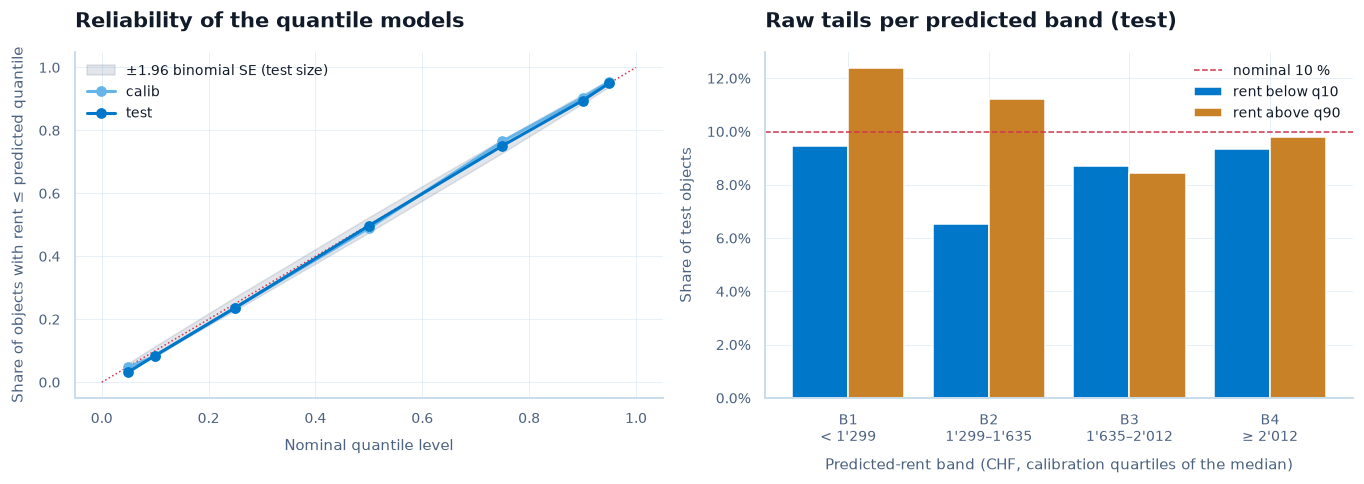

In [69]:
q50_calib = quantile_columns(q_calib, qmodel.levels_, (0.5,))[:, 0]
q50_test = quantile_columns(q_test, qmodel.levels_, (0.5,))[:, 0]
band_cutpoints = fit_band_cutpoints(q50_calib, n_bands=4)  # log scale, calibration medians only
BAND_LABELS = [f"B{i + 1}" for i in range(len(band_cutpoints) + 1)]
edges = [f"{v:,.0f}".replace(",", "'") for v in np.exp(band_cutpoints)]
BAND_TEXT = dict(zip(BAND_LABELS, [f"< {edges[0]}"]
                     + [f"{a}–{b}" for a, b in zip(edges[:-1], edges[1:], strict=True)]
                     + [f"≥ {edges[-1]}"], strict=True))
band_test = assign_band(q50_test, band_cutpoints)
q10_test, q90_test = np.exp(quantile_columns(q_test, qmodel.levels_, (0.1, 0.9)).T)
raw_band = coverage_report(y_test, q10_test, q90_test, groups=pd.Series(band_test, name="band"),
                           include_overall=False)

lvl = np.asarray(qmodel.levels_)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
se = 1.96 * np.sqrt(lvl * (1 - lvl) / len(y_test))
axes[0].fill_between(lvl, lvl - se, lvl + se, color=COLORS["gray"], alpha=0.2,
                     label="±1.96 binomial SE (test size)")
axes[0].plot([0, 1], [0, 1], color=COLORS["reference"], ls=":", lw=1)
for split, color in (("calib", COLORS["secondary"]), ("test", COLORS["primary"])):
    axes[0].plot(lvl, quantile_table[f"empirical_{split}"], "o-", color=color, label=split)
axes[0].set_xlabel("Nominal quantile level")
axes[0].set_ylabel("Share of objects with rent ≤ predicted quantile")
axes[0].set_title("Reliability of the quantile models")
axes[0].legend()
xb = np.arange(len(raw_band))
axes[1].bar(xb - 0.2, raw_band["below"], 0.4, color=COLORS["primary"], label="rent below q10")
axes[1].bar(xb + 0.2, raw_band["above"], 0.4, color=COLORS["orange"], label="rent above q90")
axes[1].axhline(0.1, color=COLORS["reference"], ls="--", lw=1, label="nominal 10 %")
axes[1].set_xticks(xb, [f"{b}\n{BAND_TEXT[b]}" for b in raw_band.index])
axes[1].set_xlabel("Predicted-rent band (CHF, calibration quartiles of the median)")
axes[1].set_ylabel("Share of test objects")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Raw tails per predicted band (test)")
axes[1].legend()
fig.tight_layout()
save_fig(fig, "quantile_reliability", paths.figures)
plt.show()

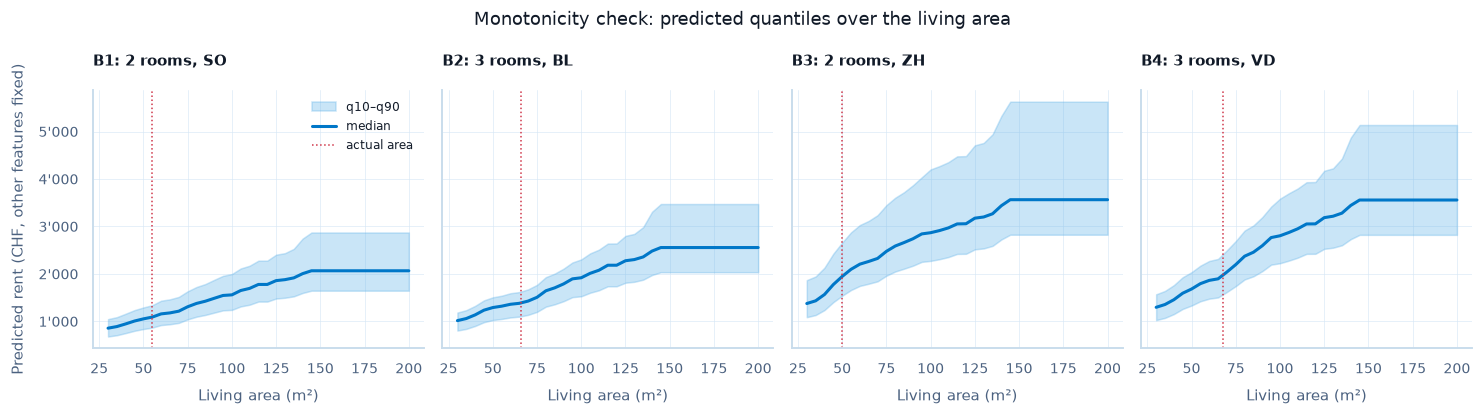

PASS  no quantile decreases when the area grows; decreasing steps out of 1,904 checked per variant (raw and rearranged): area only: 0, area_per_room recomputed: 0


In [70]:
rng = np.random.default_rng(RANDOM_STATE)
picks = [int(rng.choice(np.flatnonzero(band_test == b))) for b in BAND_LABELS
         if (band_test == b).any()]  # one random test object per predicted band
AREA_GRID = np.arange(30.0, 201.0, 5.0)
steps_down = {"area only": 0, "area_per_room recomputed": 0}
fig, axes = plt.subplots(1, len(picks), figsize=(3.4 * len(picks), 3.8), sharey=True)
for ax, pos in zip(np.atleast_1d(axes), picks, strict=True):
    grid = X_test_lgb.iloc[[pos] * len(AREA_GRID)].assign(area=AREA_GRID)
    variants = {"area only": grid, "area_per_room recomputed": add_engineered_features(grid)}
    for name, frame in variants.items():
        for q in (qmodel.predict_raw(frame), qmodel.predict(frame)):
            steps_down[name] += int((np.diff(q, axis=0) < -1e-9).sum())
    q_chf = np.exp(quantile_columns(qmodel.predict(variants["area_per_room recomputed"]),
                                    qmodel.levels_, (0.1, 0.5, 0.9)))  # as in the app
    ax.fill_between(AREA_GRID, q_chf[:, 0], q_chf[:, 2], color=COLORS["secondary"], alpha=0.35,
                    label="q10–q90")
    ax.plot(AREA_GRID, q_chf[:, 1], color=COLORS["primary"], label="median")
    ax.axvline(X_test_lgb["area"].iloc[pos], color=COLORS["reference"], ls=":", lw=1,
               label="actual area")
    obj = test_df.iloc[pos]
    ax.set_title(f"{band_test[pos]}: {obj['rooms']:.0f} rooms, {obj['canton']}", fontsize=10)
    ax.set_xlabel("Living area (m²)")
np.atleast_1d(axes)[0].set_ylabel("Predicted rent (CHF, other features fixed)")
np.atleast_1d(axes)[0].yaxis.set_major_formatter(chf_formatter())
np.atleast_1d(axes)[0].legend(fontsize=8)
fig.suptitle("Monotonicity check: predicted quantiles over the living area")
fig.tight_layout()
save_fig(fig, "quantile_monotonicity", paths.figures)
plt.show()
n_checks = len(picks) * (len(AREA_GRID) - 1) * len(Q_NAMES) * 2
Q_MONOTONE_OK = all(v == 0 for v in steps_down.values())
print(f"{'PASS' if Q_MONOTONE_OK else 'FAIL'}  no quantile decreases when the area grows; "
      f"decreasing steps out of {n_checks:,} checked per variant (raw and rearranged): "
      + ", ".join(f"{k}: {v}" for k, v in steps_down.items()))

**Interpretation.**

- **Pinball loss.** Similar values on the calibration and test sets mean that the quantile models
  generalise; they were fitted on neither. The loss is largest at the median and smallest in the
  tails, simply because the pinball loss weights tail errors by the small level `a`.
- **Reliability.** Points close to the diagonal (inside the grey binomial band) mean calibrated
  quantiles. A curve that is too flat (q05 above 5 %, q95 below 95 %) means that the raw intervals
  are too narrow, and one that is too steep means they are too wide. Either way, section 19 corrects
  the 80 % interval with conformal calibration. This plot only shows how much correction is needed.
- **Tails per predicted band.** This is the conditional check that marginal coverage hides. Bars
  near 10 % in every band mean that the shifted start works. If the cheapest band has far more than
  10 % below q10 (or the most expensive band far more above q90), the tails are pulled towards the
  global quantile. That is exactly what the Mondrian calibration by predicted band repairs.
- **Crossing.** Crossing quantiles before rearrangement are rare when the shares are small (a few
  percent). The rearranged quantiles never cross, and sorting changes the pinball loss only in the
  crossing rows (compare the raw and rearranged test columns).
- **Monotonicity.** With all other features fixed, the constraint guarantees 0 decreasing steps for
  every level, raw and rearranged (sorting preserves monotonicity, because every level is monotone).
  The second count also recomputes `area_per_room`, as the app does when a user changes the area;
  since `area_per_room` is constrained as well, it must also be 0. A FAIL would mean that the
  constraint was lost, for example because a feature was renamed and `monotone_vector` no longer
  finds it. The panels show the recomputed variant, i.e. what the app would display.

## 19. RQ3, Part 2: Conformal Calibration of the 80 % Intervals

Quantile models are not guaranteed to be calibrated on new data: they are regularised, and their
tails rest on few objects. **Split conformal prediction** turns any interval into one with a
finite-sample coverage guarantee. It uses only the calibration split (20 % of the objects, seen by
no model): the interval is widened, or narrowed, by the empirical quantile of its errors there.

- **Raw interval.** The evaluation plan (order of decisions) ties the interval to the point model
  of record. If LightGBM-TE won RQ2, the raw interval is q10–q90 of the quantile models, calibrated
  with **CQR** (conformalized quantile regression, Romano et al. 2019). If GPBoost won, it is
  GPBoost's Gaussian predictive interval μ ± z·σ (z = 1.28), calibrated with the **σ-normalised
  score** |y − μ| / σ. Both are computed below; `RQ2_WINNER` picks the primary one, on which RQ3 is
  tested.
  The other one is a sensitivity row.
- **Asymmetric.** The lower and upper ends get separate corrections, each at 10 %, so that "below
  the interval" and "above the interval" are controlled separately, for both sources and in the
  global and the Mondrian versions (only the constant band below is symmetric by construction).
  The fair-rent verdict needs this, because the two sides mean different things.
- **Mondrian (group-conditional).** One correction per cell of language region × predicted-rent
  band. The bands are the quartiles of the calibration *median predictions* of the model behind
  the raw interval, never of the actual rent, so every new apartment can be assigned to a cell:
  q50 of the quantile models (`band_cutpoints`, section 18) or GPBoost's median exp(μ). A cell
  with fewer than `MIN_MONDRIAN_GROUP` = 100 calibration objects falls back to its language region,
  and then to the global correction. Marginal coverage can hide cells where the interval fails
  systematically, for example expensive flats in Geneva or cheap flats in Ticino.
- **Global** versions (one correction for all objects) and a **constant band** ± h in CHF,
  calibrated on the calibration set like DSPRO1's single uncertainty value, are the comparisons.
- **Reliability map.** The app's map shows the test coverage per canton, district and
  municipality, published only for units with at least `MIN_MAP_CELL` test objects
  (`rq3_reliability_map.md`).

**Hypotheses (evaluation plan, section 4), tested once on the test set for the primary method:**

- **H3a:** in every language region × predicted-band cell, the test coverage is consistent with at
  least 80 %: the upper bound of its exact 95 % Clopper–Pearson interval is at least 0.80.
- **H3b:** the mean width is smaller than that of a constant band tuned *on the test set* to the
  same empirical coverage. This comparator is deliberately optimistic for the constant band.

The app (section 23) always serves the quantile models with their Mondrian CQR (`mondrian`), because
the what-if view has to be monotone in the area (evaluation plan, order of decisions, point 4).

In [71]:
ALPHA_IV = round(1 - INTERVAL_COVERAGE, 6)
IV_LEVELS = (round(ALPHA_IV / 2, 6), round(1 - ALPHA_IV / 2, 6))  # (0.1, 0.9)
Z_IV = float(stats.norm.ppf(IV_LEVELS[1]))
IV_SOURCE = "gpboost" if RQ2_WINNER == "gpboost" else "quantile"
PRIMARY_IV = f"mondrian_{IV_SOURCE}"
mu = {"calib": np.log(pred_calib["gpboost"]), "test": np.log(pred_test["gpboost"])}
sigma = {"calib": np.sqrt(gpb_var_calib), "test": np.sqrt(gpb_var_test)}
raw_iv: dict[tuple[str, str], tuple[np.ndarray, np.ndarray]] = {}  # (source, split), log scale
for split, q in (("calib", q_calib), ("test", q_test)):
    q_lo, q_hi = quantile_columns(q, qmodel.levels_, IV_LEVELS).T
    raw_iv["quantile", split] = (q_lo, q_hi)
    raw_iv["gpboost", split] = (mu[split] - Z_IV * sigma[split], mu[split] + Z_IV * sigma[split])
# Predicted-rent bands per source: quartiles of that source's calibration medians (log scale):
# q50 of the quantile models, or GPBoost's median exp(mu).
iv_median = {("quantile", "calib"): q50_calib, ("quantile", "test"): q50_test,
             ("gpboost", "calib"): mu["calib"], ("gpboost", "test"): mu["test"]}
IV_BAND_CUTS = {"quantile": band_cutpoints, "gpboost": fit_band_cutpoints(mu["calib"], n_bands=4)}
iv_groups = {
    (src, split): pd.DataFrame({"lang_region": frame["lang_region"].astype(str).to_numpy(),
                                "band": assign_band(iv_median[src, split], IV_BAND_CUTS[src])},
                               index=frame.index)
    for src in IV_BAND_CUTS for split, frame in (("calib", calib_df), ("test", test_df))
}
point_iv = {"calib": np.asarray(pred_calib[RQ2_WINNER], dtype=float),
            "test": np.asarray(pred_test[RQ2_WINNER], dtype=float)}
raw_cov = {src: float(np.mean((y_calib_log >= lo) & (y_calib_log <= hi)))
           for (src, split), (lo, hi) in raw_iv.items() if split == "calib"}
iv_edges = [f"{v:,.0f}".replace(",", "'") for v in np.exp(IV_BAND_CUTS[IV_SOURCE])]
print(f"RQ2 winner {RQ2_WINNER!r} -> primary RQ3 method {PRIMARY_IV!r}; interval levels "
      f"{IV_LEVELS}, z = {Z_IV:.4f}")
print("raw 80 % interval coverage on calibration: "
      + ", ".join(f"{src} {cov:.1%}" for src, cov in raw_cov.items()))
print(f"band cutpoints of the {IV_SOURCE} median (CHF): " + " / ".join(iv_edges))
cell_n = iv_groups[IV_SOURCE, "calib"].value_counts(["lang_region", "band"]).unstack(fill_value=0)
display(cell_n.style.map(lambda n: f"color: {COLORS['reference']}" if n < MIN_MONDRIAN_GROUP
                         else "").set_caption("calibration objects per cell (red: < "
                                              f"{MIN_MONDRIAN_GROUP}, falls back to the region)"))

RQ2 winner 'lgbm_te' -> primary RQ3 method 'mondrian_quantile'; interval levels (0.1, 0.9), z = 1.2816
raw 80 % interval coverage on calibration: quantile 82.1%, gpboost 88.1%
band cutpoints of the quantile median (CHF): 1'299 / 1'635 / 2'012


band,B1,B2,B3,B4
lang_region,,,,
de,206,282,300,272
fr,154,92,83,125
it,46,32,23,10


In [72]:
mondrian_kw = {"min_group_size": MIN_MONDRIAN_GROUP, "symmetric": False}
cqr_global = CQRCalibrator(ALPHA_IV, symmetric=False).fit(
    *raw_iv["quantile", "calib"], y_calib_log, interval_levels=IV_LEVELS)
mondrian = MondrianCQR(ALPHA_IV, **mondrian_kw).fit(
    *raw_iv["quantile", "calib"], y_calib_log, iv_groups["quantile", "calib"],
    interval_levels=IV_LEVELS)
# σ-normalised scores as CQR on (μ/σ, y/σ): (μ − y)/σ and (y − μ)/σ, one correction per side
z_mu = {split: mu[split] / sigma[split] for split in mu}
gpb_global = CQRCalibrator(ALPHA_IV, symmetric=False).fit(
    z_mu["calib"], z_mu["calib"], y_calib_log / sigma["calib"])
mondrian_gpb = MondrianCQR(ALPHA_IV, **mondrian_kw).fit(
    z_mu["calib"], z_mu["calib"], y_calib_log / sigma["calib"], iv_groups["gpboost", "calib"])
const_iv = NormalizedConformal(ALPHA_IV).fit(point_iv["calib"], np.ones(len(calib_df)), y_calib)


def interval_methods(split: str) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    # All candidate 80 % intervals of one split, in CHF.
    (q_lo, q_hi), s = raw_iv["quantile", split], sigma[split]
    lo_g, hi_g = gpb_global.predict(z_mu[split], z_mu[split])
    lo_n, hi_n, _ = mondrian_gpb.predict(z_mu[split], z_mu[split], iv_groups["gpboost", split])
    log_iv = {"raw_quantile": (q_lo, q_hi), "global_quantile": cqr_global.predict(q_lo, q_hi),
              "mondrian_quantile": mondrian.predict(q_lo, q_hi, iv_groups["quantile", split])[:2],
              "raw_gpboost": raw_iv["gpboost", split], "global_gpboost": (lo_g * s, hi_g * s),
              "mondrian_gpboost": (lo_n * s, hi_n * s)}
    out = {name: (np.exp(lo), np.exp(hi)) for name, (lo, hi) in log_iv.items()}
    out["constant_conformal"] = const_iv.predict(point_iv[split], np.ones(len(s)))
    return out


iv_calib, iv_test_all = interval_methods("calib"), interval_methods("test")
cell_test = {src: pd.Series((g["lang_region"] + " × " + g["band"]).to_numpy(), name="cell")
             for (src, split), g in iv_groups.items() if split == "test"}
prim_cal = mondrian if IV_SOURCE == "quantile" else mondrian_gpb
prim_args = raw_iv["quantile", "test"] if IV_SOURCE == "quantile" else (z_mu["test"],) * 2
served = prim_cal.predict(*prim_args, iv_groups[IV_SOURCE, "test"])[2]
level = np.where(served.eq("all"), "global", np.where(served.str.contains("band="),
                                                      "region × band", "region"))
print("test objects served per hierarchy level:",
      pd.Series(level).value_counts(normalize=True).round(3).to_dict())
display(prim_cal.cell_table().drop(columns="qhat").style.format(
    {"qhat_lo": "{:+.3f}", "qhat_hi": "{:+.3f}"}, na_rep="–").hide(axis="index"))

test objects served per hierarchy level: {'region × band': 0.822, 'region': 0.178}


level,depth,cell,n,qhat_lo,qhat_hi,calibrated
lang_region x band,0,lang_region=de|band=B1,206,+0.003,+0.027,True
lang_region x band,0,lang_region=de|band=B2,282,-0.004,-0.005,True
lang_region x band,0,lang_region=de|band=B3,300,-0.040,+0.008,True
lang_region x band,0,lang_region=de|band=B4,272,-0.031,+0.030,True
lang_region x band,0,lang_region=fr|band=B1,154,+0.015,-0.021,True
lang_region x band,0,lang_region=fr|band=B2,92,–,–,False
lang_region x band,0,lang_region=fr|band=B3,83,–,–,False
lang_region x band,0,lang_region=fr|band=B4,125,-0.018,+0.009,True
lang_region x band,0,lang_region=it|band=B1,46,–,–,False
lang_region x band,0,lang_region=it|band=B2,32,–,–,False


In [73]:
def coverage_ci(lo: np.ndarray, hi: np.ndarray, groups: pd.Series | None = None) -> pd.DataFrame:
    # coverage_report on the test set plus exact Clopper-Pearson 95 % CIs of the coverage.
    rep = coverage_report(y_test, lo, hi, groups=groups)
    hits = np.rint(rep["coverage"] * rep["n"]).astype(int)
    ci = [stats.binomtest(int(k), int(n)).proportion_ci(confidence_level=0.95, method="exact")
          for k, n in zip(hits, rep["n"], strict=True)]
    return rep.assign(cp_low=[c.low for c in ci], cp_high=[c.high for c in ci])


IV_DESC = {"raw_quantile": ("quantile", "raw q10-q90"),  # ASCII: the table is also LaTeX
           "global_quantile": ("quantile", "CQR, global"),
           "mondrian_quantile": ("quantile", "CQR, Mondrian"),
           "raw_gpboost": ("gpboost", "raw Gaussian mu +/- z sigma"),
           "global_gpboost": ("gpboost", "sigma-normalised, global"),
           "mondrian_gpboost": ("gpboost", "sigma-normalised, Mondrian"),
           "constant_conformal": (RQ2_WINNER, "constant +/- h (conformal)")}
rq3_rows = {}
for name, (lo, hi) in iv_test_all.items():
    overall = coverage_ci(lo, hi).loc["all"]
    src = IV_SOURCE if name == "constant_conformal" else IV_DESC[name][0]  # cells of its bands
    cells = coverage_ci(lo, hi, cell_test[src]).drop(index="all")
    const_w = 2 * constant_band_for_coverage(y_test, point_iv["test"], overall["coverage"])
    lo_c, hi_c = iv_calib[name]
    rq3_rows[name] = {
        "source": IV_DESC[name][0], "calibration": IV_DESC[name][1], "primary": name == PRIMARY_IV,
        "calib_coverage": float(np.mean((y_calib >= lo_c) & (y_calib <= hi_c))),
        **overall[["coverage", "cp_low", "cp_high", "below", "above", "mean_width",
                   "median_width"]].to_dict(),
        "interval_score": interval_score(y_test, lo, hi, ALPHA_IV),
        "min_cell_coverage": cells["coverage"].min(),
        "cells_below_nominal": int((cells["cp_high"] < INTERVAL_COVERAGE).sum()),
        "n_cells": len(cells), "const_width_same_cov": const_w,
        "width_ratio": overall["mean_width"] / const_w}
rq3_table = pd.DataFrame.from_dict(rq3_rows, orient="index").rename_axis("method")
rq3_fmt = {"calib_coverage": ".3f", "coverage": ".3f", "cp_low": ".3f", "cp_high": ".3f",
           "below": ".3f", "above": ".3f", "mean_width": ".0f", "median_width": ".0f",
           "interval_score": ".0f", "min_cell_coverage": ".3f", "const_width_same_cov": ".0f",
           "width_ratio": ".3f"}
display(rq3_table.style.format({k: "{:" + v + "}" for k, v in rq3_fmt.items()})
        .apply(lambda r: ["font-weight: bold" if r["primary"] else ""] * len(r), axis=1))

,source,calibration,primary,calib_coverage,coverage,cp_low,cp_high,below,above,mean_width,median_width,interval_score,min_cell_coverage,cells_below_nominal,n_cells,const_width_same_cov,width_ratio
method,,,,,,,,,,,,,,,,,
raw_quantile,quantile,raw q10-q90,False,0.821,0.810,0.790,0.829,0.085,0.105,857,723,1354,0.755,0,12,723,1.185
global_quantile,quantile,"CQR, global",False,0.801,0.786,0.766,0.806,0.103,0.111,819,691,1352,0.736,1,12,694,1.180
mondrian_quantile,quantile,"CQR, Mondrian",True,0.809,0.802,0.782,0.822,0.099,0.098,851,701,1357,0.769,0,12,718,1.185
raw_gpboost,gpboost,raw Gaussian mu +/- z sigma,False,0.881,0.882,0.866,0.898,0.059,0.058,975,898,1353,0.769,0,12,966,1.009
global_gpboost,gpboost,"sigma-normalised, global",False,0.801,0.804,0.784,0.823,0.104,0.092,786,724,1321,0.692,1,12,720,1.092
mondrian_gpboost,gpboost,"sigma-normalised, Mondrian",False,0.812,0.803,0.783,0.822,0.108,0.089,815,722,1315,0.692,1,12,718,1.135
constant_conformal,lgbm_te,constant +/- h (conformal),False,0.801,0.822,0.802,0.840,0.076,0.103,746,746,1417,0.462,3,12,745,1.001


In [74]:
g_test = iv_groups[IV_SOURCE, "test"]
base_iv = pd.DataFrame({
    "y": y_test, "lang_region": g_test["lang_region"],
    "band": pd.Categorical(g_test["band"], categories=BAND_LABELS, ordered=True),
    "price_band_realised": pd.Categorical(assign_band(y_test_log, IV_BAND_CUTS[IV_SOURCE]),
                                          categories=BAND_LABELS, ordered=True),
}, index=test_df.index)
IV_METHODS = [m for m in iv_test_all if not m.startswith("mondrian_") or m == PRIMARY_IV]
intervals_test = pd.concat([
    base_iv.assign(lo=lo, hi=hi, width=hi - lo, covered=(y_test >= lo) & (y_test <= hi),
                   method=name)
    for name, (lo, hi) in iv_test_all.items() if name in IV_METHODS
])[["y", "lo", "hi", "width", "covered", "lang_region", "band", "price_band_realised", "method"]]

compare = [f"raw_{IV_SOURCE}", PRIMARY_IV]
cell_cov = pd.concat({m: coverage_ci(*iv_test_all[m], cell_test[IV_SOURCE]) for m in compare},
                     names=["method"])
realised = pd.Series(base_iv["price_band_realised"].astype(str).to_numpy(), name="realised band")
band_cov = pd.concat({m: coverage_ci(*iv_test_all[m], realised)
                      for m in [*compare, "constant_conformal"]}, names=["method"])
prim = cell_cov.loc[PRIMARY_IV].drop(index="all")
fails = prim[prim["cp_high"] < INTERVAL_COVERAGE]  # H3a failures; else report the lowest cell
shown = fails if len(fails) else prim.nsmallest(1, "coverage")
cells_txt = "; ".join(f"{c} {r['coverage']:.1%} (n = {int(r['n'])})" for c, r in shown.iterrows())
r3 = rq3_table.loc[PRIMARY_IV]
decision_rq3 = pd.DataFrame([
    ("H3a", f"every region × band cell: upper 95 % CP bound ≥ {INTERVAL_COVERAGE:.0%}",
     f"{len(prim) - len(fails)} of {len(prim)} cells pass; "
     + (f"failing: {cells_txt}" if len(fails) else f"lowest: {cells_txt}"), fails.empty),
    ("H3b", "mean width < constant band with the same empirical coverage",
     f"{r3['mean_width']:,.0f} vs {r3['const_width_same_cov']:,.0f} CHF "
     f"(ratio {r3['width_ratio']:.2f}) at coverage {r3['coverage']:.1%}",
     bool(r3["width_ratio"] < 1)),
], columns=["hypothesis", "criterion", "estimate", "supported"])
cov_fmt = {"coverage": "{:.1%}", "cp_low": "{:.1%}", "cp_high": "{:.1%}", "below": "{:.1%}",
           "above": "{:.1%}", "mean_width": "{:,.0f}", "median_width": "{:,.0f}"}
display(decision_rq3.style.hide(axis="index"))
display(cell_cov.style.format(cov_fmt).set_caption("test coverage per language region x band"))
display(band_cov.style.format(cov_fmt).set_caption("test coverage per realised price band "
                                                   "(diagnostic: uses the actual rent)"))

hypothesis,criterion,estimate,supported
H3a,every region × band cell: upper 95 % CP bound ≥ 80%,12 of 12 cells pass; lowest: it × B4 76.9% (n = 13),True
H3b,mean width < constant band with the same empirical coverage,851 vs 718 CHF (ratio 1.19) at coverage 80.2%,False


In [75]:
# How often does H3a fail by chance alone? Simulate calibrated cells with the cell sizes of this
# run: calibration n of the serving level (cell, else region, else all) and test n per cell.
g_cal = iv_groups[IV_SOURCE, "calib"]
n_cell_cal = g_cal.value_counts(["lang_region", "band"])
n_reg_cal = g_cal["lang_region"].value_counts()
test_cells = g_test.value_counts(["lang_region", "band"])
n_cal = np.array([n_cell_cal.get(c, 0) if n_cell_cal.get(c, 0) >= MIN_MONDRIAN_GROUP
                  else n_reg_cal.get(c[0], 0) if n_reg_cal.get(c[0], 0) >= MIN_MONDRIAN_GROUP
                  else len(g_cal) for c in test_cells.index], dtype=float)
n_te, n_sim = test_cells.to_numpy(), 20 * BUDGET["power_sims"]
sim_rng = np.random.default_rng(RANDOM_STATE)
k_side = np.ceil((n_cal + 1) * (1 - ALPHA_IV / 2))  # conformal rank of each side (asymmetric)
miss = [sim_rng.beta(n_cal + 1 - k_side, k_side, size=(n_sim, len(n_cal))) for _ in range(2)]
true_cov = {"test noise only": np.full((n_sim, len(n_cal)), INTERVAL_COVERAGE),
            "test + calibration noise": 1 - miss[0] - miss[1]}
h3a_null = {}
for noise, cov in true_cov.items():
    hits = sim_rng.binomial(n_te, np.clip(cov, 0, 1))
    cp_hi = np.where(hits < n_te, stats.beta.ppf(0.975, hits + 1, np.maximum(n_te - hits, 1)), 1)
    n_fail = (cp_hi < INTERVAL_COVERAGE).sum(axis=1)
    h3a_null[noise] = {"P(>= 1 cell fails)": (n_fail >= 1).mean(),
                       "P(>= 2 cells fail)": (n_fail >= 2).mean()}
print(f"H3a under calibrated cells ({len(n_te)} cells, test n {n_te.min()}-{n_te.max()}, "
      f"calibration n {n_cal.min():.0f}-{n_cal.max():.0f}, {n_sim:,} simulations):")
display(pd.DataFrame(h3a_null).T.style.format("{:.1%}"))

H3a under calibrated cells (12 cells, test n 13-299, calibration n 111-454, 10,000 simulations):


,P(>= 1 cell fails),P(>= 2 cells fail)
test noise only,19.9%,2.0%
test + calibration noise,42.6%,10.1%


In [76]:
prim_rows = intervals_test[intervals_test["method"].eq(PRIMARY_IV)]
MAP_LEVELS = {"canton": ("canton", "canton"), "district": ("district_id", "district_name"),
              "municipality": ("municipality_id", "municipality_name")}
rel_parts = []
for map_level, (key, label) in MAP_LEVELS.items():  # drill-down of the app's reliability layer
    agg = prim_rows.groupby(test_df[key])["covered"].agg(coverage="mean", n="size")
    agg = agg[agg["n"] >= MIN_MAP_CELL]  # publish only cells with enough objects
    names = test_df.groupby(key)[label].first().reindex(agg.index).to_numpy()
    rel_parts.append(agg.assign(level=map_level, unit=names).rename_axis("key").reset_index())
reliability_map = pd.concat(rel_parts, ignore_index=True)
hits = np.rint(reliability_map["coverage"] * reliability_map["n"]).astype(int)
map_ci = [stats.binomtest(int(k), int(n)).proportion_ci(0.95, method="exact")
          for k, n in zip(hits, reliability_map["n"], strict=True)]
reliability_map["cp_low"] = [c.low for c in map_ci]
reliability_map["cp_high"] = [c.high for c in map_ci]
reliability_map = reliability_map[["level", "key", "unit", "n", "coverage", "cp_low", "cp_high"]]
(paths.results / "rq3_reliability_map.md").write_text(
    f"<!-- {PRIMARY_IV}, cells with >= {MIN_MAP_CELL} test objects, data {DATA_USED}, run "
    f"{RUN_MODE}, session {SESSION_ID} -->\n" + to_markdown(
        reliability_map, floatfmt={"coverage": ".3f", "cp_low": ".3f", "cp_high": ".3f"},
        index=False) + "\n")
print("published reliability cells (>= "
      f"{MIN_MAP_CELL} test objects): {reliability_map['level'].value_counts().to_dict()}; "
      f"cells whose CP upper bound is below {INTERVAL_COVERAGE:.0%}: "
      f"{int((reliability_map['cp_high'] < INTERVAL_COVERAGE).sum())}")

published reliability cells (>= 20 test objects): {'district': 22, 'canton': 18, 'municipality': 11}; cells whose CP upper bound is below 80%: 1


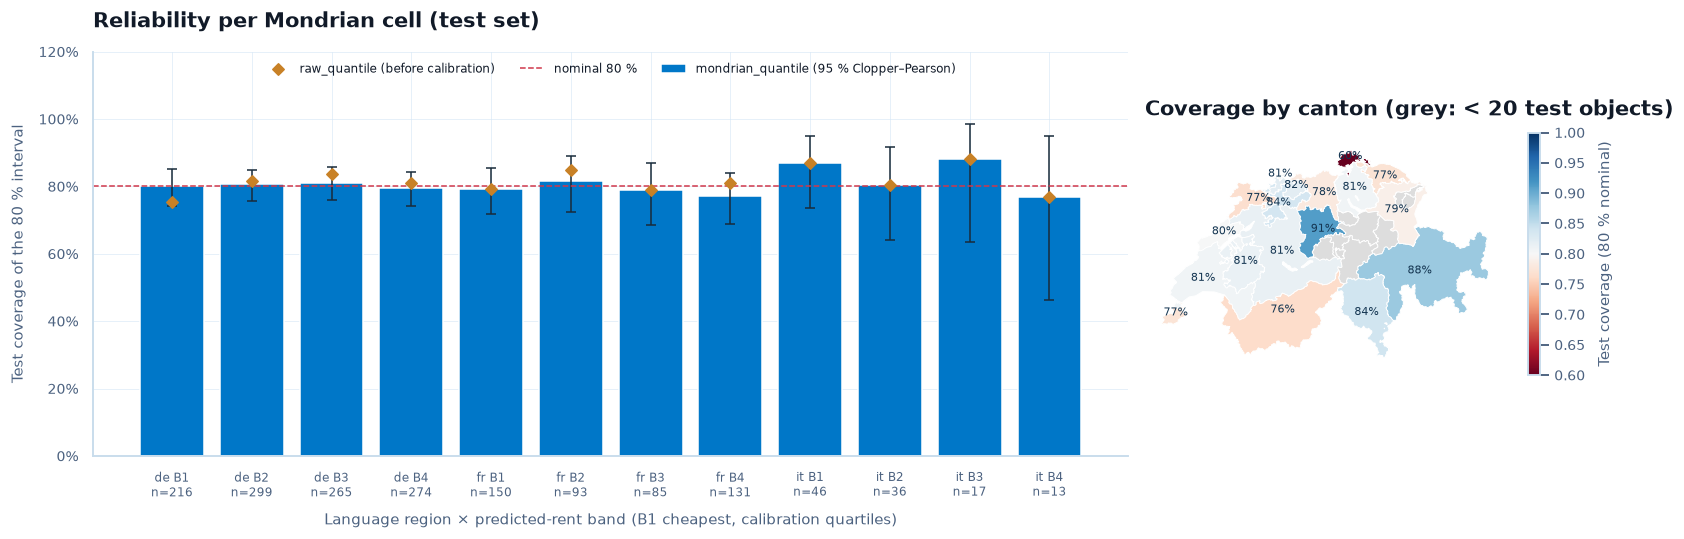

In [77]:
raw_c = cell_cov.loc[f"raw_{IV_SOURCE}"].drop(index="all").reindex(prim.index)
fig, (ax, axm) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2.3, 1]})
x = np.arange(len(prim))
ax.bar(x, prim["coverage"], color=COLORS["primary"], label=f"{PRIMARY_IV} (95 % Clopper–Pearson)",
       yerr=[prim["coverage"] - prim["cp_low"], prim["cp_high"] - prim["coverage"]], capsize=3,
       error_kw={"lw": 1, "ecolor": COLORS["neutral"]})
ax.scatter(x, raw_c["coverage"], marker="D", s=28, color=COLORS["orange"], zorder=3,
           label=f"raw_{IV_SOURCE} (before calibration)")
ax.axhline(INTERVAL_COVERAGE, color=COLORS["reference"], ls="--", lw=1, label="nominal 80 %")
ax.set_xticks(x, [f"{c.replace(' × ', ' ')}\nn={n}" for c, n in zip(prim.index, prim["n"],
                                                                   strict=True)], fontsize=8)
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Language region × predicted-rent band (B1 cheapest, calibration quartiles)")
ax.set_ylabel("Test coverage of the 80 % interval")
ax.set_title("Reliability per Mondrian cell (test set)")
ax.legend(fontsize=8, loc="upper center", ncols=3)

cantons = reliability_map[reliability_map["level"].eq("canton")].set_index("key")["coverage"]
cmap, cnorm = plt.get_cmap("RdBu"), TwoSlopeNorm(vmin=0.6, vcenter=INTERVAL_COVERAGE, vmax=1.0)
canton_geo = admin_units[["canton", "geometry"]].dissolve("canton").geometry.simplify(150)
canton_geo.plot(ax=axm, edgecolor="white", linewidth=0.6,
                color=[cmap(cnorm(cantons[c])) if c in cantons.index else to_rgba("#dddddd")
                       for c in canton_geo.index])
for c, pt in canton_geo.representative_point().items():
    if c in cantons.index:
        axm.annotate(f"{cantons[c]:.0%}", (pt.x, pt.y), ha="center", fontsize=7,
                     color=COLORS["dark"])
fig.colorbar(plt.cm.ScalarMappable(norm=cnorm, cmap=cmap), ax=axm, shrink=0.6,
             label="Test coverage (80 % nominal)")
axm.set_axis_off()
axm.set_title(f"Coverage by canton (grey: < {MIN_MAP_CELL} test objects)")
fig.tight_layout()
save_fig(fig, "rq3_reliability", paths.figures)
plt.show()

In [78]:
rq3_md_fmt = rq3_fmt | {"n_cells": ".0f", "cells_below_nominal": ".0f"}
note = f"<!-- RQ2 winner {RQ2_WINNER}, data {DATA_USED}, run {RUN_MODE}, session {SESSION_ID} -->\n"
(paths.results / "rq3_intervals.md").write_text(
    note + to_markdown(rq3_table, floatfmt=rq3_md_fmt) + "\n")
(paths.results / "rq3_intervals.tex").write_text(to_latex(
    rq3_table.drop(columns=["primary"]), "RQ3: 80 % intervals on the test set (CHF); the primary "
    f"method is {PRIMARY_IV.replace('_', ' ')}", "tab:rq3_intervals", floatfmt=rq3_md_fmt) + "\n")
(paths.results / "rq3_coverage_cells.md").write_text(
    note + to_markdown(cell_cov.reset_index(), floatfmt=rq3_md_fmt, index=False) + "\n")
(paths.results / "rq3_coverage_realised_band.md").write_text(
    note + to_markdown(band_cov.reset_index(), floatfmt=rq3_md_fmt, index=False) + "\n")
IV_TEST_PATH = paths.data_interim / f"rq3_intervals_test_{DATA_USED}.parquet"  # per object
intervals_test.to_parquet(IV_TEST_PATH)
for name, r in rq3_table.iterrows():
    with tracker.run(f"interval_{name}", stage="intervals",
                     tags={"session": SESSION_ID, "rq": "RQ3",
                           "primary": str(r["primary"]).lower()},
                     params={"source": r["source"], "calibration": r["calibration"],
                             "alpha": ALPHA_IV, "interval_levels": IV_LEVELS,
                             "min_group_size": MIN_MONDRIAN_GROUP, "rq2_winner": RQ2_WINNER,
                             "hierarchy": "lang_region x band > lang_region > global",
                             "band_cutpoints_chf": " / ".join(iv_edges),
                             "data_source": DATA_USED}):
        tracker.log_metrics({"coverage_80": r["coverage"], "coverage_80_cp_low": r["cp_low"],
                             "coverage_80_cp_high": r["cp_high"], "below": r["below"],
                             "above": r["above"], "calib_coverage_80": r["calib_coverage"],
                             "mean_width": r["mean_width"], "median_width": r["median_width"],
                             "interval_score": r["interval_score"],
                             "min_cell_coverage": r["min_cell_coverage"],
                             "cells_below_nominal": r["cells_below_nominal"],
                             "width_ratio_constant": r["width_ratio"]})
        if r["primary"]:
            tracker.log_table(cell_cov.reset_index(), "coverage_cells", index=False)
            tracker.log_table(decision_rq3, "rq3_decision", index=False)
print(f"intervals_test ({IV_TEST_PATH.name}): {len(intervals_test):,} rows = "
      f"{intervals_test['method'].nunique()} methods x {len(test_df):,} test objects; RQ3 on "
      f"{PRIMARY_IV}: H3a "
      f"{'supported' if decision_rq3.loc[0, 'supported'] else 'not supported'}, H3b "
      f"{'supported' if decision_rq3.loc[1, 'supported'] else 'not supported'}")

intervals_test (rq3_intervals_test_csv.parquet): 9,750 rows = 6 methods x 1,625 test objects; RQ3 on mondrian_quantile: H3a supported, H3b not supported


**Interpretation.**

- **Raw vs. calibrated.** The orange diamonds show the coverage before calibration. Diamonds below
  80 % in the cheap or expensive bands are the tail bias of section 18. Diamonds above 80 % mean
  that the raw interval was too wide, and conformal calibration then *narrows* it (negative
  corrections in the cell table).
- **H3a.** A cell passes if its Clopper–Pearson interval reaches 80 %. The cells differ strongly in
  size (a few hundred test objects in the German-speaking bands, only a few dozen or fewer in
  Ticino), so a pass in a small cell means "not detectably below nominal", not "exactly 80 %".
  Conformal calibration guarantees 80 % only *on average over calibration draws*. With a few
  hundred calibration and test objects per cell, the calibration and test noise together move a
  cell's coverage by several percentage points, while the CP interval only accounts for the test
  noise. The cells are also tested without a multiplicity correction (as pre-registered). The
  simulation above uses the cell sizes of this run and every cell calibrated in expectation: it
  prints how often at least one (or two) cells fail by chance, from the test noise alone and with
  the calibration noise included. If the observed number of failing cells is within what the
  simulation makes likely, a single failing cell is a real finding for that segment of this test
  set, but not by itself evidence of a systematic defect. Several failing cells (more than the
  simulation expects), or a failure repeated in the same cell across runs, would be. Cells
  served by the region or global fallback (fewer than 100 calibration objects, typically Ticino)
  need watching, because the fallback cannot adapt to their band. The fix is more calibration
  data, not a smaller `MIN_MONDRIAN_GROUP`.
- **H3b.** A width ratio below 1 means that the per-apartment intervals are narrower on average than
  a constant band with the same coverage: narrow where rents are predictable and wide where they are
  not. The comparator is tuned on the test set itself, so a ratio below 1 is conservative evidence.
  A ratio above 1 does not mean that the constant band is the better interval. Intervals built on
  the log scale are multiplicative, so in CHF they are very wide for the most expensive flats, and
  those dominate the mean width. The constant band reaches the same *overall* coverage only by
  failing where rents are high (see its coverage in the most expensive realised band). The median
  width and the interval score (width plus a penalty of 2/α per CHF of miss) weigh both aspects;
  if they favour the adaptive intervals while the mean width does not, H3b as pre-registered is not
  supported, but the adaptive intervals are still the more useful ones for the app.
- **Realised price band (diagnostic).** Coverage per *actual* rent band is expected to be lower in
  the extreme bands for every method, because objects with an unusually high or low rent are, by
  construction, far from their prediction. This table shows how strong the effect is. It is not a
  calibration target, because the actual rent is unknown when the interval is issued.
- **Sensitivity.** The rows of the non-primary source show whether the conclusion depends on the
  point model. If GPBoost's σ-normalised intervals and the quantile CQR reach similar coverage and
  width, the result is robust. The app uses the quantile models with `mondrian` in any case.
- **Reliability map.** Cantons (and, in the table, districts and municipalities) whose CP upper
  bound stays below 80 % are where the app should warn that its interval is too narrow. Units
  with fewer than `MIN_MAP_CELL` test objects stay grey, as in the published app.

---

## Phase 5 — Explain, check and deliver

## 20. Explainability: What Drives an Estimate?

A rent estimate is only useful in the Fair-Rent Check if a tenant can see *why* the model arrives
at it. We explain the monotone LightGBM point model `lgb_point`, because it serves the app and the
what-if view whatever model won RQ2 (evaluation plan, section 5). TreeSHAP computes exact Shapley
values for tree ensembles. The model predicts `log(price)`, so a SHAP value is additive on the log
scale and multiplicative on the rent: +0.10 means about +10.5 % relative to the base rent (the
model's average log prediction), with all other features at their observed values.

These are associations learned from asking rents, not causal effects. A large contribution of
`te_re_municipality` says "listings in this municipality are expensive", not "moving the flat
there would raise its rent". We explain up to `BUDGET["shap_rows"]` test objects (a seeded
subsample), which is enough for a stable global ranking.

In [79]:
import json

import requests
import shap
from scipy.stats import binomtest

from rentml.conformal import assign_band, constant_band_for_coverage, coverage_report
from rentml.evaluation import (
    bootstrap_ci,
    paired_bootstrap_mae,
    regression_metrics,
    segment_metrics,
)
from rentml.explain import global_importance, top_drivers, tree_shap
from rentml.features import add_engineered_features
from rentml.qoli import (
    Indicator,
    accessibility,
    aggregate,
    amenity_arrays,
    convergent_validity,
    fetch_osm_amenities,
    lsv_exceedance,
    minmax_normalize,
    normalization_bounds,
    value_score,
    weight_sensitivity,
)
from rentml.quantile import market_percentiles, quantile_columns
from rentml.rentcheck import RentModelBundle, fair_rent_check, predict_frame, what_if
from rentml.tracking import ablation_table, to_latex

In [80]:
# Rows of X_*_lgb follow test_df / calib_df and carry their listing_id labels (section 13).
assert X_test_lgb.index.equals(test_df.index) and X_calib_lgb.index.equals(calib_df.index)
X_te, X_ca = X_test_lgb, X_calib_lgb
constraints = lgb_point.get_params().get("monotone_constraints") or []
MONOTONE_FEATURES = [f for f, c in zip(lgb_point.feature_name_, constraints, strict=False)
                     if c == 1]

t0 = time.time()
shap_expl = tree_shap(lgb_point, X_te[F_LGB], max_rows=BUDGET["shap_rows"], seed=RANDOM_STATE)
shap_importance = global_importance(shap_expl)
shap_ids = list(shap_expl.instance_names)
base_log = float(shap_expl.base_values[0])
print(f"TreeSHAP for {len(shap_ids):,} of {len(X_te):,} test objects ({len(F_LGB)} features) "
      f"in {time.time() - t0:.1f}s")
print(f"base value {base_log:.3f} log CHF = {np.exp(base_log):,.0f} CHF "
      f"(about the geometric mean training rent)")
print(f"monotone increasing features of lgb_point: {MONOTONE_FEATURES}")
display(shap_importance.head(10).style.format(
    {"mean_abs_shap": "{:.3f}", "mean_shap": "{:+.3f}", "share": "{:.1%}", "approx_pct": "{:.1f}"}
).hide(axis="index"))

TreeSHAP for 1,625 of 1,625 test objects (21 features) in 3.6s
base value 7.394 log CHF = 1,626 CHF (about the geometric mean training rent)
monotone increasing features of lgb_point: ['area', 'area_per_room']


feature,mean_abs_shap,mean_shap,share,approx_pct
area,0.153,+0.001,27.8%,16.5
te_re_municipality,0.060,+0.001,11.0%,6.2
te_re_district,0.054,+0.001,9.9%,5.6
rooms,0.051,-0.001,9.2%,5.2
area_per_room,0.036,+0.002,6.6%,3.7
muni_density,0.031,+0.001,5.6%,3.1
population,0.021,+0.001,3.8%,2.1
te_re_canton,0.021,+0.002,3.8%,2.1
muni_population,0.020,+0.001,3.7%,2.1
rot45_y,0.016,+0.000,2.9%,1.6


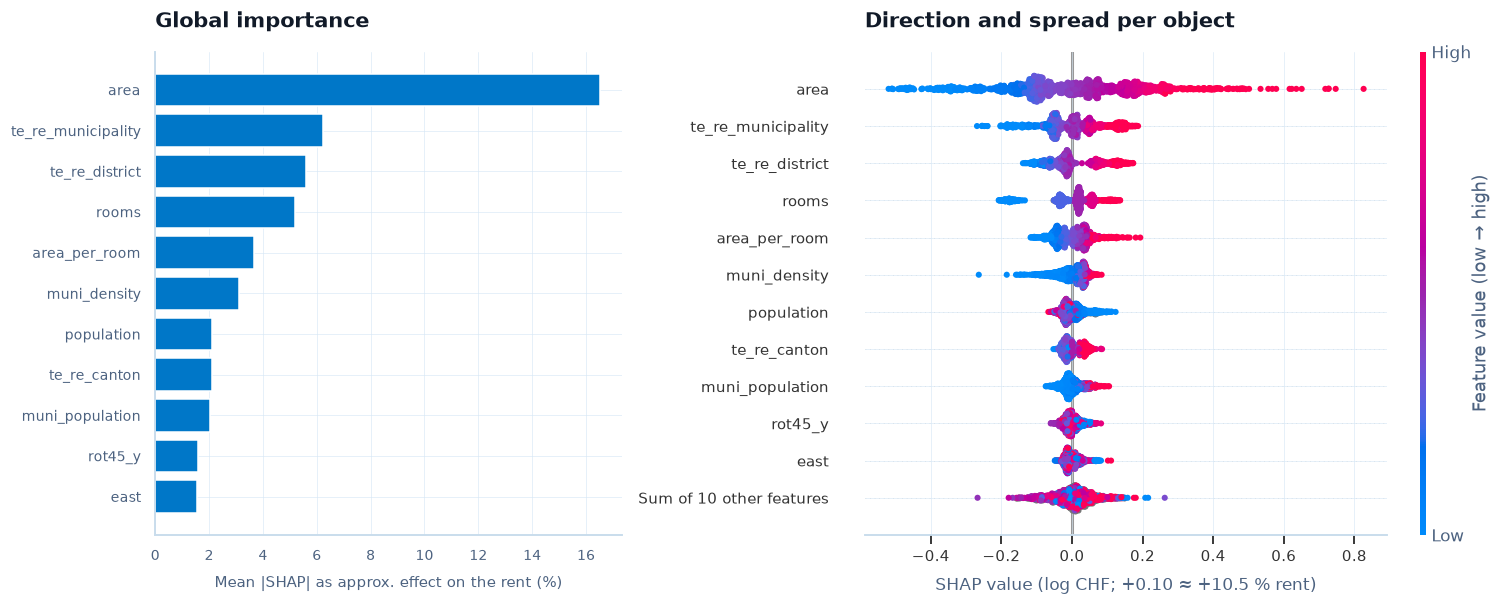

In [81]:
top = shap_importance.head(11).iloc[::-1]  # the beeswarm shows the same 11 plus "all others"
fig, (ax_bar, ax_bee) = plt.subplots(1, 2, figsize=(14, 5.6),
                                     gridspec_kw={"width_ratios": [1, 1.4]})
ax_bar.barh(top["feature"], top["approx_pct"], color=COLORS["primary"])
ax_bar.set_xlabel("Mean |SHAP| as approx. effect on the rent (%)")
ax_bar.set_title("Global importance")
shap.plots.beeswarm(shap_expl, max_display=12, show=False, ax=ax_bee, plot_size=None,
                    color_bar_label="Feature value (low → high)")
ax_bee.set_xlabel("SHAP value (log CHF; +0.10 ≈ +10.5 % rent)", fontsize=11)
ax_bee.set_title("Direction and spread per object")
ax_bee.tick_params(axis="both", labelsize=10)
fig.tight_layout()
shap_png, _ = save_fig(fig, "shap_importance_beeswarm", paths.figures)
plt.show()

In [82]:
price_shap = test_df.loc[shap_ids, "price"].to_numpy()
pred_shap = np.exp(shap_expl.base_values + shap_expl.values.sum(axis=1))
EXAMPLES = {label: int(np.argmin(np.abs(price_shap - np.quantile(price_shap, q))))
            for label, q in [("cheap", 0.10), ("median", 0.50), ("expensive", 0.90)]}
driver_rows = []
for label, pos in EXAMPLES.items():
    obj = test_df.loc[shap_ids[pos]]
    print(f"{label:>9}: {obj['area']:.0f} m², {obj['rooms']:.0f} rooms, canton {obj['canton']}; "
          f"actual {price_shap[pos]:,.0f} CHF, estimate {pred_shap[pos]:,.0f} CHF")
    driver_rows.append(top_drivers(shap_expl, pos, k=3).assign(example=label))
example_drivers = pd.concat(driver_rows, ignore_index=True)
display(example_drivers[["example", "feature", "value", "shap_log", "approx_pct"]].style.format(
    {"shap_log": "{:+.3f}", "approx_pct": "{:+.1f} %"}).hide(axis="index"))

    cheap: 27 m², 1 rooms, canton SG; actual 990 CHF, estimate 917 CHF
   median: 109 m², 4 rooms, canton JU; actual 1,607 CHF, estimate 1,944 CHF
expensive: 110 m², 3 rooms, canton TI; actual 2,700 CHF, estimate 2,201 CHF


example,feature,value,shap_log,approx_pct
cheap,area,27.000000,-0.388,-32.1 %
cheap,rooms,1.000000,-0.190,-17.3 %
cheap,te_re_district,7.212023,-0.053,-5.1 %
median,area,109.000000,+0.206,+22.9 %
median,te_re_municipality,7.085239,-0.094,-9.0 %
median,population,3.000000,+0.090,+9.5 %
expensive,area,110.000000,+0.191,+21.0 %
expensive,area_per_room,36.666667,+0.079,+8.2 %
expensive,population,6.000000,+0.057,+5.9 %


In [83]:
def sanity_check(name: str, ok: bool, detail: str) -> bool:
    print(f"{'PASS' if ok else 'FAIL'}  {name}: {detail}")
    return bool(ok)


pred_point_test = np.exp(lgb_point.predict(X_te[F_LGB]))
PLAUSIBLE_CHF = (50.0, 20_000.0)  # same range as the DSPRO1 sanity tests (section 23.2)
n_out = int(((pred_point_test < PLAUSIBLE_CHF[0]) | (pred_point_test > PLAUSIBLE_CHF[1])).sum())
sanity = {
    "no NaN": sanity_check("no NaN", not np.isnan(pred_point_test).any(),
                           f"{int(np.isnan(pred_point_test).sum())} NaN predictions"),
    "positive": sanity_check("positive", (pred_point_test > 0).all(),
                             f"min {pred_point_test.min():,.0f} CHF"),
    "plausible": sanity_check("plausible range", n_out == 0,
                              f"{n_out} outside {PLAUSIBLE_CHF[0]:,.0f}-{PLAUSIBLE_CHF[1]:,.0f} "
                              f"CHF "
                              f"(range {pred_point_test.min():,.0f}-{pred_point_test.max():,.0f})"),
    "spread": sanity_check("not collapsed", pred_point_test.std() > 50,
                           f"prediction std {pred_point_test.std():,.0f} CHF"),
}
AREA_GRID = np.arange(30.0, 201.0, 10.0)
grid_rows = X_te.sample(n=min(200, len(X_te)), random_state=RANDOM_STATE)
grid = grid_rows.loc[grid_rows.index.repeat(len(AREA_GRID))].assign(
    area=np.tile(AREA_GRID, len(grid_rows)))
grid_variants = [("area only", grid), ("area_per_room recomputed", add_engineered_features(grid))]
for label, frame in grid_variants:
    curves = np.exp(lgb_point.predict(frame[F_LGB])).reshape(len(grid_rows), len(AREA_GRID))
    drop = np.clip(-np.diff(curves, axis=1) / curves[:, :-1], 0, None).max(axis=1)  # relative
    share = float((drop <= 1e-9).mean())
    sanity[f"monotone ({label})"] = sanity_check(
        f"monotone in area, {label}", share == 1.0,
        f"{share:.1%} of {len(grid_rows)} objects never decrease on 30-200 m² "
        f"(largest drop between grid steps {100 * drop.max():.1f} %)")
print(f"\n{sum(sanity.values())} of {len(sanity)} sanity tests passed")

PASS  no NaN: 0 NaN predictions
PASS  positive: min 664 CHF
PASS  plausible range: 0 outside 50-20,000 CHF (range 664-7,499)
PASS  not collapsed: prediction std 741 CHF


PASS  monotone in area, area only: 100.0% of 200 objects never decrease on 30-200 m² (largest drop between grid steps 0.0 %)


PASS  monotone in area, area_per_room recomputed: 100.0% of 200 objects never decrease on 30-200 m² (largest drop between grid steps 0.0 %)

6 of 6 sanity tests passed


In [84]:
with tracker.run("shap_lgb_point", stage="diagnostics", tags={"session": SESSION_ID},
                 params={"model": "lgb_point", "shap_rows": len(shap_ids),
                         "monotone_increasing": ",".join(MONOTONE_FEATURES)}):
    tracker.log_metrics({"sanity_passed": sum(sanity.values()), "sanity_total": len(sanity),
                         "top_feature_share": float(shap_importance["share"].iloc[0])})
    tracker.log_table(shap_importance, "shap_importance", index=False)
    tracker.log_artifact(shap_png, artifact_path="figures")

**Interpretation.** The ranking shows which signals the point model relies on. If area and the
location signals (target encodings, coordinates, public-transport accessibility) dominate, the
model has learned the familiar hedonic structure: size sets the scale, location sets the price
level per m². The beeswarm adds the direction: red points (high feature values) on the right mean
"higher value, higher rent". A feature with a wide spread and mixed colours acts through
interactions, for example building age, where both new builds and renovated old buildings can be
expensive.

For the three example objects, the drivers read the way the Fair-Rent Check will present them: a
percentage relative to the base rent. They explain the *model*, not the market. Where the estimate
is far from the actual rent, the drivers show which inputs pushed it the wrong way.

The sanity tests follow DSPRO1 (section 23.2 there), but test monotonicity on a whole area grid
for 200 objects instead of one doubled listing. The first monotonicity test changes only `area`
and is guaranteed by the monotone constraint, so a FAIL would mean that the constraint was lost.
The second test also recomputes `area_per_room`, as the app does when a user changes the area.
At a fixed number of rooms, a larger flat also has a larger area per room, so this test is
guaranteed only because `area_per_room` is constrained as increasing too (section 13; see the
printed list of monotone features). With `area` alone constrained, an earlier run gave some
objects a lower estimate for a larger flat. A FAIL in either test would mean that a constraint was
lost, for example because a feature was renamed; the printed largest drop shows how much.

## 21. Error Analysis: Where Does the Model Fail?

An overall MAE hides where the errors are. The evaluation plan (section 3) fixes the segments:
language region, predicted and realised price band, urban/rural and listings per municipality. We
analyse the test predictions of the RQ2 winner (`RQ2_WINNER`), the point model of record. Two
definitions need a decision:

- **Price bands.** The predicted band applies `band_cutpoints` (fitted on the calibration set) to
  the median prediction of the quantile model, the same bands as the app's Mondrian calibration
  (and as RQ3 when LightGBM-TE won RQ2). The
  realised band applies the same cutpoints to the actual rent, so both are directly comparable.
  The realised band is a diagnostic only, because it uses the target.
- **Urban/rural.** The data has no official urban–rural typology yet, so we use tertiles of the
  municipal population density (inhabitants per km² of land, cutpoints from the training objects).
  This is a documented proxy; the BFS municipal typology (Gemeindetypologie 2012) can replace it.

In [85]:
ERR_MODEL = RQ2_WINNER if RQ2_WINNER in pred_test else "lgbm_te"
y_test = test_df["price"].to_numpy()
p_err = np.asarray(pred_test[ERR_MODEL], dtype=float)
q50_test = quantile_columns(q_test, qmodel.levels_, (0.5,))[:, 0]
BAND_CUTS = np.asarray(band_cutpoints, dtype=float)  # log scale, quantile q50 (section 18)
BAND_LABELS = [f"B{i + 1}" for i in range(len(BAND_CUTS) + 1)]
band_pred = pd.Categorical(assign_band(q50_test, BAND_CUTS), categories=BAND_LABELS, ordered=True)
band_real = pd.Categorical(assign_band(np.log(y_test), BAND_CUTS), categories=BAND_LABELS,
                           ordered=True)
DENSITY_CUTS = train_df["muni_density"].quantile([1 / 3, 2 / 3]).to_numpy()
DENSITY_LABELS = ["rural", "intermediate", "urban"]
urban_rural = pd.cut(test_df["muni_density"].to_numpy(dtype=float),
                     [-np.inf, *DENSITY_CUTS, np.inf], labels=DENSITY_LABELS)
segments = {
    "language region": test_df["lang_region"].to_numpy(),
    "predicted band": band_pred,
    "realised band": band_real,
    "urban/rural": urban_rural,
    "listings per municipality": test_df["muni_bucket"].array,
}
seg_table = pd.concat({name: segment_metrics(y_test, p_err, pd.Series(seg, name="segment"))
                       for name, seg in segments.items()}, names=["dimension"])
band_chf = " / ".join(f"{np.exp(c):,.0f}" for c in BAND_CUTS)
print(f"model: {ERR_MODEL}; band cutpoints (CHF): {band_chf}; "
      f"density tertiles: {DENSITY_CUTS[0]:,.0f} / {DENSITY_CUTS[1]:,.0f} inhabitants per km²")
seg_fmt = {"MAE": ".0f", "RMSE": ".0f", "MAPE": ".1f", "bias": ".0f"}
(paths.results / "error_segments.md").write_text(
    f"<!-- model {ERR_MODEL}, data {DATA_USED}, run {RUN_MODE}, session {SESSION_ID} -->\n"
    + to_markdown(seg_table.reset_index(), floatfmt=seg_fmt, index=False))
display(seg_table.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MAPE": "{:.1f}",
                                "bias": "{:+,.0f}"}))

model: lgbm_te; band cutpoints (CHF): 1,299 / 1,635 / 2,012; density tertiles: 690 / 2,003 inhabitants per km²


In [86]:
# DSPRO1 notebook, section 24.1: LightGBM on the ENGINEERED features (best eval RMSE), 840 eval
# listings, expensive quartile = actual rent >= 2'132 CHF
DSPRO1_EXPENSIVE = {"threshold_chf": 2132.0, "n": 210, "mean_error_chf": 278.6,
                    "mae_chf": 445.3, "mean_rel_error_pct": 14.7}
IV_METHOD = PRIMARY_IV  # the RQ3 method of record (section 19); bounds in CHF
iv_test = intervals_test[intervals_test["method"].eq(IV_METHOD)]
assert iv_test.index.sort_values().equals(test_df.index.sort_values()), "intervals misaligned"
iv_test = iv_test.reindex(test_df.index)
iv_lo, iv_hi = iv_test["lo"].to_numpy(dtype=float), iv_test["hi"].to_numpy(dtype=float)
q4 = y_test >= np.quantile(y_test, 0.75)
err = y_test - p_err  # DSPRO1 sign convention: > 0 means under-estimated
dspro2_expensive = {"threshold_chf": float(np.quantile(y_test, 0.75)), "n": int(q4.sum()),
                    "mean_error_chf": float(err[q4].mean()),
                    "mae_chf": float(np.abs(err[q4]).mean()),
                    "mean_rel_error_pct": float(100 * np.mean(np.abs(err[q4]) / y_test[q4]))}
expensive_cmp = pd.DataFrame({"DSPRO1 (eval listings, LightGBM)": DSPRO1_EXPENSIVE,
                              f"DSPRO2 (test objects, {ERR_MODEL})": dspro2_expensive})
display(expensive_cmp.style.format("{:,.1f}"))
q4_cov = float(iv_test["covered"].to_numpy(dtype=bool)[q4].mean())
print(f"RQ3 intervals ({IV_METHOD}) cover {q4_cov:.1%} of the expensive quartile "
      f"(below the interval: {(y_test[q4] < iv_lo[q4]).mean():.1%}, "
      f"above: {(y_test[q4] > iv_hi[q4]).mean():.1%})")

,"DSPRO1 (eval listings, LightGBM)","DSPRO2 (test objects, lgbm_te)"
threshold_chf,"2,132.0","2,060.0"
n,210.0,408.0
mean_error_chf,278.6,297.3
mae_chf,445.3,469.7
mean_rel_error_pct,14.7,14.5


RQ3 intervals (mondrian_quantile) cover 79.9% of the expensive quartile (below the interval: 1.7%, above: 18.4%)


In [87]:
diag = test_df[["price", "area", "rooms", "year_built", "canton", "lang_region",
                "muni_bucket"]].copy()
diag["predicted"] = p_err
diag["error"] = diag["price"] - diag["predicted"]
diag["pct_error"] = 100 * (diag["predicted"] / diag["price"] - 1)
diag["band_pred"] = np.asarray(band_pred)
diag["interval"] = [f"{lo:,.0f}–{hi:,.0f}" for lo, hi in zip(iv_test["lo"], iv_test["hi"],
                                                              strict=True)]
diag["covered"] = iv_test["covered"].to_numpy(dtype=bool)
worst10 = diag.loc[diag["error"].abs().sort_values(ascending=False).index[:10]]
display(worst10.style.format({"price": "{:,.0f}", "predicted": "{:,.0f}", "error": "{:+,.0f}",
                              "pct_error": "{:+.0f} %", "area": "{:.0f}", "rooms": "{:.0f}",
                              "year_built": "{:.0f}"}).hide(axis="index"))
print(f"worst 10: {int((worst10['error'] > 0).sum())} under-estimated, "
      f"{int(worst10['covered'].sum())} inside their calibrated interval, "
      f"{int((worst10['price'] >= dspro2_expensive['threshold_chf']).sum())} in the expensive "
      f"quartile")

price,area,rooms,year_built,canton,lang_region,muni_bucket,predicted,error,pct_error,band_pred,interval,covered
"14,000",168,5,nan,GE,fr,<5,"5,698","+8,302",-59 %,B4,"3,547–6,638",False
"10,714",120,4,nan,VS,fr,5-20,"3,021","+7,693",-72 %,B4,"1,790–3,420",False
"7,714",80,3,nan,VS,fr,5-20,"2,457","+5,257",-68 %,B3,"1,416–2,466",False
"7,490",200,5,nan,OW,de,<5,"3,452","+4,038",-54 %,B4,"2,352–4,516",False
"6,500",120,4,nan,GE,fr,>20,"3,935","+2,565",-39 %,B4,"2,873–5,273",False
"10,000",315,7,nan,GE,fr,>20,"7,499","+2,501",-25 %,B4,"3,439–7,166",False
"7,000",164,6,nan,GE,fr,<5,"4,973","+2,027",-29 %,B4,"3,332–6,224",False
"5,540",128,3,1997,ZH,de,>20,"3,570","+1,970",-36 %,B4,"2,707–4,647",False
"5,490",137,4,1930,ZH,de,5-20,"3,710","+1,780",-32 %,B4,"2,621–4,630",False
"3,680",137,4,nan,TI,it,<5,"1,999","+1,681",-46 %,B4,"1,565–2,636",False


worst 10: 10 under-estimated, 0 inside their calibrated interval, 10 in the expensive quartile


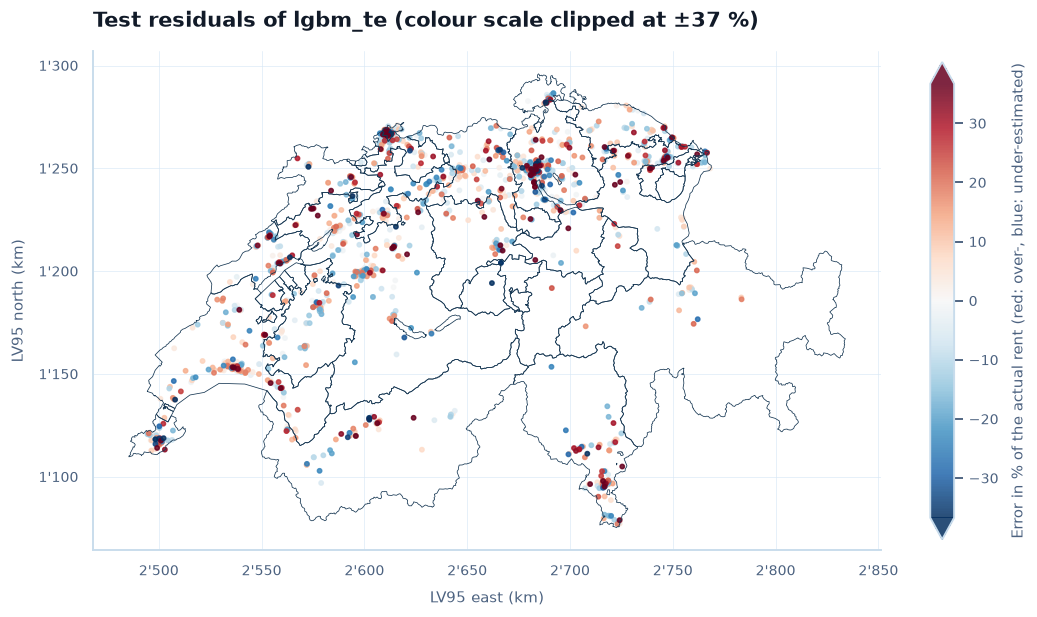

In [88]:
pct_err = 100 * (p_err / y_test - 1)  # > 0 over-estimated, < 0 under-estimated
lim = float(np.quantile(np.abs(pct_err), 0.95))
canton_shapes = admin_units[["canton", "geometry"]].dissolve("canton").geometry.simplify(150)
km_fmt = plt.FuncFormatter(lambda v, _: f"{v / 1000:,.0f}".replace(",", "'"))
order = np.argsort(np.abs(pct_err))  # largest errors drawn on top
fig, ax = plt.subplots(figsize=(10, 6.5))
canton_shapes.boundary.plot(ax=ax, color=COLORS["dark"], linewidth=0.5)
sc = ax.scatter(test_df["east"].to_numpy()[order], test_df["north"].to_numpy()[order],
                c=pct_err[order], cmap="RdBu_r", vmin=-lim, vmax=lim, s=8, alpha=0.85,
                rasterized=True)
fig.colorbar(sc, ax=ax, shrink=0.7, extend="both",
             label="Error in % of the actual rent (red: over-, blue: under-estimated)")
ax.xaxis.set_major_formatter(km_fmt)
ax.yaxis.set_major_formatter(km_fmt)
ax.set_xlabel("LV95 east (km)")
ax.set_ylabel("LV95 north (km)")
ax.set_aspect("equal")
ax.set_title(f"Test residuals of {ERR_MODEL} (colour scale clipped at ±{lim:.0f} %)")
fig.tight_layout()
resid_png, _ = save_fig(fig, "residual_map", paths.figures)
plt.show()

seg_mae = seg_table["MAE"]
with tracker.run(f"error_analysis_{ERR_MODEL}", stage="diagnostics", tags={"session": SESSION_ID},
                 params={"model": ERR_MODEL, "urban_rural": "muni_density tertiles (train)"}):
    tracker.log_metrics({f"test_mae_{k}": float(v) for k, v in
                         seg_mae.loc["listings per municipality"].items()} | {
        "test_mae_q4": dspro2_expensive["mae_chf"], "test_mean_error_q4":
        dspro2_expensive["mean_error_chf"], "coverage_80_q4": q4_cov})
    tracker.log_table(seg_table.reset_index(), "error_segments", index=False)
    tracker.log_artifact(resid_png, artifact_path="figures")

In [89]:
# Robustness (section 6): the CHF/m² outliers are in no split. Score the app's point model on
# them and on test + outliers, i.e. without the target-based filter ("unfiltered").
if len(df_ppsqm_outliers):
    outl = add_engineered_features(df_ppsqm_outliers, reference_year=REFERENCE_YEAR)
    X_out = pd.concat([te_encoder.transform(outl), outl[F_GEO_LGBM]], axis=1)[F_LGB]
    y_out, p_out = outl["price"].to_numpy(dtype=float), np.exp(lgb_point.predict(X_out))
    robust = pd.DataFrame({
        "test (filtered)": regression_metrics(y_test, pred_point_test),
        "CHF/m² outliers": regression_metrics(y_out, p_out),
        "test + outliers (unfiltered)": regression_metrics(np.r_[y_test, y_out],
                                                           np.r_[pred_point_test, p_out]),
    }).T.assign(n=[len(y_test), len(y_out), len(y_test) + len(y_out)])
    display(robust.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MedAE": "{:,.0f}",
                                 "MAPE": "{:.1f}", "R2": "{:.3f}", "n": "{:,.0f}"}))
    UNFILTERED_MAE_RATIO = float(robust["MAE"].iloc[2] / robust["MAE"].iloc[0])
    print(f"lgb_point on {len(y_out)} outliers: MAE {robust['MAE'].iloc[1]:,.0f} CHF; "
          f"unfiltered test MAE {UNFILTERED_MAE_RATIO - 1:+.1%} vs the filtered test set")
    with tracker.run("robustness_unfiltered", stage="diagnostics", tags={"session": SESSION_ID},
                     params={"model": "lgb_point", "n_outliers": len(y_out)}):
        tracker.log_metrics({"outlier_mae": float(robust["MAE"].iloc[1]),
                             "unfiltered_test_mae": float(robust["MAE"].iloc[2])})
else:
    print("no CHF/m² outliers were removed in section 6: no unfiltered robustness check")

,MAE,RMSE,MedAE,MAPE,R2,n
test (filtered),261,483,178,14.2,0.735,"1,625"
CHF/m² outliers,668,"1,195",397,38.7,0.252,155
test + outliers (unfiltered),296,581,187,16.4,0.653,"1,780"


lgb_point on 155 outliers: MAE 668 CHF; unfiltered test MAE +13.6% vs the filtered test set


**Interpretation.** Read the segment table through the `bias` column (mean of prediction minus
actual rent). If the bias falls from clearly positive in band B1 to clearly negative in band B4 of
the **realised** band, the model still regresses towards the mean: cheap apartments are
overestimated and expensive ones underestimated. Part of this is unavoidable, because the
realised band selects on the target, so noise alone creates the pattern. The **predicted** band is
the fair comparison: there the bias should be close to zero in every band. MAPE compares bands
better than MAE, which grows mechanically with the rent level. Segments with small `n` (often the
Italian-speaking region or the `<5` bucket) have noisy metrics.

For the expensive quartile, compare with DSPRO1. If the mean error (actual minus prediction) and
the mean relative error are below DSPRO1's +279 CHF and 14.7 %, the new pipeline (object-level
deduplication, nested target encodings or random effects, coordinates) has reduced the
underestimation. If not, the remaining gap is information the tabular features do not carry
(view, interior standard, renovation), which is what the listing text (RQ1) is meant to add. The
two rows come from different evaluation sets (DSPRO1: 840 eval listings of its random split,
scored with its best-RMSE LightGBM; DSPRO2: the frozen object-level test set), so the comparison
is indicative, not a test. The interval coverage in the expensive quartile shows whether the
calibrated intervals compensate: close to 80 % means that the price bands widen the intervals
where the point estimate is weakest; a large "above" share means the intervals are still too low
for expensive flats.

The unfiltered check puts the price-per-m² filter of section 6 into perspective. The outliers
are, by construction, objects whose rent per m² is far from their municipality, so a much larger
MAE on them is expected (many are parking spaces, weekly prices or placeholders, not
apartments). The relevant number is the change of the test MAE once they are added: the filter
uses the rent, so the filtered test MAE is somewhat optimistic, and this line shows by how much.
The outliers are not regime-filtered, so with text they may also contain non-market rents.

The worst predictions usually fall into the three DSPRO1 categories: implausible targets that
survived cleaning, special objects (penthouses, lofts, furnished flats) and ordinary-looking
objects whose price the features cannot explain. The table is shown here only and is not
exported, because listing-level rents must not be redistributed (data licence, section 2). The
residual map shows relative errors, not rents, at national scale; it is a diagnostic for the
report, while every map in the app aggregates to cells with at least `MIN_MAP_CELL` objects. If
it shows coloured clusters rather than salt-and-pepper noise, location effects remain in the
residuals; the Moran's I test of RQ2 quantifies this.

## 22. Quality-of-Life Index (RQ4): A First Prototype

RQ4 asks whether a valid quality-of-life index can be built without ground truth. We follow the
OECD/JRC *Handbook on Constructing Composite Indicators*: directed indicators, winsorised min–max
normalisation to 0–100 (100 = best), equal weights within a dimension, user weights across
dimensions and linear aggregation. Validity can only be checked indirectly: rank stability under
random weights (Dirichlet perturbation) and convergent validity with independent municipal
indicators.

Only part of the planned indicators is available in this run:

| Dimension | Indicator | Source | Status |
|---|---|---|---|
| transport | public-transport accessibility `oev` (higher is better, log1p) | ARE, DSPRO1 enrichment | available (enriched objects only) |
| sunshine | roof solar suitability class 1–5 `solar` (proxy for sunshine) | BFE sonnendach.ch, DSPRO1 enrichment | available (enriched objects only) |
| amenities | OSM accessibility with distance decay `acc_total` | OpenStreetMap (ODbL) | only with an OSM cache or `FETCH_OSM=1` |
| noise | road and rail L<sub>r,Tag</sub> / L<sub>r,Nacht</sub> against the LSV limits | BAFU sonBASE | missing (rasters not yet sampled) |
| air | NO₂ and PM2.5 annual means | BAFU PolluMap | missing |
| green | share of green and recreational land around the building | BFS Arealstatistik | missing |

Local population density is **context, not quality**: dense places offer better access but also
more noise, and people value density differently. It is shown next to the index (urban/rural
tertiles from section 21) but not aggregated into it.

In [90]:
OSM_CACHE = paths.cache / "osm_amenities.parquet"
osm = None
if FETCH_OSM:
    try:  # several minutes for Switzerland; reruns fetch only missing categories
        osm = fetch_osm_amenities(OSM_CACHE)
    except (requests.RequestException, RuntimeError) as exc:
        print(f"OSM download failed ({type(exc).__name__}: {exc}); continuing without amenities")
elif OSM_CACHE.exists():
    osm = pd.read_parquet(OSM_CACHE)

qoli_frame = df_model[["oev", "solar", "muni_density", "municipality_id", "lang_region",
                       "east", "north", "price", "area"]].copy()
QOLI_INDICATORS = [
    Indicator("oev", "transport", True, "ARE public-transport accessibility (DSPRO1 enrichment)",
              transform="log1p"),
    Indicator("solar", "sunshine", True, "BFE roof solar suitability class 1-5 (sunshine proxy)"),
]
if osm is not None:
    qoli_frame = qoli_frame.join(accessibility(qoli_frame[["east", "north"]], amenity_arrays(osm)))
    QOLI_INDICATORS.append(Indicator("acc_total", "amenities", True,
                                     "OSM accessibility, cosine decay 400-2400 m (ODbL)"))
QOLI_WEIGHTS = {ind.dimension: 1.0 for ind in QOLI_INDICATORS}  # app sliders; equal by default
print(f"OSM amenities: {'yes' if osm is not None else 'no (no cache, FETCH_OSM=0)'}; "
      f"dimensions and weights: {QOLI_WEIGHTS}")

qoli_bounds = normalization_bounds(qoli_frame, QOLI_INDICATORS)
qoli_norm = minmax_normalize(qoli_frame, QOLI_INDICATORS, bounds=qoli_bounds)
qoli_score, qoli_dims = aggregate(qoli_norm, QOLI_INDICATORS, QOLI_WEIGHTS)
has_qoli = qoli_score.notna()
print(f"QoLI for {int(has_qoli.sum()):,} of {len(qoli_score):,} objects ({has_qoli.mean():.0%}); "
      f"the others miss at least one weighted dimension")
display(qoli_bounds.round(3))

OSM amenities: yes; dimensions and weights: {'transport': 1.0, 'sunshine': 1.0, 'amenities': 1.0}
QoLI for 3,942 of 8,125 objects (49%); the others miss at least one weighted dimension


,lo,hi
oev,3.638,11.222
solar,1.000,5.000
acc_total,7.191,100.000


In [91]:
density_class = pd.cut(df_model["muni_density"], [-np.inf, *DENSITY_CUTS, np.inf],
                       labels=DENSITY_LABELS)
context = qoli_dims.assign(qoli=qoli_score)[has_qoli].groupby(density_class[has_qoli],
                                                              observed=True)
display(context.median().round(1).assign(n=context.size()).rename_axis("density (context)"))

muni_qoli = (pd.DataFrame({"qoli": qoli_score, "municipality_id": df_model["municipality_id"]})
             .dropna().groupby("municipality_id")["qoli"].agg(["median", "size"]))
muni_published = muni_qoli[muni_qoli["size"] >= MIN_MAP_CELL]
print(f"{len(muni_qoli):,} municipalities have a QoLI; {len(muni_published)} have at least "
      f"{MIN_MAP_CELL} objects and are published, the rest are hidden")

t0 = time.time()
muni_dims = qoli_dims[has_qoli].groupby(df_model.loc[has_qoli, "municipality_id"]).median()
sens_units = {"objects": qoli_dims[has_qoli], "municipalities": muni_dims.loc[muni_published.index]}
sens_rows = {}
for unit, dims in sens_units.items():
    if len(dims) < 3:
        print(f"weight sensitivity skipped for {unit}: only {len(dims)} units")
        continue
    sens = weight_sensitivity(dims, n_draws=BUDGET["sensitivity_draws"], seed=RANDOM_STATE,
                              base_weights=QOLI_WEIGHTS)
    sens_rows[unit] = {"units": len(dims), "spearman_median": sens["spearman"].median(),
                       "spearman_p05": sens["spearman"].quantile(0.05),
                       "top_decile_retention": sens["top_decile_retention"].mean(),
                       "mean_abs_rank_shift_pct": sens["mean_abs_rank_shift_pct"].mean()}
qoli_sensitivity = pd.DataFrame(sens_rows).T
print(f"{BUDGET['sensitivity_draws']} Dirichlet weight draws in {time.time() - t0:.1f}s")
display(qoli_sensitivity.round(3))

,transport,sunshine,amenities,qoli,n
density (context),,,,,
rural,41.3,50.0,67.4,53.1,932
intermediate,62.5,50.0,93.5,68.2,1476
urban,74.9,50.0,99.3,76.1,1534


708 municipalities have a QoLI; 33 have at least 20 objects and are published, the rest are hidden


500 Dirichlet weight draws in 0.8s


,units,spearman_median,spearman_p05,top_decile_retention,mean_abs_rank_shift_pct
objects,3942.0,0.970,0.834,0.867,5.960
municipalities,33.0,0.955,0.802,0.790,6.585


In [92]:
ppsqm = df_model["price"] / df_model["area"]
value_scores = pd.concat([value_score(qoli_score.loc[idx], ppsqm.loc[idx])  # peers: language
                          for idx in df_model.groupby("lang_region").groups.values()])
rho_price = qoli_score[has_qoli].corr(ppsqm[has_qoli], method="spearman")
print(f"Spearman(QoLI, CHF/m²) = {rho_price:+.2f} over {int(has_qoli.sum()):,} objects "
      f"(> 0: part of the quality is priced in)")
muni_names = df_model.groupby("municipality_id")["municipality_name"].first()
muni_value = muni_published.assign(
    municipality=muni_names, chf_per_m2=ppsqm.groupby(df_model["municipality_id"]).median(),
    value=value_scores.groupby(df_model["municipality_id"]).median()).sort_values("value")
print(f"Published municipalities (≥ {MIN_MAP_CELL} objects) with the lowest and highest median "
      "value score (QoLI percentile vs CHF/m² percentile within the language region):")
display(pd.concat([muni_value.head(3), muni_value.tail(3)])[
    ["municipality", "size", "median", "chf_per_m2", "value"]].round(1))

EXTERNAL_FILE = paths.data_external / "bfs_city_statistics.csv"
convergent = {}
if EXTERNAL_FILE.exists():  # expected: municipality_id + numeric indicator columns
    external = pd.read_csv(EXTERNAL_FILE).set_index("municipality_id")
    external.index = external.index.astype("int64")
    score = muni_published["median"].rename_axis("municipality_id")
    score.index = score.index.astype("int64")
    for col in external.select_dtypes("number").columns:
        convergent[col] = convergent_validity(score, external[col])
    display(pd.DataFrame(convergent).T.round(3))
else:
    print(f"No external benchmark at data/{EXTERNAL_FILE.parent.name}/{EXTERNAL_FILE.name}: "
          "convergent validity (RQ4) is NOT assessed in this run. Expected columns: "
          "municipality_id plus numeric BFS City Statistics indicators.")

Spearman(QoLI, CHF/m²) = +0.30 over 3,942 objects (> 0: part of the quality is priced in)
Published municipalities (≥ 20 objects) with the lowest and highest median value score (QoLI percentile vs CHF/m² percentile within the language region):


,municipality,size,median,chf_per_m2,value
municipality_id,,,,,
295,Horgen,20,63.6,33.6,25.2
1061,Luzern,74,69.5,28.6,42.3
131,Adliswil,21,72.8,28.1,42.4
2581,Olten,27,69.9,18.7,66.2
404,Burgdorf,32,74.2,19.2,69.0
6711,Delémont,26,72.6,16.4,73.5


No external benchmark at data/external/bfs_city_statistics.csv: convergent validity (RQ4) is NOT assessed in this run. Expected columns: municipality_id plus numeric BFS City Statistics indicators.


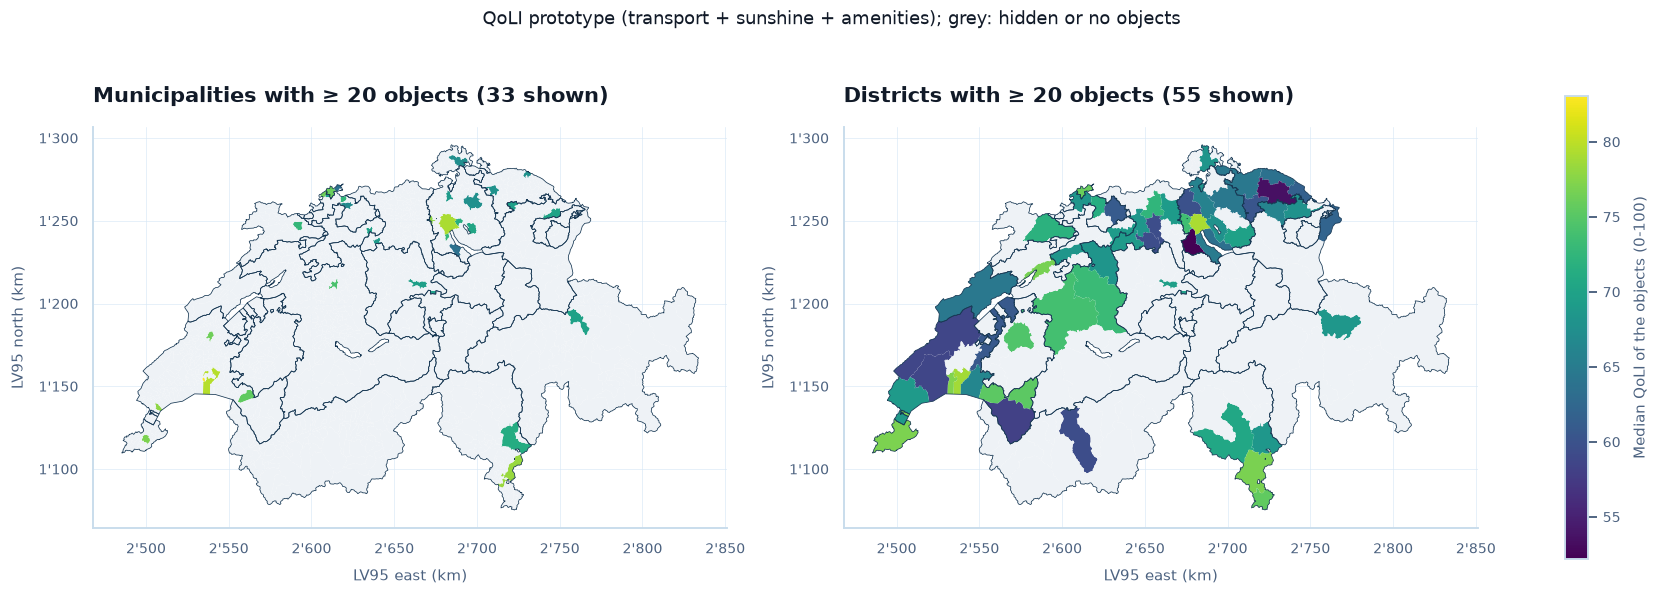

In [93]:
dist_qoli = (pd.DataFrame({"qoli": qoli_score, "district_id": df_model["district_id"]})
             .dropna().groupby("district_id")["qoli"].agg(["median", "size"]))
dist_published = dist_qoli[dist_qoli["size"] >= MIN_MAP_CELL]
layers = {  # unit -> (simplified shapes, published median QoLI)
    "municipalities": (admin_units.set_index("municipality_id").geometry, muni_published),
    "districts": (admin_units[["district_id", "geometry"]].dissolve("district_id").geometry,
                  dist_published),
}
published = pd.concat([muni_published["median"], dist_published["median"]])
vmin, vmax = (published.min(), published.max()) if len(published) else (0.0, 100.0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), layout="constrained")
for ax, (unit, (shapes, unit_stats)) in zip(axes, layers.items(), strict=True):
    frame = shapes.simplify(150).to_frame("geometry")
    frame["qoli"] = unit_stats["median"].reindex(frame.index).to_numpy()
    frame.plot(ax=ax, column="qoli", cmap="viridis", vmin=vmin, vmax=vmax, linewidth=0,
               missing_kwds={"color": "#EEF2F6"})
    canton_shapes.boundary.plot(ax=ax, color=COLORS["dark"], linewidth=0.5)
    ax.xaxis.set_major_formatter(km_fmt)
    ax.yaxis.set_major_formatter(km_fmt)
    ax.set_xlabel("LV95 east (km)")
    ax.set_ylabel("LV95 north (km)")
    ax.set_aspect("equal")
    ax.set_title(f"{unit.capitalize()} with ≥ {MIN_MAP_CELL} objects ({len(unit_stats)} shown)")
fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(vmin, vmax), "viridis"), ax=axes, shrink=0.8,
             label="Median QoLI of the objects (0-100)")
fig.suptitle(f"QoLI prototype ({' + '.join(QOLI_WEIGHTS)}); grey: hidden or no objects")
qoli_png, _ = save_fig(fig, "qoli_map", paths.figures)
plt.show()

In [94]:
qoli_metrics = {"qoli_coverage": float(has_qoli.mean()), "n_munis_published": len(muni_published),
                "n_districts_published": len(dist_published),
                "spearman_qoli_ppsqm": float(rho_price)}
qoli_metrics |= {f"{unit}_{k}": float(v) for unit, row in qoli_sensitivity.iterrows()
                 for k, v in row.items()}
qoli_metrics |= {f"convergent_rho_{k}": v["rho"] for k, v in convergent.items()
                 if np.isfinite(v["rho"])}
(paths.results / "qoli_sensitivity.md").write_text(
    f"<!-- {BUDGET['sensitivity_draws']} Dirichlet draws, session {SESSION_ID} -->\n"
    + to_markdown(qoli_sensitivity.rename_axis("unit"), floatfmt=".3f"))
with tracker.run("qoli_prototype", stage="qoli", tags={"session": SESSION_ID},
                 params={"indicators": ",".join(i.name for i in QOLI_INDICATORS),
                         "weights": json.dumps(QOLI_WEIGHTS), "winsor": "0.01/0.99",
                         "aggregation": "linear; equal within, weights across dimensions",
                         "min_map_cell": MIN_MAP_CELL, "osm": osm is not None,
                         "external_benchmark": EXTERNAL_FILE.exists()}):
    tracker.log_metrics(qoli_metrics)
    tracker.log_table(muni_published, "qoli_municipalities")
    tracker.log_table(dist_published, "qoli_districts")
    tracker.log_artifact(qoli_png, artifact_path="figures")

**Missing dimensions: how noise will enter.** The noise dimension will sample the BAFU sonBASE
rasters (road and rail, rating levels L<sub>r,Tag</sub> for 06–22 h and L<sub>r,Nacht</sub> for
22–06 h) at the building coordinate and compare them with the impact thresholds of the noise
abatement ordinance (LSV, sensitivity level II: 60 dB(A) day, 50 dB(A) night). Road and rail are
assessed separately, never summed energetically. The helper `lsv_exceedance` is ready; the example
below uses four **made-up** points only to show its output (`<NA>` where a level is unknown).

In [95]:
noise_demo = pd.DataFrame({"road_day_db": [55.0, 62.5, 58.0, np.nan],
                           "road_night_db": [45.0, 49.0, 53.5, 47.0]},
                          index=pd.Index(["A", "B", "C", "D"], name="illustrative point"))
noise_demo.join(lsv_exceedance(noise_demo["road_day_db"], noise_demo["road_night_db"]))

,road_day_db,road_night_db,day_excess_db,exceeds_day,night_excess_db,exceeds_night,exceeds_any
illustrative point,,,,,,,
A,55.0,45.0,0.0,False,0.0,False,False
B,62.5,49.0,2.5,True,0.0,False,True
C,58.0,53.5,0.0,False,3.5,True,True
D,NaN,47.0,NaN,<NA>,0.0,False,<NA>


**Interpretation.** With two of the six planned dimensions (three if OSM amenities were loaded)
this is a prototype, not the planned QoLI: it answers "how well connected and how sunny", not "how
good a place to live". Three points matter for RQ4 all the same:

- **Coverage.** The index exists only for objects with DSPRO1 enrichment (the printed share),
  because `oev` and `solar` come from that step. A direct spatial join of the ARE and BFE layers
  for all objects would remove this gap.
- **Rank stability.** If the median Spearman correlation between baseline and perturbed ranks
  stays high (above about 0.9) and most of the top decile stays in the top decile, the ranking does
  not hinge on the exact weights, which is what users need when they move the weight sliders.
  With few dimensions that are weakly correlated, perturbations can reorder many units; more
  dimensions usually stabilise the ranks. Municipal medians average out object-level noise but
  rest on far fewer units, so compare both rows.
- **Convergent validity** cannot be claimed without an external benchmark. If the BFS City
  Statistics file is present, a Spearman ρ in the expected direction (positive for "good"
  indicators) whose CI excludes 0 supports validity; otherwise RQ4 stays open and is reported as
  open.

The value score is descriptive. A high score means "more QoLI per CHF/m² than peers in the same
language region", which can also flag unobserved negatives (noise, condition). If QoLI and CHF/m²
are positively correlated, part of the quality of life is already priced in (hedonic
capitalisation), which is expected and is why the value score compares within peer groups.

The map applies the publication rule of the app: a municipality or district is coloured only if at
least `MIN_MAP_CELL` objects have a QoLI. Because only enriched objects count, few
municipalities pass this rule, so the district panel is the more complete picture; the app can
fall back from municipality to district in the same way. If the density table above shows that
the dimension medians differ mainly in transport, the map is essentially a public-transport map
with a sunshine correction, which is one more reason to add the missing dimensions before the
index is used for rankings.

## 23. Fair-Rent Check and What-If: The App Contract

The Dash app must not retrain anything. It loads one file with everything needed to serve an
estimate, a calibrated interval, a verdict and a what-if. `RentModelBundle` is that contract:

| Field | Content in this run |
|---|---|
| `point_model` | `lgb_point`, monotone LightGBM on the log rent (the what-if always uses it) |
| `quantile_model` | `qmodel`, monotone quantile LightGBM (levels 5–95 %) |
| `calibrator` | `mondrian`, the Mondrian CQR of section 19 (language region × predicted band) |
| `band_cutpoints` | log-scale cutpoints of the predicted-rent band (calibration set) |
| `feature_cols` | `F_LGB`: tabular features, coordinates and target encodings (the S0 set: no text features in this version, section 17) |
| `metadata` | target encoder, interval levels, data source, session, metrics, disclaimer |

The target encoder travels in the metadata because a new address needs its canton, district and
municipality encodings (`te_encoder.transform`) before the models can be called. The listing band
shown to landlords is the uncalibrated 25th–75th percentile of the quantile model. The
predicted-rent band of a new apartment must be assigned exactly as in calibration, so the code
records which median (quantile model or point model) reproduces the RQ3 intervals.

**What "fair" means here.** The verdict compares an asking rent with current asking rents of
comparable apartments. It is **not** the legal notion of a non-abusive rent (Art. 269 ff. OR), and
the app gives no legal assessment. Tenants who consider contesting an initial rent (Art. 270 OR)
are referred to the Federal Office for Housing (BWO, www.bwo.admin.ch) and to the tenant
associations (for example www.mieterverband.ch); in cantons with a mandatory form for the initial
rent, that form discloses the previous rent. The app does not store its inputs.

In [96]:
bundle_groups = sorted({col for level in mondrian.levels_ for col in level} - {"band"})
point_metrics = regression_metrics(y_test, pred_point_test)
interval_levels = mondrian.interval_levels_ or ((1 - INTERVAL_COVERAGE) / 2,
                                                (1 + INTERVAL_COVERAGE) / 2)
bundle = RentModelBundle(
    feature_cols=list(F_LGB), point_model=lgb_point, quantile_model=qmodel, calibrator=mondrian,
    band_cutpoints=BAND_CUTS, group_cols=bundle_groups,
    metadata={
        "version": "rent_bundle_v1", "created": pd.Timestamp.now().isoformat(timespec="seconds"),
        "session": SESSION_ID, "run_mode": RUN_MODE, "data_source": DATA_USED,
        "snapshot_date": SNAPSHOT_DATE, "reference_year": REFERENCE_YEAR,
        "te_encoder": te_encoder, "te_input_cols": list(GROUP_COLS),
        "feature_transform": "rentml.features.add_engineered_features",
        "interval_levels": tuple(round(float(v), 6) for v in interval_levels),
        "coverage": INTERVAL_COVERAGE, "rq2_winner": RQ2_WINNER,
        "monotone_increasing": MONOTONE_FEATURES,
        "test_metrics_point": {k: float(v) for k, v in point_metrics.items()},
        "disclaimer": "Estimate of current asking rents for comparable apartments; "
                      "not a legal assessment (Art. 269 ff. OR).",
    },
)
# Band source: the median whose bands reproduce the RQ3 test intervals (default: quantile q50).
for band_source in ("quantile_q50", "point"):
    bundle.metadata["band_source"] = band_source
    bundle_test = predict_frame(bundle, X_te, test_df[bundle_groups])  # groups aligned by label
    same_as_rq3 = bool(np.allclose(bundle_test["lo"], iv_lo, rtol=1e-6)
                       and np.allclose(bundle_test["hi"], iv_hi, rtol=1e-6))
    if same_as_rq3:
        break
else:  # RQ3 used another interval method: serve quantile model + Mondrian CQR anyway
    bundle.metadata["band_source"] = "quantile_q50"
    bundle_test = predict_frame(bundle, X_te, test_df[bundle_groups])
print(f"calibrator: {'symmetric' if mondrian.symmetric else 'asymmetric'} Mondrian CQR with "
      f"cells {[' x '.join(level) or 'global' for level in mondrian.levels_]}; raw levels "
      f"{bundle.metadata['interval_levels']}; band source {bundle.metadata['band_source']}")
print(f"bundle reproduces the RQ3 test intervals ({IV_METHOD}): {same_as_rq3}")

calibrator: asymmetric Mondrian CQR with cells ['lang_region x band', 'lang_region', 'global']; raw levels (0.1, 0.9); band source quantile_q50
bundle reproduces the RQ3 test intervals (mondrian_quantile): True


In [97]:
bundle_calib = predict_frame(bundle, X_ca, calib_df[bundle_groups])
bundle_cov = pd.concat({
    "calibration": coverage_report(calib_df["price"].to_numpy(), bundle_calib["lo"],
                                   bundle_calib["hi"]),
    "test": coverage_report(y_test, bundle_test["lo"], bundle_test["hi"]),
}).droplevel(1)
bundle.metadata["interval_metrics"] = bundle_cov.round(4).to_dict(orient="index")
display(bundle_cov.style.format({"coverage": "{:.1%}", "below": "{:.1%}", "above": "{:.1%}",
                                 "mean_width": "{:,.0f}", "median_width": "{:,.0f}"}))
if bundle_cov.loc["calibration", "coverage"] < INTERVAL_COVERAGE - 0.01:
    print("WARNING: calibration coverage below nominal - was `mondrian` fitted on `qmodel`?")

BUNDLE_PATH = bundle.save(paths.models / "rent_bundle_v1.joblib")
bundle = RentModelBundle.load(BUNDLE_PATH)  # from here on: the app's view of the model
reloaded = predict_frame(bundle, X_te.iloc[:50], test_df[bundle_groups].iloc[:50])
assert np.allclose(reloaded[["expected", "lo", "hi"]],
                   bundle_test.iloc[:50][["expected", "lo", "hi"]])
te_cols = [c for c in te_encoder.get_feature_names_out() if c in F_LGB]
te_app = te_encoder.transform(test_df[list(GROUP_COLS)])
print(f"saved {BUNDLE_PATH.name} ({BUNDLE_PATH.stat().st_size / 1e6:.1f} MB), reload identical; "
      f"app-side target encoding matches X_test_lgb: "
      f"{np.allclose(te_app[te_cols].to_numpy(), X_te[te_cols].to_numpy())}")

with tracker.run("rent_bundle_v1", stage="app", tags={"session": SESSION_ID},
                 params={"point_model": "lgb_point", "n_features": len(F_LGB),
                         "group_cols": ",".join(bundle_groups), "rq2_winner": RQ2_WINNER,
                         "band_source": bundle.metadata["band_source"],
                         "interval_levels": str(bundle.metadata["interval_levels"])}):
    tracker.log_metrics({"test_mae": point_metrics["MAE"], "test_rmse": point_metrics["RMSE"],
                         "coverage_80": float(bundle_cov.loc["test", "coverage"]),
                         "mean_width": float(bundle_cov.loc["test", "mean_width"]),
                         "calib_coverage_80": float(bundle_cov.loc["calibration", "coverage"])})
    tracker.log_artifact(BUNDLE_PATH, artifact_path="models")

,n,coverage,below,above,mean_width,median_width
calibration,1625,80.9%,9.7%,9.4%,843,705
test,1625,80.2%,9.9%,9.8%,851,701


saved rent_bundle_v1.joblib (3.5 MB), reload identical; app-side target encoding matches X_test_lgb: True


In [98]:
check_ids = [shap_ids[EXAMPLES["median"]], shap_ids[EXAMPLES["expensive"]]]
rent_checks = []
for lid in check_ids:
    x_row, g_row = X_te.loc[[lid]], test_df.loc[[lid], bundle_groups]
    drivers = top_drivers(tree_shap(lgb_point, x_row[F_LGB]), 0, k=3)  # the app's SHAP call
    actual = float(test_df.loc[lid, "price"])
    obj_label = f"{x_row['area'].iloc[0]:.0f} m², {test_df.loc[lid, 'canton']}"
    for label, factor in [("actual rent", 1.0), ("-15 %", 0.85), ("+15 %", 1.15)]:
        res = fair_rent_check(bundle, x_row, g_row, round(actual * factor), drivers=drivers)
        rent_checks.append({"object": obj_label, "asking": label, "asking_chf": res.asking_chf,
                            "expected_chf": res.expected_chf, "lo_chf": res.lo_chf,
                            "hi_chf": res.hi_chf, "verdict": res.verdict,
                            "percentile": res.market_percentile, "cell": res.cell})
        if factor == 1.0:
            print(res.summary())  # the tenant-facing sentence of the app
            print("   drivers: " + "; ".join(f"{d.feature} {d.approx_pct:+.0f} %"
                                             for d in drivers.itertuples()))
rent_checks = pd.DataFrame(rent_checks)
display(rent_checks.style.format({"asking_chf": "{:,.0f}", "expected_chf": "{:,.0f}",
                                  "lo_chf": "{:,.0f}", "hi_chf": "{:,.0f}",
                                  "percentile": "{:.0%}"}).hide(axis="index"))

Asking CHF 1'607 is within the expected range: likely between CHF 1'294 and 2'217 (80% interval), estimate CHF 1'944, approx. market percentile 46.
   drivers: area +23 %; te_re_municipality -9 %; population +9 %


Asking CHF 2'700 is within the expected range: likely between CHF 1'624 and 3'227 (80% interval), estimate CHF 2'201, approx. market percentile 72.
   drivers: area +21 %; area_per_room +8 %; population +6 %


object,asking,asking_chf,expected_chf,lo_chf,hi_chf,verdict,percentile,cell
"109 m², JU",actual rent,"1,607","1,944","1,294","2,217",within,46%,lang_region=fr
"109 m², JU",-15 %,"1,366","1,944","1,294","2,217",within,18%,lang_region=fr
"109 m², JU",+15 %,"1,848","1,944","1,294","2,217",within,65%,lang_region=fr
"110 m², TI",actual rent,"2,700","2,201","1,624","3,227",within,72%,lang_region=it
"110 m², TI",-15 %,"2,295","2,201","1,624","3,227",within,56%,lang_region=it
"110 m², TI",+15 %,"3,105","2,201","1,624","3,227",within,85%,lang_region=it


In [99]:
# The estimate shown is the point model; interval and market percentile come from the quantile
# grid, a separately fitted model. How consistent are the two on the test set?
pct_of_point = market_percentiles(qmodel.predict(X_te[F_LGB]), qmodel.levels_,
                                  np.log(bundle_test["expected"].to_numpy()))
point_vs_q50 = bundle_test["expected"] / bundle_test["q50"] - 1
point_outside = ((bundle_test["expected"] < bundle_test["lo"])
                 | (bundle_test["expected"] > bundle_test["hi"]))
estimate_consistency = pd.Series({
    "share: point estimate outside its calibrated 80 % interval": f"{point_outside.mean():.1%}",
    "share: point estimate outside the 40th-60th percentile of its grid":
        f"{np.mean((pct_of_point < 0.4) | (pct_of_point > 0.6)):.1%}",
    "point / q50 - 1: 5th / 50th / 95th percentile of the test objects": " / ".join(
        f"{point_vs_q50.quantile(a):+.1%}" for a in (0.05, 0.5, 0.95)),
}, name="test set")
display(estimate_consistency.to_frame())

,test set
share: point estimate outside its calibrated 80 % interval,0.7%
share: point estimate outside the 40th-60th percentile of its grid,44.0%
point / q50 - 1: 5th / 50th / 95th percentile of the test objects,-9.4% / +0.7% / +15.4%


In [100]:
what_if_rows = []
for lid in check_ids:
    x_row, g_row = X_te.loc[[lid]], test_df.loc[[lid], bundle_groups]
    area0 = float(x_row["area"].iloc[0])
    table = what_if(bundle, x_row, g_row, {"area": [area0 + 10, area0 + 20]},
                    transform=add_engineered_features)
    what_if_rows.append(table.assign(object=f"{area0:.0f} m²"))
what_if_table = pd.concat(what_if_rows, ignore_index=True)
display(what_if_table[["object", "feature", "value", "expected_chf", "lo_chf", "hi_chf",
                       "q25_chf", "q75_chf", "delta_chf", "delta_pct"]].style.format(
    {"value": "{:.0f}", "expected_chf": "{:,.0f}", "lo_chf": "{:,.0f}", "hi_chf": "{:,.0f}",
     "q25_chf": "{:,.0f}", "q75_chf": "{:,.0f}", "delta_chf": "{:+,.0f}", "delta_pct": "{:+.1f}"},
    na_rep="–").hide(axis="index"))
# the same +10 / +20 m² what-if for every test object (vectorised; point model as in the app)
wi_all = np.column_stack([np.exp(lgb_point.predict(add_engineered_features(
    X_te.assign(area=X_te["area"] + step))[F_LGB])) for step in (0, 10, 20)])
wi_drop = np.clip(-np.diff(wi_all, axis=1) / wi_all[:, :-1], 0, None).max(axis=1)
WHAT_IF_MONOTONE = bool((wi_drop <= 1e-9).all()) and all(
    (np.diff(t["expected_chf"].to_numpy()) >= -1e-9).all() for t in what_if_rows)
print(f"{'PASS' if WHAT_IF_MONOTONE else 'FAIL'}  estimate never decreases when the area grows by "
      f"10 or 20 m² (area_per_room recomputed): {int((wi_drop <= 1e-9).sum()):,} of {len(X_te):,} "
      f"test objects monotone, largest drop {100 * wi_drop.max():.1f} %")

object,feature,value,expected_chf,lo_chf,hi_chf,q25_chf,q75_chf,delta_chf,delta_pct
109 m²,baseline,–,"1,944","1,294","2,217","1,436","2,001",+0,+0.0
109 m²,area,119,"2,013","1,401","2,409","1,555","2,167",+69,+3.6
109 m²,area,129,"2,078","1,480","2,572","1,643","2,301",+134,+6.9
110 m²,baseline,–,"2,201","1,624","3,227","1,869","2,799",+0,+0.0
110 m²,area,120,"2,326","1,707","3,395","1,964","2,948",+125,+5.7
110 m²,area,130,"2,738","1,808","3,653","2,080","3,155",+537,+24.4


PASS  estimate never decreases when the area grows by 10 or 20 m² (area_per_room recomputed): 1,625 of 1,625 test objects monotone, largest drop 0.0 %


**Interpretation.** With the asking rent equal to the actual rent, the verdict is usually
*within*, because the calibrated interval covers about 80 % of real rents. Moving the asking rent
by ±15 % pushes a median-priced object towards or beyond the interval edges, and the market
percentile moves with it. Whether ±15 % flips the verdict depends on the interval width
*relative* to the estimate: where the model is less certain (a relatively wide interval), the same
change flips the verdict less often, so the check is more cautious exactly there. A verdict
*above* is a prompt to look closer (the drivers and the text may justify a premium), not a finding
of an abusive rent.

**Estimate vs. percentile.** The estimate is the point model `lgb_point` (it drives the monotone
what-if), whereas the interval, the listing band and the market percentile come from the quantile
models, which are fitted separately. An asking rent equal to the estimate therefore need not sit
at the 50th percentile, and the consistency table shows how large this gap is on the test set: the
share of point estimates outside the 40th–60th percentile of their own quantile grid, the spread
of point / q50 − 1 and the share outside the calibrated interval. If these shares are small, the
two models tell the same story. If they are large, the app should display q50 next to (or instead
of) the point estimate, or state that the percentile refers to the quantile model. The verdict
itself always comes from the calibrated interval, never from the point estimate.

The bundle checks guard the hand-over to the app. The calibration coverage must be at least the
nominal 80 % by construction; if it is not, the calibrator does not belong to this quantile model.
The reloaded file must give identical predictions, and the app-side target encoding must match the
encoding used in training. In the what-if rows, `delta_chf` must never be negative for a larger
area: this is the monotone constraint at work, and it is what makes the landlord view
trustworthy. The last line repeats the what-if for every test object, with `area_per_room`
recomputed as in the app. It must print PASS, because `area` and `area_per_room` are both
constrained (section 13). A FAIL would mean that a constraint was lost: for the printed share of
objects the app would then show a lower estimate for a larger flat.

## 24. Reporting: Ablation Table and Model Card

No number in the report is typed by hand. The ablation table is rendered from the tracked runs of
this session (`tags.session == SESSION_ID`), so runs of earlier or aborted sessions cannot leak
in. Within a stage, the run is chosen by its cross-validation MAE, never by a test metric:
choosing on the test set would flatter the table. The DSPRO1 reproduction is its own stage
(`dspro1`); its leave-one-out variant is excluded from the selection, because its CV MAE is
optimistic by construction (section 12.1). The `tabular` row is LightGBM on `F_TAB` only
(section 13), so the step to `tabular+geo` measures the location information. The `dspro1` row
is a reference with its own location features (coordinates and kNN rents), so the `tabular` row,
which drops all location information, is expected to have a negative `gain_vs_prev`; the
pre-registered chain starts at `tabular`. The `tabular+geo`
row is always the RQ2 winner, because the text stages (RQ1) are built on it. The model card is
generated from the same variables and states the intended use, the limits and the legal
context.

In [101]:
runs = tracker.runs_frame()
session_runs = (runs[runs["tags.session"] == SESSION_ID] if "tags.session" in runs
                else runs.iloc[:0])
# The CV MAE of the DSPRO1 leave-one-out kNN reproduction is optimistic (section 12.1): it may be
# shown in the run list but must never win a CV-based selection.
leaky_cv = session_runs.get("params.knn_mode", pd.Series(index=session_runs.index,
                                                         dtype=object)).eq("loo")
candidates = session_runs[~leaky_cv]
# RQ1 builds S1-S3 on the RQ2 winner, so the tabular+geo row must be that model (not the CV best).
candidates = candidates[candidates["stage"].ne("tabular+geo")
                        | candidates["run_name"].eq(RQ2_WINNER)]
ABLATION_STAGES = ["baseline", "dspro1", "tabular", "tabular+geo", "text", "attributes", "fused"]
stages = [s for s in ABLATION_STAGES if s in set(candidates["stage"])]
wanted = ["cv_mae", "test_mae", "test_rmse", "test_mape", "test_r2", "test_mae_lt5"]
shown = [m for m in wanted if f"metrics.{m}" in candidates
         and candidates.loc[candidates["stage"].isin(stages), f"metrics.{m}"].notna().any()]
select_by = next((m for m in ("cv_mae", "calib_mae") if f"metrics.{m}" in candidates), None)
if stages and shown:
    ablation = ablation_table(candidates, stage_order=stages, metrics=shown,
                              pick="best" if select_by else "last", select_by=select_by)
    ablation["runs_in_stage"] = candidates["stage"].value_counts().reindex(ablation.index)
else:
    ablation = pd.DataFrame(columns=["run_name", *shown], index=pd.Index([], name="stage"))
    print("no ablation-stage runs with metrics in this session")
print(f"{len(session_runs)} runs in session {SESSION_ID} ({int(leaky_cv.sum())} excluded from "
      f"selection: leaky CV); ablation stages: {stages}; selected by {select_by or 'recency'}")
display(session_runs[["run_name", "stage", *[f"metrics.{m}" for m in shown]]]
        .rename(columns=lambda c: c.removeprefix("metrics.")).round(3))

26 runs in session 20261002-221320 (1 excluded from selection: leaky CV); ablation stages: ['baseline', 'dspro1', 'tabular', 'tabular+geo', 'fused']; selected by cv_mae


,run_name,stage,cv_mae,test_mae,test_rmse,test_mape,test_r2,test_mae_lt5
77,dedup_audit,data,NaN,NaN,NaN,NaN,NaN,NaN
78,cleaning,data,NaN,NaN,NaN,NaN,NaN,NaN
79,splits,data,NaN,NaN,NaN,NaN,NaN,NaN
80,power_mde,eval-plan,274.056,NaN,NaN,NaN,NaN,NaN
81,naive,baseline,352.162,354.853,580.049,19.752,0.618,376.433
82,dspro1_knn,dspro1,273.139,270.707,503.324,14.781,0.712,283.666
83,dspro1_knn_oof,dspro1,277.427,272.712,504.833,14.800,0.711,279.186
84,learning_curve,diagnostics,NaN,NaN,NaN,NaN,NaN,NaN
85,lgbm_te,tabular+geo,265.123,260.657,483.119,14.245,0.735,260.387
86,lgbm_tab,tabular,304.073,302.468,549.183,16.315,0.658,346.245


In [102]:
groups_test_obj = test_df["object_id"].to_numpy()
ablation[["mae_ci_low", "mae_ci_high", "gain_vs_prev", "p_vs_prev"]] = np.nan
prev = None
for stage, name in ablation["run_name"].items():
    if name not in pred_test:  # no stored test predictions: no CI for this row
        continue
    p_now = np.asarray(pred_test[name], dtype=float)
    _, lo, hi = bootstrap_ci(y_test, p_now, "MAE", n_boot=BUDGET["n_boot"],
                             groups=groups_test_obj, seed=RANDOM_STATE)
    ablation.loc[stage, ["mae_ci_low", "mae_ci_high"]] = [lo, hi]
    if prev is not None:  # MAE(previous stage) - MAE(this stage): > 0 means this stage helps
        cmp = paired_bootstrap_mae(y_test, np.asarray(pred_test[prev], dtype=float), p_now,
                                   name_a=prev, name_b=name, n_boot=BUDGET["n_boot"],
                                   seed=RANDOM_STATE, groups=groups_test_obj)
        ablation.loc[stage, ["gain_vs_prev", "p_vs_prev"]] = [cmp.diff, cmp.p_bootstrap]
    prev = name
ABL_FMT = {"cv_mae": ".0f", "test_mae": ".0f", "test_rmse": ".0f", "test_mape": ".1f",
           "test_r2": ".3f", "test_mae_lt5": ".0f", "mae_ci_low": ".0f", "mae_ci_high": ".0f",
           "gain_vs_prev": "+.1f", "p_vs_prev": ".3g"}
note = (f"session {SESSION_ID}, data {DATA_USED}, run {RUN_MODE}; one run per stage chosen by "
        f"{select_by or 'recency'}; CI: cluster bootstrap ({BUDGET['n_boot']} draws); "
        "p_vs_prev unadjusted (Holm-adjusted RQ1 tests: section 17)")
(paths.results / "ablation.md").write_text(f"<!-- {note} -->\n"
                                           + to_markdown(ablation, floatfmt=ABL_FMT))
(paths.results / "ablation.tex").write_text(f"% {note}\n" + to_latex(
    ablation, caption="Ablation by stage: one run per stage chosen by cross-validation MAE; "
    "test metrics on the frozen hold-out set (CHF) with 95 \\% bootstrap CI of the MAE and the "
    "paired MAE gain over the previous stage.", label="tab:ablation", floatfmt=ABL_FMT))
display(ablation)

,run_name,cv_mae,test_mae,test_rmse,test_mape,test_r2,test_mae_lt5,runs_in_stage,mae_ci_low,mae_ci_high,gain_vs_prev,p_vs_prev
stage,,,,,,,,,,,,
baseline,naive,352.161782,354.852886,580.049187,19.752270,0.617947,376.433308,1,332.911762,378.737289,NaN,NaN
dspro1,dspro1_knn_oof,277.426925,272.712047,504.832866,14.799617,0.710606,279.186427,1,253.735440,294.303650,82.140839,0.0005
tabular,lgbm_tab,304.073371,302.467751,549.182800,16.314837,0.657526,346.244680,1,281.695479,325.711407,-29.755704,0.0005
tabular+geo,lgbm_te,265.123428,260.657063,483.118605,14.245061,0.734966,260.387228,1,242.106770,281.153633,41.810688,0.0005
fused,fused_nn,295.940117,287.881397,526.971310,14.970344,0.684668,295.335233,1,267.218569,309.974028,-27.224334,0.0005


In [103]:
mae_point, mae_lo, mae_hi = bootstrap_ci(y_test, p_err, "MAE", n_boot=BUDGET["n_boot"],
                                         groups=test_df["object_id"], seed=RANDOM_STATE)
card_models = {ERR_MODEL: p_err, "lgb_point (app)": pred_point_test}
if "naive" in pred_test:
    card_models["naive baseline"] = np.asarray(pred_test["naive"], dtype=float)
card_metrics = pd.DataFrame({name: regression_metrics(y_test, p)
                             for name, p in card_models.items()}).T
card_metrics.loc[ERR_MODEL, "MAE 95 % CI"] = f"{mae_lo:,.0f}–{mae_hi:,.0f}"
test_cov = float(bundle_cov.loc["test", "coverage"])
const_half = constant_band_for_coverage(y_test, pred_point_test, test_cov)
cell_cov = coverage_report(y_test, bundle_test["lo"], bundle_test["hi"],
                           groups=pd.Series(test_df["lang_region"].astype(str).to_numpy()
                                            + " × " + bundle_test["band"].astype(str).to_numpy(),
                                            name="cell"), include_overall=False)
worst_cell = cell_cov["coverage"].idxmin()
git_commit = (session_runs["tags.git_commit"].dropna().iloc[-1]
              if "tags.git_commit" in session_runs and session_runs["tags.git_commit"].notna().any()
              else "unknown")
card_bucket_mae = seg_table.loc["listings per municipality", "MAE"]
card_region_mae = seg_table.loc["language region", "MAE"]
print(f"MAE {ERR_MODEL}: {mae_point:,.0f} CHF (95 % CI {mae_lo:,.0f}–{mae_hi:,.0f}); "
      f"test coverage {test_cov:.1%}, mean width {bundle_cov.loc['test', 'mean_width']:,.0f} CHF "
      f"vs constant band {2 * const_half:,.0f} CHF; weakest cell {worst_cell} "
      f"({cell_cov.loc[worst_cell, 'coverage']:.1%}, n = {cell_cov.loc[worst_cell, 'n']})")

MAE lgbm_te: 261 CHF (95 % CI 242–281); test coverage 80.2%, mean width 851 CHF vs constant band 718 CHF; weakest cell it × B4 (76.9%, n = 13)


In [104]:
fmt_row = " / ".join
card = [
    "# Model card: DSPRO2 rent model (`rent_bundle_v1`)", "",
    f"*Generated by `dspro2_ml_pipeline.ipynb` on {pd.Timestamp.now():%Y-%m-%d}; session "
    f"`{SESSION_ID}`, run mode `{RUN_MODE}`, data source `{DATA_USED}`, git `{git_commit[:10]}`.*",
    "", "## Model",
    f"- Point model for the app and the what-if: LightGBM on the log rent, monotone increasing in "
    f"{MONOTONE_FEATURES}; {len(F_LGB)} features (tabular, LV95 coordinates, hierarchical target "
    "encodings canton > district > municipality).",
    f"- Model of record for RQ2: `{RQ2_WINNER}`.",
    "- Intervals: monotone quantile LightGBM (levels "
    f"{', '.join(f'{q:g}' for q in qmodel.levels_)}) "
    f"with {'symmetric' if mondrian.symmetric else 'asymmetric'} Mondrian CQR by "
    f"{' × '.join(bundle_groups + ['predicted band'])}, nominal "
    f"{INTERVAL_COVERAGE:.0%}.",
    "- Artefact: `models/rent_bundle_v1.joblib` (joblib pickle: load trusted files only).",
    "", "## Intended use",
    "- Informational estimate of the current **asking** net rent of a Swiss apartment with a "
    f"calibrated {INTERVAL_COVERAGE:.0%} interval, a verdict (below / within / above), a market "
    "percentile and the main drivers (Fair-Rent Check, landlord price band and what-if).",
    "- Market analysis and teaching; maps publish only cells with at least "
    f"{MIN_MAP_CELL} objects.",
    "", "## Out of scope",
    "- Legal assessment of a rent (non-abusive rent, Art. 269 ff. OR; contesting the initial rent, "
    "Art. 270 OR). The app links to the BWO and the tenant associations instead.",
    "- Decisions about individuals: tenant screening, credit or insurance decisions, automated "
    "approval or rejection of applications.",
    "- Sitting-tenant rents, cooperative or subsidised rents, commercial property, locations "
    "outside Switzerland, street-level price maps. Furnished and temporary rentals are part of "
    "the training data (flagged only when text is available); estimates for them are less "
    "reliable.",
]

In [105]:
text_note = ("anonymised descriptions" if HAS_TEXT
             else f"not available in this run (data source {DATA_USED})")
card += ["", "## Data",
         f"- Listings: rentumo.ch snapshot of {SNAPSHOT_DATE} (DSPRO1 scrape), one row per "
         f"rental object after the duplicate audit: {len(train_df):,} train / {len(calib_df):,} "
         f"calibration / {len(test_df):,} test objects, grouped by object, stratified by canton × "
         "price quartile.",
         "- Enrichment: GWR building data and ARE/BFE/swisstopo location indicators (DSPRO1, for "
         f"{df_model['dspro1_enriched'].mean():.0%} of the objects), swissBOUNDARIES3D "
         f"{SB3D_VERSION} hierarchy.",
         f"- Listing text: {text_note}.",
         "- Licence: listings are used for training and evaluation only; no listing text, price "
         "or address is redistributed.",
         "", f"## Metrics (frozen hold-out test set, {len(test_df):,} objects, CHF)", "",
         to_markdown(card_metrics, floatfmt={"MAE": ".0f", "RMSE": ".0f", "MedAE": ".0f",
                                             "MAPE": ".1f", "R2": ".3f"}),
         f"- MAE by listings per municipality ({ERR_MODEL}): "
         + fmt_row(f"{k} {v:,.0f}" for k, v in card_bucket_mae.items()) + "; by language region: "
         + fmt_row(f"{k} {v:,.0f}" for k, v in card_region_mae.items()) + ".",
         f"- Expensive quartile (actual ≥ {dspro2_expensive['threshold_chf']:,.0f} CHF): mean "
         f"error (actual − prediction) {dspro2_expensive['mean_error_chf']:+,.0f} CHF, mean "
         f"relative error {dspro2_expensive['mean_rel_error_pct']:.1f} % (DSPRO1: +279 CHF, "
         "14.7 %).",
         "", "## Intervals",
         f"- Test coverage {test_cov:.1%} (nominal {INTERVAL_COVERAGE:.0%}), mean width "
         f"{bundle_cov.loc['test', 'mean_width']:,.0f} CHF; a constant band with the same coverage "
         f"is {2 * const_half:,.0f} CHF wide.",
         f"- Lowest coverage among language region × band cells: {worst_cell} "
         f"{cell_cov.loc[worst_cell, 'coverage']:.1%} (n = {cell_cov.loc[worst_cell, 'n']})."]

In [106]:
card += ["", "## Limitations",
         "- Asking rents, not contract rents; one snapshot, so no temporal drift test yet: "
         "retrain and recalibrate before use on later data.",
         "- Larger errors and wider intervals for expensive and unusual objects; municipalities "
         "with few listings lean on district and canton encodings.",
         "- Location indicators (public transport, solar) are missing for "
         f"{1 - has_qoli.mean():.0%} of the objects; the QoLI prototype covers "
         f"{len(QOLI_WEIGHTS)} of 6 planned dimensions.",
         "", "## Regulation and privacy",
         "- revDSG (Swiss Federal Act on Data Protection, in force since 1 September 2023): no "
         "personal data are model features; descriptions are anonymised before storage or LLM use; "
         f"the app does not store inputs; aggregates need at least {MIN_MAP_CELL} objects.",
         "- EU AI Act (Regulation (EU) 2024/1689): relevant only if the app is offered in the EU. "
         "As an informational tool that does not decide on access to housing, credit or services, "
         "it is not expected to fall under the high-risk use cases of Annex III. Users are told "
         "that the estimate comes from a statistical model, with its interval and drivers. Use for "
         "tenant screening would change this assessment and is out of scope."]
if not HAS_TEXT:
    card.insert(card.index("## Regulation and privacy") - 1, "- This run had no listing text: "
                "RQ1 is untested and the model cannot see view, standard or renovation.")
else:
    card.insert(card.index("## Regulation and privacy") - 1, "- The served model uses the S0 "
                f"feature set without text (CV selected {RQ1_SELECTED} in RQ1); text features "
                "enter the app in a later version.")
model_card = "\n".join(card) + "\n"
(paths.results / "model_card.md").write_text(model_card)
with tracker.run("report_tables", stage="reporting", tags={"session": SESSION_ID}):
    for name in ("ablation.md", "ablation.tex", "model_card.md", "error_segments.md",
                 "qoli_sensitivity.md"):
        tracker.log_artifact(paths.results / name, artifact_path="report")
print(f"wrote ablation.md, ablation.tex and model_card.md ({len(card)} lines) to {paths.results}")

wrote ablation.md, ablation.tex and model_card.md (44 lines) to /home/sa_linux/code/Elias-Martinelli/dspro1/docs/results


**Interpretation.** Each ablation row is the run of one stage that a user of this notebook would
have chosen without looking at the test set. If the test MAE falls from stage to stage while the
CV MAE falls with it, the improvements generalise; if the CV and test orderings disagree, the
differences are within noise, and the paired tests of RQ1/RQ2 decide, not this table. Stages that
did not run in this session (for example the text stages without descriptions) are simply
absent. The model card is regenerated on every run, so it can never disagree with the tracked
numbers; copy it into the report only from a full run on the frozen data source.

## 25. Summary: Decisions, Limits and Next Steps

The decisions below are printed from the variables of this run, in the pre-registered order
(RQ2 → RQ1 → RQ3), followed by the RQ4 status. They are only final after a full run on the frozen
data source with the evaluation plan tagged as `eval-plan-v1`.

In [107]:
rq2 = next((r for r in rq2_results if {r.name_a, r.name_b} == {"lgbm_te", "gpboost"}
            and r.n == len(test_df)), rq2_results[0] if rq2_results else None)
if rq2 is not None:
    significant = rq2.ci_low > 0 or rq2.ci_high < 0  # pre-registered primary criterion
    borderline = significant != (rq2.p_bootstrap < ALPHA_TEST)
    better = rq2.name_b if rq2.ci_low > 0 else rq2.name_a if rq2.ci_high < 0 else None
    outcome = ("no detectable difference, H2a not supported" if better is None
               else f"{better} significantly better, H2a "
               f"{'supported' if better == 'gpboost' else 'not supported'}")
    print(f"RQ2  winner: {RQ2_WINNER}. MAE {rq2.name_a} {rq2.mae_a:,.0f} vs {rq2.name_b} "
          f"{rq2.mae_b:,.0f} CHF; difference {rq2.diff:+,.1f} CHF (95 % CI {rq2.ci_low:+,.1f} to "
          f"{rq2.ci_high:+,.1f}; centred bootstrap p = {rq2.p_bootstrap:.3g}, Wilcoxon p = "
          f"{rq2.p_wilcoxon:.3g}) -> {outcome}"
          f"{' (borderline: CI and p-value disagree)' if borderline else ''}")
if rq1_table is None or len(rq1_table) == 0:
    print(f"RQ1  not tested: no listing text in this run (HAS_TEXT={HAS_TEXT}, data {DATA_USED})")
else:
    print("RQ1  text ablation: see rq1_table")
    display(rq1_table)
cells_cov = iv_test.groupby(["lang_region", "band"], observed=True)["covered"].agg(["sum", "size"])
cells_cov["cp_high"] = [binomtest(int(k), int(n)).proportion_ci(0.95, method="exact").high
                        for k, n in cells_cov[["sum", "size"]].to_numpy()]
failing = cells_cov[cells_cov["cp_high"] < INTERVAL_COVERAGE]
rq3_width = float(iv_test["width"].mean()) if "width" in iv_test else float(
    (iv_test["hi"] - iv_test["lo"]).mean())
rq3_const = 2 * constant_band_for_coverage(y_test, p_err, float(iv_test["covered"].mean()))
print(f"RQ3  coverage {iv_test['covered'].mean():.1%} overall; "
      f"{len(cells_cov) - len(failing)} of {len(cells_cov)} region × band cells consistent with "
      f"≥ {INTERVAL_COVERAGE:.0%} (Clopper-Pearson); mean width {rq3_width:,.0f} vs constant "
      f"band {rq3_const:,.0f} CHF -> "
      f"{'hypothesis supported' if failing.empty and rq3_width < rq3_const else 'not supported'}")
if not failing.empty:
    print(f"     cells below nominal: {[' × '.join(map(str, c)) for c in failing.index]}")
rs = qoli_sensitivity["spearman_median"].to_dict() if len(qoli_sensitivity) else {}
print(f"RQ4  QoLI prototype on {len(QOLI_WEIGHTS)} dimensions for {has_qoli.mean():.0%} of "
      f"objects; median rank Spearman under weight perturbation "
      f"{', '.join(f'{k} {v:.2f}' for k, v in rs.items()) or 'n/a'}; convergent validity "
      f"{'assessed' if convergent else 'open (no external benchmark)'}")

RQ2  winner: lgbm_te. MAE lgbm_te 261 vs gpboost 269 CHF; difference -8.7 CHF (95 % CI -15.0 to -2.2; centred bootstrap p = 0.01, Wilcoxon p = 0.0155) -> lgbm_te significantly better, H2a not supported
RQ1  not tested: no listing text in this run (HAS_TEXT=False, data csv)
RQ3  coverage 80.2% overall; 12 of 12 region × band cells consistent with ≥ 80% (Clopper-Pearson); mean width 851 vs constant band 718 CHF -> not supported
RQ4  QoLI prototype on 3 dimensions for 49% of objects; median rank Spearman under weight perturbation objects 0.97, municipalities 0.95; convergent validity open (no external benchmark)


In [108]:
limitations = []
if DATA_USED == "csv":
    limitations.append("CSV fallback: no listing descriptions, so no text features, attributes "
                       "or regime labels; RQ1 untested")
n_dates = df_model["observed_at"].dt.normalize().nunique()
limitations.append("single snapshot (observed_at is one date): no temporal drift test"
                   if n_dates <= 1
                   else f"observed_at spans {n_dates} dates, but no temporal drift test was run")
if len(QOLI_WEIGHTS) < 6:
    limitations.append(f"QoLI partial: {len(QOLI_WEIGHTS)} of 6 planned dimensions "
                       f"({', '.join(QOLI_WEIGHTS)}); noise, air and green missing")
if not convergent:
    limitations.append("no external municipal benchmark: RQ4 convergent validity open")
if len(test_df) < 2000:
    limitations.append(f"test set of {len(test_df):,} objects is below the planned 2,000: "
                       "per-segment comparisons are exploratory")
if FAST:
    limitations.append("fast mode: reduced budgets (folds, trials, bootstrap draws); rerun in full")
print("Limitations of this run:")
for item in limitations:
    print(f"  - {item}")

Limitations of this run:
  - CSV fallback: no listing descriptions, so no text features, attributes or regime labels; RQ1 untested
  - single snapshot (observed_at is one date): no temporal drift test
  - QoLI partial: 3 of 6 planned dimensions (transport, sunshine, amenities); noise, air and green missing
  - no external municipal benchmark: RQ4 convergent validity open
  - test set of 1,625 objects is below the planned 2,000: per-segment comparisons are exploratory


**Conclusion.** The notebook now tells the DSPRO2 story end to end: a deduplicated object table
with an official geo hierarchy, a frozen split and pre-registered plan, a spatial comparison (RQ2)
decided by a paired cluster bootstrap, calibrated per-apartment intervals (RQ3), explanations, an
error analysis against the DSPRO1 weak spots, a first QoLI and a model bundle that the app can
serve without retraining. Where the printed decisions say "no detectable difference" or "not
supported", that is the result, not a failure: the MDE from section 11 bounds what this test set
can detect.

**Next steps**

1. **Database export with descriptions.** Rerun with `DSPRO2_DATA_SOURCE=db` so the text sections
   (anonymisation, attributes, rent regime) and the RQ1 ablation actually run; freeze the export
   in `data/interim/listings_db.parquet`.
2. **Tag `eval-plan-v1`.** Run once in full mode on the frozen data source, copy the MDE table into
   `EVALUATION_PLAN.md`, commit and tag, and only then treat the RQ decisions as final.
3. **Geodata for the QoLI.** Sample BAFU sonBASE (road and rail, day and night) and PolluMap at the
   building coordinates, add Arealstatistik green share, join ARE and BFE layers for all objects,
   fetch the OSM amenities, and obtain the BFS City Statistics for convergent validity.
4. **Dash app.** Build the Fair-Rent Check, the landlord view and the map on
   `models/rent_bundle_v1.joblib` (`RentModelBundle.load`, `te_encoder` from the metadata,
   `predict_frame`, `fair_rent_check`, `what_if`), with the legal disclaimer and without storing
   inputs.
5. **Temporal check.** Collect listings after the data freeze and use them as the drift test set
   planned in the proposal.